# Lab 01 — Baselines, Windows and Alerts

The lecture defined an anomaly as a deviation from an explicit baseline, in context. This lab
builds that: six baselines, a score, a cutoff, and the numbers that say whether the pairing was
worth deploying.

- **Steps 6 to 12 — build and compare.** Every baseline answers "compared to what" differently, and
  the window that defines "recently" decides more than the choice of mean against median.
- **Steps 13 to 17 — publish.** The representations Lab 02 scores, and the spec it loads. Deciding
  *what gets scored* and *which detector scores it* are two jobs; run them in one notebook and a
  parameter ends up with two values in two places.
- **`#### Your call` blocks** are where you decide a parameter for your own network. Do those in the
  room, not afterwards.

## What you should be able to do at the end

1. Name which anomaly type you are hunting and pick a method that suits it.
2. Choose a window, a cutoff and a confirmation length from evidence, and say what each cost.
3. Read a scorecard and reject a detector that bought nothing.
4. Say which of your own metrics a fixed threshold is legitimate on, and why.

## Step 1 — Libraries and figure settings

- **All figure settings live here, nowhere else** — no cell below touches font, line width,
  marker size or colour.
- **Projector text:** edit `font.size` once.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import scipy.stats as ss
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

# Palette, figure style, and the ground-truth/plotting/scoring functions used from Step 5 on.
from lib.lib import (
    C, PORT_C, CONF, CONF_LABEL, BASELINE_C, COLUMN_LS, CMAP_SEQ, BAND_ALPHA, BAND_KEY_ALPHA,
    set_figure_style, anomaly_windows, legend_for, plot_signals, heatmap, plot_ranked, report,
    confirm, sliding_windows, series_of, apply_scaler,
)

set_figure_style()

for m in (np, pd, scipy, matplotlib):
    print(f"{m.__name__:12} {m.__version__}")

numpy        2.4.6
pandas       3.0.3
scipy        1.17.1
matplotlib   3.10.9


## Step 2 — Load the data into `df`

- **5 ports, one poll / 300 s, 30 days, 43,200 rows.**
- **Every counter is already differenced to a per-5-min total** — no cumulative reset, no
  negative jump.
  - Skip that step on a raw SNMP counter and a reboot manufactures an anomaly.
- **`event_label`/`event_id` are ground truth** — 10 labelled anomalies, scored against, never
  fitted.
- **`change_calendar.csv` marks which were planned.**
- **The five ports, by role:**
  - port-id7427 `wan-primary` (edge-fw-01) -- the main internet uplink; heaviest baseline volume of the two
    WAN links, inbound-heavy.
  - port-id7428 `wan-secondary` (edge-fw-01) -- the failover internet path; roughly a third of
    `wan-primary`'s baseline volume, sitting mostly idle until it has to carry load.
  - port-id7429 `server-uplink` (core-sw-01) -- the link to the server farm; highest baseline volume of all
    five and outbound-heavy, since a server answers more than it asks.
  - port-id7430 `office-vlan` (core-sw-01) -- workstation traffic; inbound-heavy, smallest average packet
    size of the five (small transactional requests, not bulk transfer).
  - port-id7431 `backup-storage` (dist-sw-02) -- the backup replication link; largest average packet size
    (long sequential writes), roughly balanced in/out.

In [2]:
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent                       # find the course root from any launch directory
DATA = ROOT / "data" / "synthetic"

df = pd.read_csv(DATA / "synthetic_rrd_metrics.csv", parse_dates=["timestamp"])
df = df.sort_values(["port_id", "timestamp"]).reset_index(drop=True)

CADENCE = df.groupby("port_id")["timestamp"].diff().dt.total_seconds().median()
# Each counter is the total over a 5-minute bucket, so a sample stamped 11:30 stands for an
# interval, not an instant. Shading a ground-truth window from its first to its last timestamp
# would cover only the bucket centres and leave half a bucket unshaded at each end, which reads
# on screen as the signal rising before the anomaly starts. Every axvspan below is widened by
# HALF so a shaded span covers the samples it contains.
HALF = pd.Timedelta(seconds=CADENCE / 2)
DAY = int(86400 / CADENCE)
DAYS = (df["timestamp"].max() - df["timestamp"].min()).total_seconds() / 86400

print(f"{len(df):,} rows | cadence {CADENCE:.0f}s | {DAY} samples/day | {DAYS:.1f} days")
print(f"duplicate (port, timestamp) keys {df.duplicated(['port_id', 'timestamp']).sum()} | "
      f"missing metric values {df.filter(regex='^[A-Z]').isna().sum().sum()}")
print(df.groupby("port_id")["port_role"].first().to_string())
df.head()

43,200 rows | cadence 300s | 288 samples/day | 30.0 days
duplicate (port, timestamp) keys 0 | missing metric values 0
port_id
port-id7427       wan-primary
port-id7428     wan-secondary
port-id7429     server-uplink
port-id7430       office-vlan
port-id7431    backup-storage


,timestamp,device_id,port_id,port_role,INOCTETS,OUTOCTETS,INERRORS,OUTERRORS,INUCASTPKTS,OUTUCASTPKTS,INNUCASTPKTS,OUTNUCASTPKTS,INDISCARDS,OUTDISCARDS,INUNKNOWNPROTOS,INBROADCASTPKTS,OUTBROADCASTPKTS,INMULTICASTPKTS,OUTMULTICASTPKTS,event_label,event_id
0,2026-02-01 00:00:00,edge-fw-01,port-id7427,wan-primary,2743688.38,1614914.57,0,0,2708,1594,40,37,0,0,0,9,7,5,4,normal,NaN
1,2026-02-01 00:05:00,edge-fw-01,port-id7427,wan-primary,2887409.45,923830.33,0,0,2996,958,37,34,0,0,0,8,6,5,4,normal,NaN
2,2026-02-01 00:10:00,edge-fw-01,port-id7427,wan-primary,3205096.79,1354783.01,0,0,3544,1498,47,43,0,0,0,10,8,6,5,normal,NaN
3,2026-02-01 00:15:00,edge-fw-01,port-id7427,wan-primary,3537524.59,1111387.50,0,0,3690,1159,45,42,0,0,0,10,8,6,5,normal,NaN
4,2026-02-01 00:20:00,edge-fw-01,port-id7427,wan-primary,2550467.43,932305.50,0,0,2566,938,33,30,0,0,0,7,5,4,3,normal,NaN


- **Raw counters differ by an order of magnitude across ports** — one cutoff can't mean the same
  thing on a WAN uplink and an office VLAN.
- **Thirteen features, two families:**
  - **volume** — how much is moving. Not comparable across ports.
  - **shape** — a ratio or per-packet size. Comparable across ports.
- **Keep numerator and denominator too** — a ratio built on three packets is noise.

In [3]:
bytes_all = df["INOCTETS"] + df["OUTOCTETS"]
pkts_all = (df["INUCASTPKTS"] + df["OUTUCASTPKTS"]
            + df["INNUCASTPKTS"] + df["OUTNUCASTPKTS"]
            + df["INBROADCASTPKTS"] + df["OUTBROADCASTPKTS"]
            + df["INMULTICASTPKTS"] + df["OUTMULTICASTPKTS"]).clip(lower=1)

# Five volume features: how much is moving. Absolute, so they are not comparable across ports.
df["traffic_bps"]       = bytes_all * 8 / CADENCE          # total throughput, both directions
df["packets_pps"]       = pkts_all / CADENCE                # unicast packet rate
df["errors_pps"]        = (df["INERRORS"] + df["OUTERRORS"]) / CADENCE      # frame error rate
df["discards_pps"]      = (df["INDISCARDS"] + df["OUTDISCARDS"]) / CADENCE  # dropped-frame rate
df["unknown_proto_pps"] = df["INUNKNOWNPROTOS"] / CADENCE   # unrecognised-protocol rate: scan/misconfig

# Eight shape features: what the traffic is made of. A ratio or a per-packet size, so the same
# cutoff means the same thing on a WAN uplink and on a quiet office VLAN.
df["avg_pkt_bytes"]   = bytes_all / pkts_all                 # mean bytes per packet
df["broadcast_ratio"] = (df["INBROADCASTPKTS"] + df["OUTBROADCASTPKTS"]) / pkts_all  # L2 storm signature
df["multicast_ratio"] = (df["INMULTICASTPKTS"] + df["OUTMULTICASTPKTS"]) / pkts_all  # flooding signature
df["nonucast_ratio"]  = (df["INNUCASTPKTS"] + df["OUTNUCASTPKTS"]) / pkts_all  # broadcast+multicast share
df["tx_ratio"]        = df["OUTOCTETS"] / bytes_all.clip(lower=1)   # outbound share of bytes
df["error_rate"]      = (df["INERRORS"] + df["OUTERRORS"]) / pkts_all       # errors per packet, not per second
df["discard_rate"]    = (df["INDISCARDS"] + df["OUTDISCARDS"]) / pkts_all   # discards per packet
df["err_disc_rate"]   = (df["INERRORS"] + df["OUTERRORS"]
                         + df["INDISCARDS"] + df["OUTDISCARDS"]) / pkts_all  # combined link-quality rate

FEATURES = ["traffic_bps", "packets_pps", "errors_pps", "discards_pps", "unknown_proto_pps",
            "avg_pkt_bytes", "broadcast_ratio", "multicast_ratio", "nonucast_ratio",
            "tx_ratio", "error_rate", "discard_rate", "err_disc_rate"]

# One measurement decides which of these any rolling scale can be estimated on. Past half zeros,
# the median is zero and the MAD with it, so the scale collapses onto its floor and every non-zero
# reading divides by something near nothing. Measured here rather than assumed.
zero_fraction = (df[FEATURES] == 0).mean().sort_values()
SCORABLE = [c for c in FEATURES if zero_fraction[c] <= 0.5]
SPARSE = [c for c in FEATURES if zero_fraction[c] > 0.5]

display(zero_fraction.rename("zero_fraction").to_frame()
        .assign(verdict=lambda d: np.where(d["zero_fraction"] <= 0.5, "scorable", "sparse")))
print(f"{len(SCORABLE)} scorable: {SCORABLE}")
print(f"{len(SPARSE)} sparse: {SPARSE}")

,zero_fraction,verdict
traffic_bps,0.000000,scorable
packets_pps,0.000000,scorable
avg_pkt_bytes,0.000000,scorable
broadcast_ratio,0.000000,scorable
multicast_ratio,0.000000,scorable
nonucast_ratio,0.000000,scorable
tx_ratio,0.000000,scorable
err_disc_rate,0.890394,sparse
discards_pps,0.912917,sparse
discard_rate,0.912917,sparse


7 scorable: ['traffic_bps', 'packets_pps', 'avg_pkt_bytes', 'broadcast_ratio', 'multicast_ratio', 'nonucast_ratio', 'tx_ratio']
6 sparse: ['errors_pps', 'discards_pps', 'unknown_proto_pps', 'error_rate', 'discard_rate', 'err_disc_rate']


- **Six of thirteen are sparse** — errors, discards, unknown protocols, exactly what an
  engineer reaches for first.
  - `errors_pps`/`error_rate` zero in 97.6% of samples, `unknown_proto_pps` in 99.0%.
- **Not a reason to drop them — a reason to score them differently.**
  - Step 6 covers a column whose normal value is a true zero.
  - Every rolling/seasonal baseline from Step 9 on runs on the seven scorable features only.
  - Lab 02 shows what a dispersion-assuming rule does to the sparse six.

## Step 3 — The vocabulary, mapped onto this dataset

Four words the lecture separated, and where each lands here. The distinction that matters below:
**anomaly is ground truth, alert is what the detector emitted.** Every table in this lab counts one
against the other.

| term | in this dataset |
|---|---|
| **outlier** | far from the distribution; may be an ordinary peak |
| **anomaly** | a labelled window in `event_label` — the ground truth |
| **alert** | what a detector emitted after threshold and confirmation |
| **fault / incident** | the subset a person would have been paged for |

Anomaly
| anomaly type | example here | method it needs |
|---|---|---|
| **point** | a single scrape spike | per-sample cutoff |
| **contextual** | event C, a bulk transfer at 01:00 | seasonal baseline or a window |
| **collective** | event G, a sustained broadcast storm | persistence rule |
| **change point** | the weekday-to-weekend transition | before-and-after comparison |

- **A warning the catalogue won't give you:** `change_calendar.csv` calls CH-02 a permanent level
  shift.
  - Weekday 09:00–11:00 mean on `port-id7430`: 8.2e5, 6.9e5, 7.1e5, 8.6e5, 6.8e5 — noise, not a
    step.
  - The only repeated level change this month is the weekend, and that's not an incident.
- **Check a labelled claim against the data before building on it.**

## Step 4 — Inventory, then the only place you choose anything

- **First cell** lists what exists: ports, roles, labelled windows per port, scorable columns.
- **Second cell** is the only place a choice is made. Three lists and three numbers; everything
  below loops over the lists, so adding an entry adds a panel and a table row.
- **`PORTS` defaults to the whole fleet.** Drawing only the port that had the event hides the alerts
  raised on the other four, and those are what `alerts_per_day` is made of. Narrow it when you want
  to read individual samples.

In [4]:
RAW = [c for c in df.columns if c.isupper()]

inventory = (df.assign(labelled=df["event_label"] != "normal")
             .groupby(["device_id", "port_id", "port_role"], as_index=False)
             .agg(samples=("timestamp", "size"), event_samples=("labelled", "sum"),
                  anomaly_windows=("event_id", "nunique")))
display(inventory)

print("scorable features (a rolling scale can be estimated on these):")
print("   ", ", ".join(SCORABLE))
print("sparse features (over half zeros; Step 6 shows what suits them):")
print("   ", ", ".join(SPARSE))
print(f"raw counter columns ({len(RAW)}, per-interval totals):")
print("   ", ", ".join(RAW))
print("event types:")
print("   ", ", ".join(sorted(df.loc[df['event_label'] != 'normal', 'event_label'].unique())))

,device_id,port_id,port_role,samples,event_samples,anomaly_windows
0,core-sw-01,port-id7429,server-uplink,8640,38,3
1,core-sw-01,port-id7430,office-vlan,8640,70,4
2,dist-sw-02,port-id7431,backup-storage,8640,66,3
3,edge-fw-01,port-id7427,wan-primary,8640,62,4
4,edge-fw-01,port-id7428,wan-secondary,8640,50,4


scorable features (a rolling scale can be estimated on these):
    traffic_bps, packets_pps, avg_pkt_bytes, broadcast_ratio, multicast_ratio, nonucast_ratio, tx_ratio
sparse features (over half zeros; Step 6 shows what suits them):
    errors_pps, discards_pps, unknown_proto_pps, error_rate, discard_rate, err_disc_rate
raw counter columns (15, per-interval totals):
    INOCTETS, OUTOCTETS, INERRORS, OUTERRORS, INUCASTPKTS, OUTUCASTPKTS, INNUCASTPKTS, OUTNUCASTPKTS, INDISCARDS, OUTDISCARDS, INUNKNOWNPROTOS, INBROADCASTPKTS, OUTBROADCASTPKTS, INMULTICASTPKTS, OUTMULTICASTPKTS
event types:
    abnormal_device_sender, broadcast_storm, business_traffic_growth, large_file_backup, link_quality_issue, load_sensitive_link_issue, multicast_flooding, queue_congestion, small_packet_scan, unknown_protocol_scan


## Variables and Parameters

In [5]:
# ---- the only place any of this is chosen -------------------------------------------
# Three scopes, and every step below runs over all of them. Nothing further down names a port,
# a column or an event type: a step that needed a subset would be a step whose argument only
# works on the case that was picked for it.
PORTS = sorted(df["port_id"].unique())                       # every port
COLUMNS = ["traffic_bps", "broadcast_ratio", "multicast_ratio"]
ANOMALY_TYPES = sorted(df.loc[df["event_label"] != "normal", "event_label"].unique())

# Detector settings.
THRESHOLD = 4.0        # score above which a sample breaches
N_CONSEC = 2           # breaches in a row before a breach becomes a label (Step 11)
WINDOW = 144           # rolling-baseline length in samples, 12 h. Step 9 is about this number
REGIME_BY = ("hour",)  # the bucket a sample is compared inside. Step 10b measures the cost.

# Representation settings, consumed by Steps 13 to 17 and shipped to Lab 02.
PERIOD = int(86400 / CADENCE)   # samples in one daily cycle
TRAIN_FRAC = 0.7                # Step 14 splits here, and Lab 02 never refits the scaler
N_INPUT = 36                    # sliding-window length in samples, Step 16

# Every sweep grid, in one place, because each of these is the same decision under a new name.
WINDOW_SWEEP = [6, 12, 24, 36, 72, 144, 288, 576, 864, 2016]      # 30 min .. 7 days
WINDOW_PAIR = [WINDOW_SWEEP[1], WINDOW]                           # the contrast 9a draws
SMOOTH_SWEEP = [3, 6, 12, 36, 72, 144]
SMOOTH_SHOWN = [SMOOTH_SWEEP[2], SMOOTH_SWEEP[-1]]
N_INPUT_SWEEP = [6, 12, 24, 36, 72, 144, PERIOD]

# The figures that need individual samples visible cannot zoom to ten event types at once, so
# they zoom to one. Which one is read off the data rather than typed: the type present on the
# most ports, because a fleet-wide event is where a per-port baseline failure shows clearest.
ZOOM_EVENTS = ["broadcast_storm", "multicast_flooding"] # [df[df["event_label"] != "normal"].groupby("event_label")["port_id"].nunique().idxmax()]
# --------------------------------------------------------------------------------------

print(f"{len(PORTS)} ports | {len(COLUMNS)} columns | {len(ANOMALY_TYPES)} anomaly types")
print(f"window {WINDOW} = {WINDOW * CADENCE / 3600:.0f} h | threshold {THRESHOLD} | "
      f"confirm {N_CONSEC} | period {PERIOD} | sliding window {N_INPUT}")
n_win = df[df["event_label"] != "normal"].groupby(["event_id", "port_id"]).ngroups
print(f"{n_win} anomaly windows | sample-level figures zoom to {ZOOM_EVENTS[0]}")
print("anomaly types:", ", ".join(ANOMALY_TYPES))

5 ports | 3 columns | 10 anomaly types
window 144 = 12 h | threshold 4.0 | confirm 2 | period 288 | sliding window 36
18 anomaly windows | sample-level figures zoom to broadcast_storm
anomaly types: abnormal_device_sender, broadcast_storm, business_traffic_growth, large_file_backup, link_quality_issue, load_sensitive_link_issue, multicast_flooding, queue_congestion, small_packet_scan, unknown_protocol_scan


## Step 5 — Tools

**Tool functions are in lib.py.**

### 5a — Ground truth

One row per (event, port) with its start, its end and its length. Everything that counts a hit
or shades a figure derives from this one function, which is why the figure and the table can
never disagree about where an anomaly was.

### 5b — The legend

- **Split from the figure — a separate question.** The figure decides what to draw; this decides
  what to call it.
- **Every entry is a proxy** (an artist with no data), so the legend describes the encoding, not
  whichever line was drawn last.

### 5c — The figure

One call draws every figure in this lab. Four arguments to know before the first one.

**`outcomes=True`** splits each sample into three classes and counts them in the panel title:

| marker | class | meaning |
|---|---|---|
| green circle | **TP** | alerted, inside an anomaly window |
| red circle | **FP** | alerted, outside every anomaly window |
| purple cross | **FN** | inside an anomaly window, no alert |

TN is the line itself. The rule is the one `report` uses, so a green dot is a sample counted in that
table's `precision`.

- **`bands=(lower, upper)`** shades where no alert fires — the cutoff in the units of the signal
  rather than in score units. The only way to see how close a quiet sample came.
- **`baselines=` and `smoothed=` are not the same argument.** A baseline is a *reference* the
  signal is scored against, built from earlier samples only; it gets its own hue and a dashed
  stroke. A smoothed line is *the signal itself*, filtered, usually centred and therefore using
  the future; it keeps its port's hue as a heavy stroke and dims the raw line underneath. Feed a
  smoothing to `baselines=` and the figure will claim a detector you cannot build.
- **`by_port=False`** gives each port its own panel, y-scale and TP/FP/FN count. The default overlays.
- **`zoom_anomaly=True`** narrows **x** to the selected events plus `pad`.
- **`zoom_signal=False`** narrows **y** to the signal, clipping whatever a band reaches past it.

Both zooms default off, so a figure shows the whole month at a scale holding everything drawn on it
until you ask for less.

Look at the data before modelling it.

half=Timedelta('0 days 00:02:30')
data=DataFrame shape=(43200, 34)
columns=['traffic_bps', 'broadcast_ratio', 'multicast_ratio']
ports=['port-id7427', 'port-id7428', 'port-id7429', 'port-id7430', 'port-id7431']
events=['abnormal_device_sender', 'broadcast_storm', 'business_traffic_growth', 'large_file_backup', 'link_quality_issue', 'load_sensitive_link_issue', 'multicast_flooding', 'queue_congestion', 'small_packet_scan', 'unknown_protocol_scan']


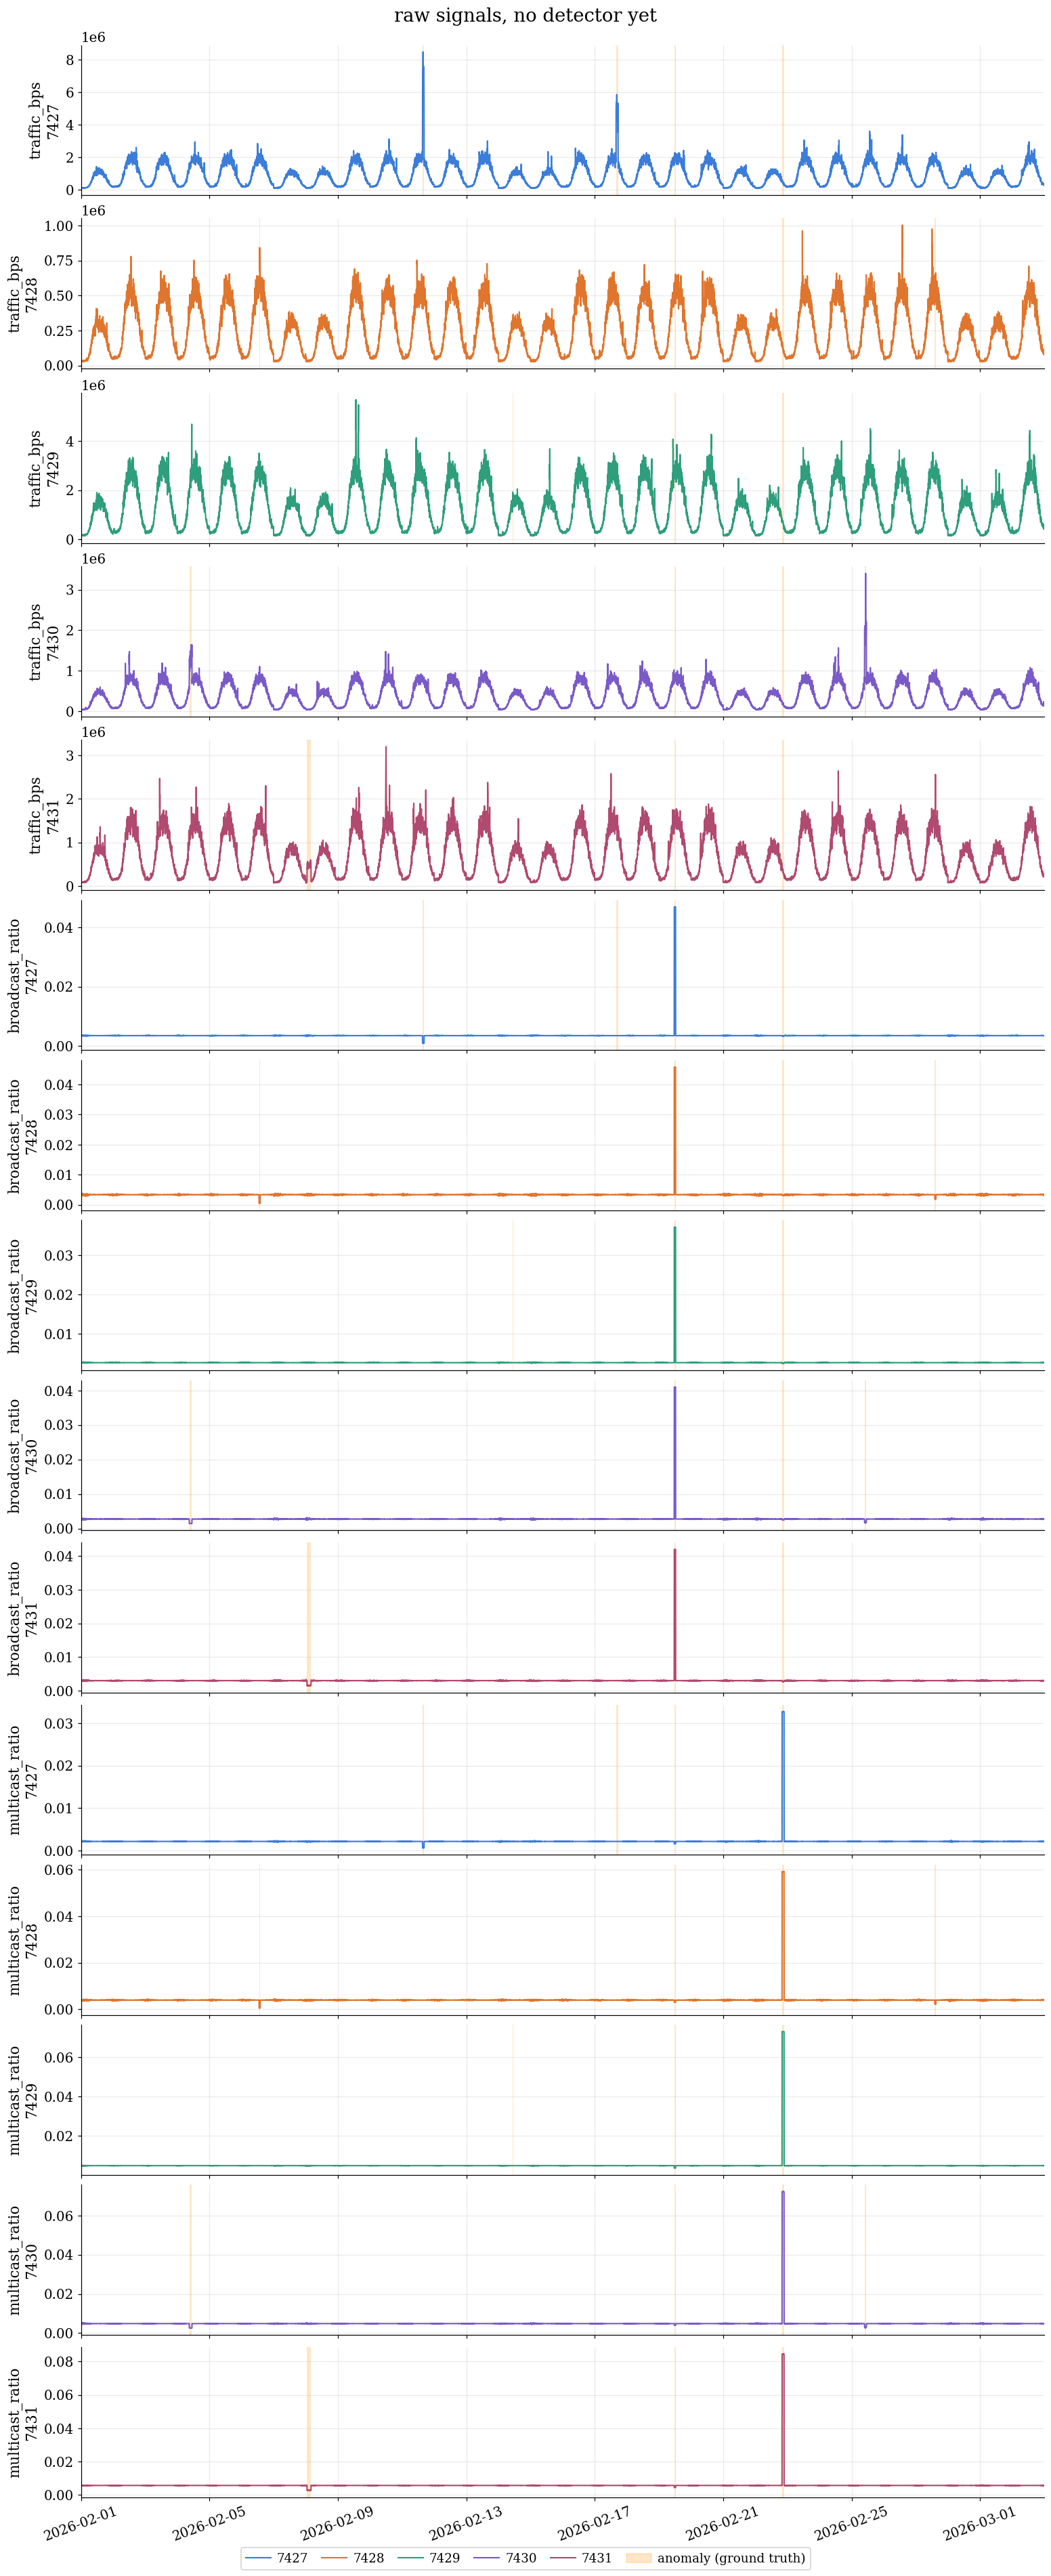

In [6]:
# What these arguments actually are, so your own code knows what shape to produce.
print(f"half={HALF!r}")
print(f"data={type(df).__name__} shape={df.shape}")
print(f"columns={COLUMNS}")
print(f"ports={PORTS}")
print(f"events={ANOMALY_TYPES}")

plot_signals(half=HALF, data=df, columns=COLUMNS, ports=PORTS, events=ANOMALY_TYPES,
             alerts=None, baselines=None, bands=None, outcomes=False, by_port=True,
             pad="6h", zoom_anomaly=False, zoom_signal=False,
             title="raw signals, no detector yet")

example_alerts:
{'traffic_bps': 0        False
1        False
2        False
3        False
4        False
         ...  
43195    False
43196    False
43197    False
43198    False
43199    False
Name: traffic_bps, Length: 43200, dtype: bool}
example_baselines:
{'traffic_bps': 0        910521.206312
1        910521.206312
2        910521.206312
3        910521.206312
4        910521.206312
             ...      
43195    697283.119002
43196    697283.119002
43197    697283.119002
43198    697283.119002
43199    697283.119002
Name: traffic_bps, Length: 43200, dtype: float64}
example_bands:
{'traffic_bps': (0       -1.212769e+06
1       -1.212769e+06
2       -1.212769e+06
3       -1.212769e+06
4       -1.212769e+06
             ...     
43195   -7.950552e+05
43196   -7.950552e+05
43197   -7.950552e+05
43198   -7.950552e+05
43199   -7.950552e+05
Name: traffic_bps, Length: 43200, dtype: float64, 0        3.033811e+06
1        3.033811e+06
2        3.033811e+06
3        3.033811e+06
4     

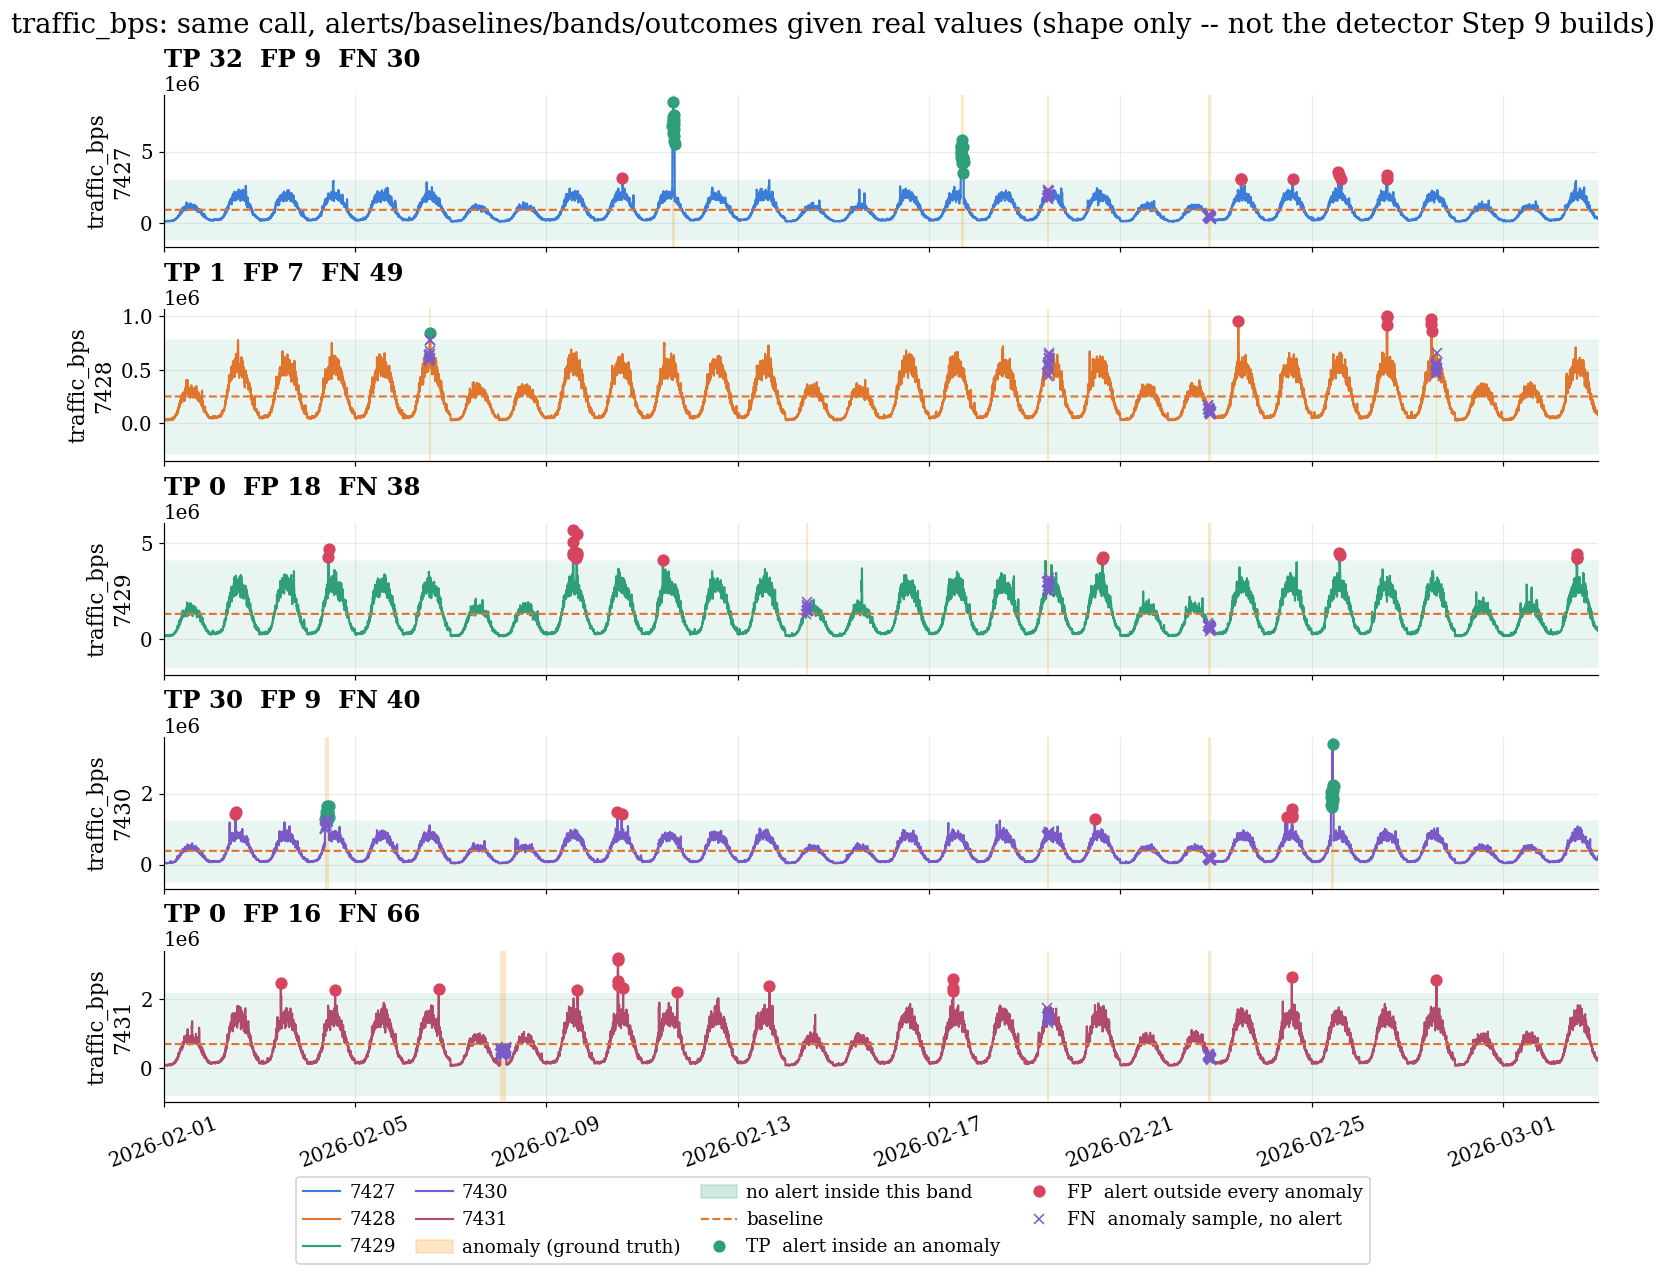

In [7]:
# alerts=, baselines= and bands= given real values below, so their shape is visible
# before Step 6 starts building them for real. This baseline looks at the whole series,
# past and future alike, so it is not the causal detector Step 9 builds -- only a stand-in
# with the right shape: baselines/bands are Series aligned to `data`, alerts is a boolean
# Series, one dict entry per column.
example_col = COLUMNS[0]
example_baseline = df.groupby("port_id")[example_col].transform("mean")
example_scale = df.groupby("port_id")[example_col].transform("std")
example_baselines = {example_col: example_baseline}
example_bands = {example_col: (example_baseline - 3 * example_scale,
                                example_baseline + 3 * example_scale)}
example_alerts = {example_col: (df[example_col] - example_baseline).abs() > 3 * example_scale}

print("example_alerts:")
print(example_alerts)

print("example_baselines:")
print(example_baselines)

print("example_bands:")
print(example_bands)

plot_signals(half=HALF, data=df, columns=[example_col], ports=PORTS, events=ANOMALY_TYPES,
             alerts=example_alerts, baselines=example_baselines, bands=example_bands,
             outcomes=True, by_port=True, pad="6h", zoom_anomaly=False, zoom_signal=False,
             title=f"{example_col}: same call, alerts/baselines/bands/outcomes given real "
                   f"values (shape only -- not the detector Step 9 builds)")

- **Storm and flooding show on the ratio columns, invisible on `traffic_bps`** — they change
  packet mix, not volume.
- **Both hit every port the same minute** — an L2 signature.
- **The signal you score decides what you can detect, before any statistics.**

### 5d — The scorecard

- **`plot_ranked`** — cutoff against sorted scores: a gap, or a dense band?
- **`report`** — the four numbers operations actually reads.
- **`heatmap`** — any sweep result, shape visible before the numbers are.
- **`confirm`** — the persistence rule Step 11 argues for; every step from Step 6 on uses it.

## Step 6 — Baseline 1: a fixed threshold

Written as `score = value / limit`, not `value > limit`, so 1.0 always means "at the limit" and
scores compare across columns with different units.

Two preconditions decide whether you are allowed to use one at all, and both are checkable in the
data:

1. **A physical reference point.** Zero errors is a true zero. Zero `traffic_bps` means the link is
   down, which is not the same thing.
2. **An order-of-magnitude gap** between quiet background and a real fault, so the limit sits in
   empty space and moving it a little changes nothing.

The cell below measures the gap on every column. Read it before choosing a line.

#### Demo subset for Steps 6–10

Every baseline below is shown twice: a demo case small enough to read sample by sample, then
the full fleet, which is what `report` actually scores. The demo case is one fixed slice for
the whole section, so a baseline's behaviour on it is comparable step to step —
**queue_congestion on port-id7427, read on `traffic_bps`**. Single-port, so no fleet-wide
storm blurs which port did what; `traffic_bps` is the column where the six baselines actually
separate (Step 10d).

Each cell below calls `plot_signals` twice: the demo pass first, then the full-fleet call
exactly as it would read on its own.

In [8]:
BASELINE_DEMO = {"port": "port-id7427", "event": "queue_congestion", "column": "traffic_bps"}
print(f"demo case: {BASELINE_DEMO['port']} / {BASELINE_DEMO['event']} / {BASELINE_DEMO['column']}")

demo case: port-id7427 / queue_congestion / traffic_bps


In [9]:
col = "errors_pps"
quiet = df.loc[df["event_label"] == "normal", col]
print(f"{col}: highest reading outside any anomaly {quiet.max():.4f}")
for eid, g in df[df["event_label"] != "normal"].groupby("event_id"):
    print(f"   {eid}  {g['event_label'].iloc[0]:26} peak {df.loc[g.index, col].max():.4f}")

errors_pps: highest reading outside any anomaly 0.0100
   A  business_traffic_growth    peak 0.0033
   B  small_packet_scan          peak 0.0000
   C  large_file_backup          peak 0.0000
   D  queue_congestion           peak 0.0000
   E  link_quality_issue         peak 1.9167
   F  load_sensitive_link_issue  peak 1.7967
   G  broadcast_storm            peak 0.0033
   H  multicast_flooding         peak 0.0000
   I  abnormal_device_sender     peak 0.0000
   J  unknown_protocol_scan      peak 0.0000


The gap is two decades wide: 0.0100 is the worst ordinary reading, and events E and F peak at 1.7967
and 1.9167. A limit anywhere between them works, so `0.05` is a defensible choice rather than a
tuned one.

- **The other side:** eight of the ten anomaly types leave `errors_pps` at exactly zero.
  - A fixed rule on the right column is the best method in this lab and a hopeless general policy
    — the same statement, twice.


FIXED_COLS:

['traffic_bps', 'broadcast_ratio', 'multicast_ratio', 'errors_pps', 'discards_pps', 'unknown_proto_pps', 'error_rate', 'discard_rate', 'err_disc_rate']

alerts_fixed:

{'traffic_bps': 0        False
1        False
2        False
3        False
4        False
         ...  
43195    False
43196    False
43197    False
43198    False
43199    False
Name: traffic_bps, Length: 43200, dtype: bool, 'broadcast_ratio': 0        False
1        False
2        False
3        False
4        False
         ...  
43195    False
43196    False
43197    False
43198    False
43199    False
Name: broadcast_ratio, Length: 43200, dtype: bool, 'multicast_ratio': 0        False
1        False
2        False
3        False
4        False
         ...  
43195    False
43196    False
43197    False
43198    False
43199    False
Name: multicast_ratio, Length: 43200, dtype: bool, 'errors_pps': 0        False
1        False
2        False
3        False
4        False
         ...  
43195    False
43

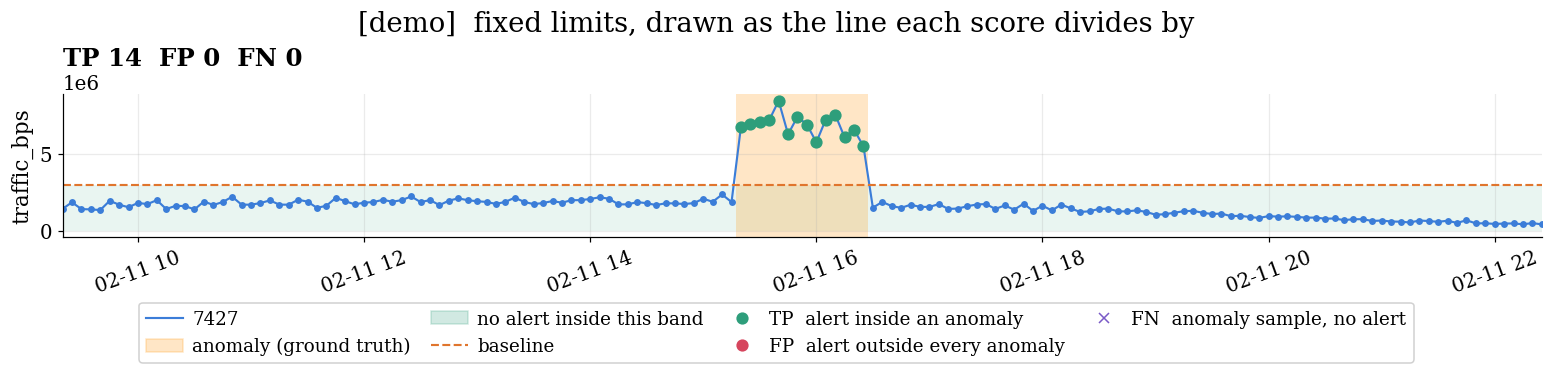

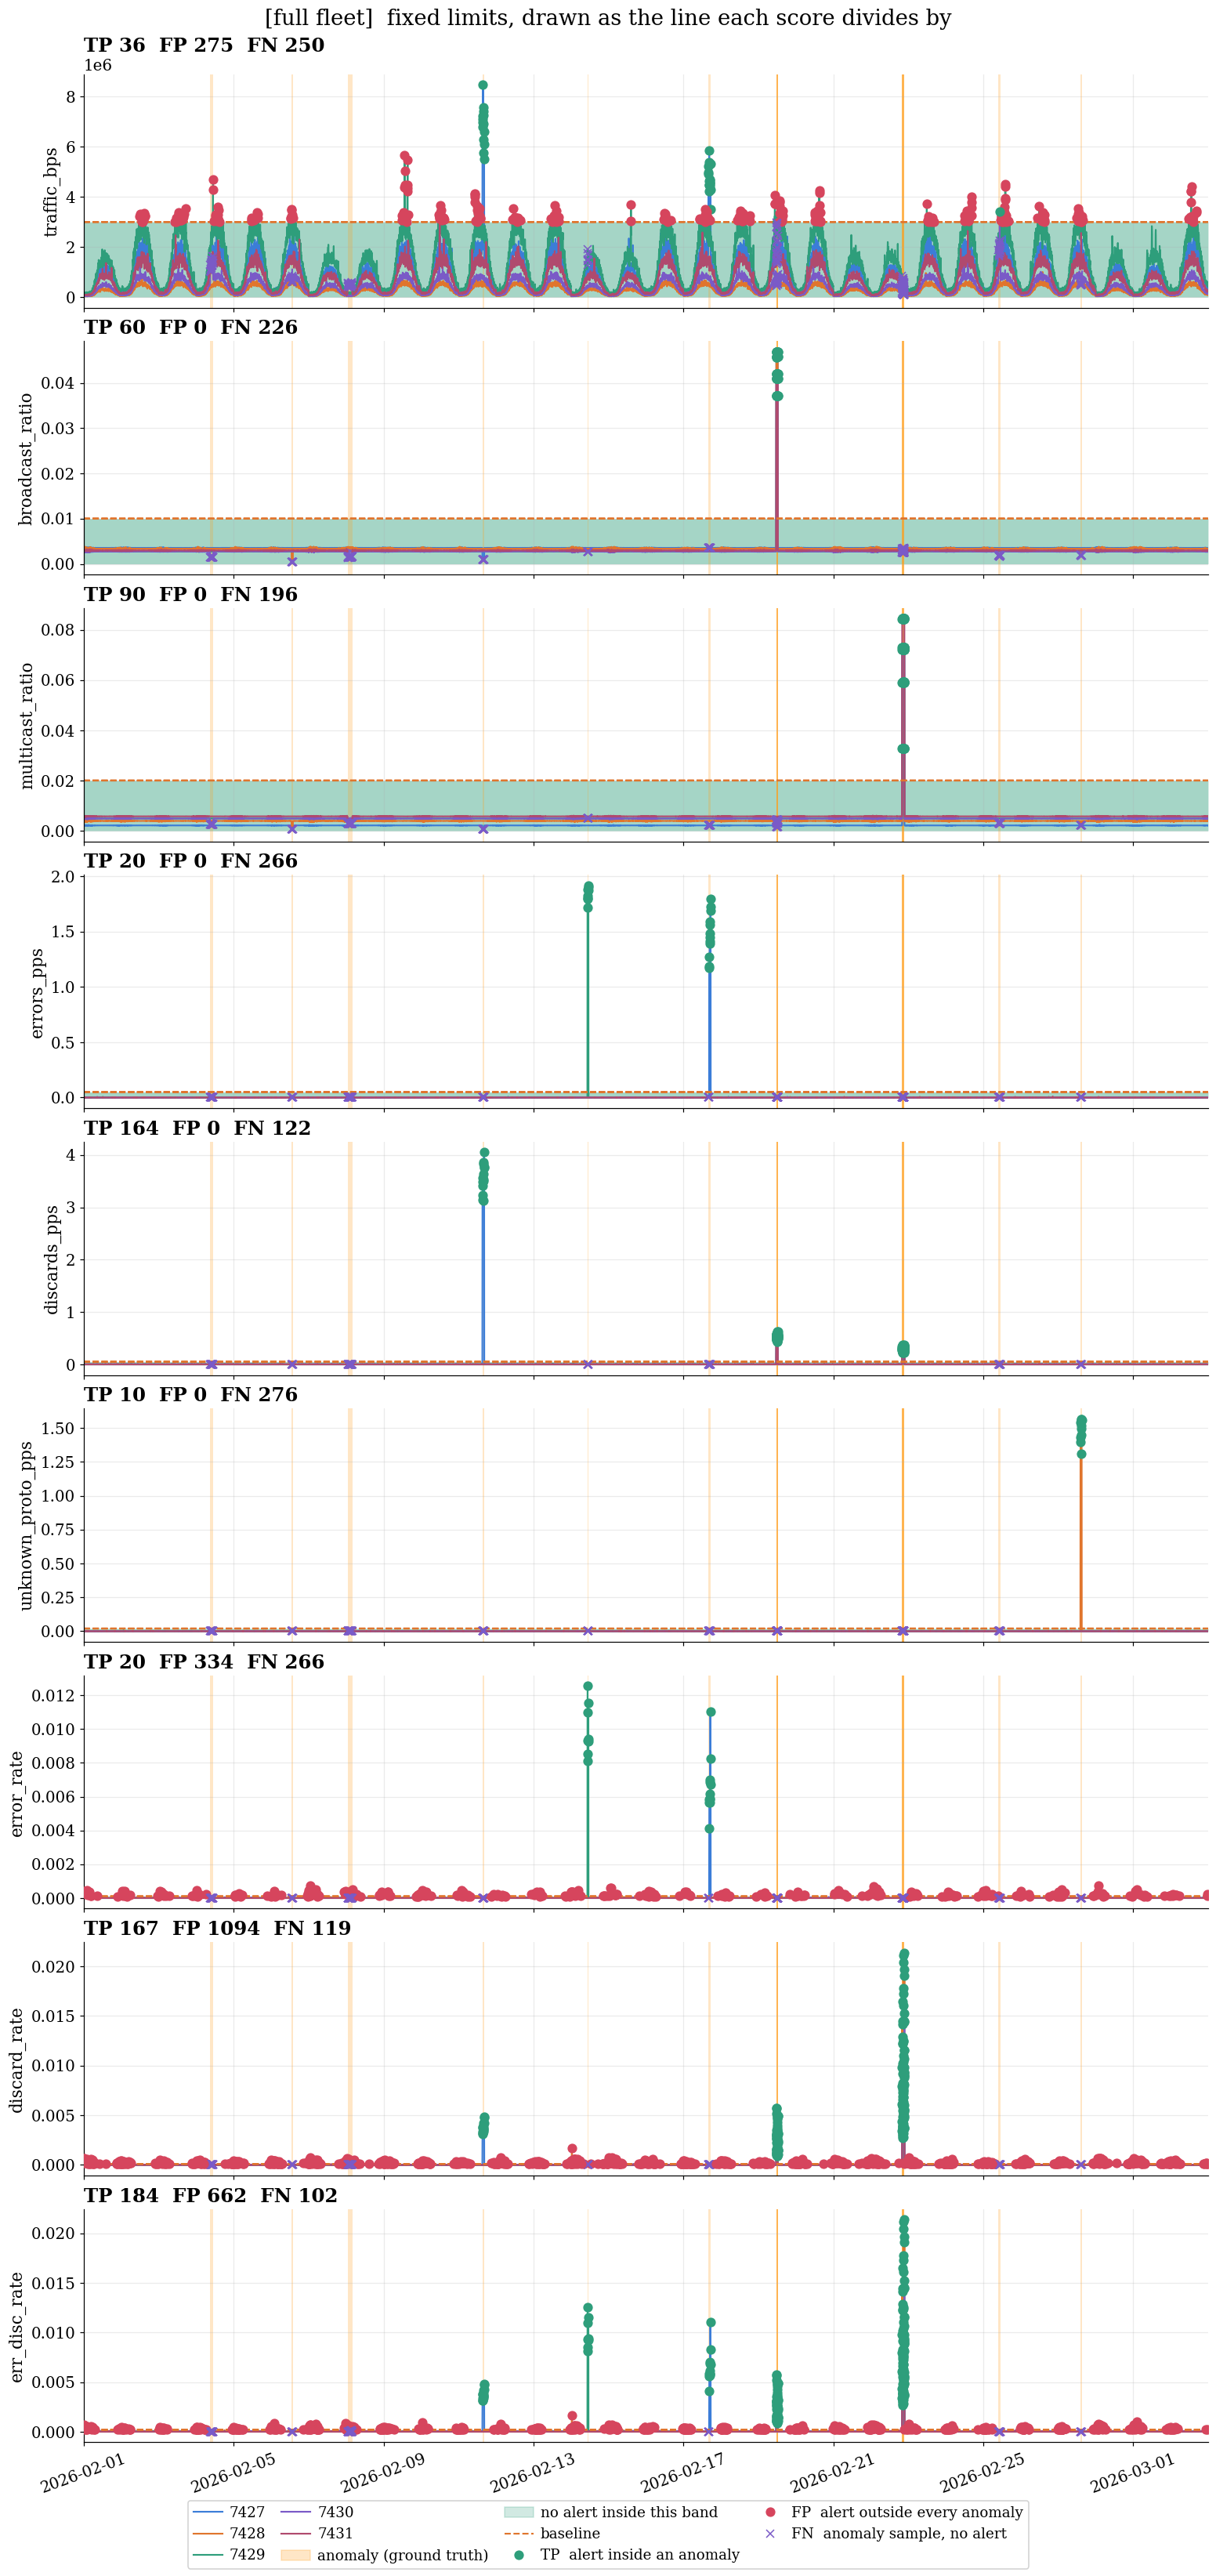

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,fixed traffic_bps > 3e+06,311,0.116,4/18,10.0,9.17
1,fixed broadcast_ratio > 0.01,60,1.000,5/18,0.0,0.00
2,fixed multicast_ratio > 0.02,90,1.000,5/18,0.0,0.00
3,fixed errors_pps > 0.05,20,1.000,2/18,15.0,0.00
4,fixed discards_pps > 0.05,164,1.000,11/18,0.0,0.00
5,fixed unknown_proto_pps > 0.02,10,1.000,1/18,0.0,0.00
6,fixed error_rate > 0.0001,354,0.056,2/18,15.0,11.13
7,fixed discard_rate > 0.0001,1261,0.132,12/18,0.0,36.47
8,fixed err_disc_rate > 0.0002,846,0.217,13/18,0.0,22.07


In [10]:
# One limit per feature. Edit these on site: every one is somebody's judgement, not a fitted value.
LIMITS = {"traffic_bps": 3.0e6, "packets_pps": 4.0e3, "errors_pps": 0.05,
          "discards_pps": 0.05, "unknown_proto_pps": 0.02, "avg_pkt_bytes": 1400.0,
          "broadcast_ratio": 0.01, "multicast_ratio": 0.02, "nonucast_ratio": 0.05,
          "tx_ratio": 0.9, "error_rate": 1e-4, "discard_rate": 1e-4, "err_disc_rate": 2e-4}


def fixed_score(data=df, col=None, limit=None):
    """value / limit, so 1.0 is the limit on every column whatever its unit."""
    col = COLUMNS[0] if col is None else col
    limit = LIMITS[col] if limit is None else limit
    return data[col] / limit


# Every configured column plus every sparse one, because the sparse columns are the
# case a fixed rule is right for and this is the step that shows it.
FIXED_COLS = COLUMNS + [c for c in SPARSE if c not in COLUMNS]
alerts_fixed = {c: fixed_score(data=df, col=c, limit=LIMITS[c]) > 1.0 for c in FIXED_COLS}

print("FIXED_COLS:")
print()
print(FIXED_COLS)
print()
print("alerts_fixed:")
print()
print(alerts_fixed)
print()
# Demo pass first: the shared case, close enough to read sample by sample.
plot_signals(half=HALF, data=df, columns=[BASELINE_DEMO["column"]],
             ports=[BASELINE_DEMO["port"]], events=[BASELINE_DEMO["event"]],
             alerts=alerts_fixed, outcomes=True, by_port=False,
             zoom_anomaly=True, zoom_signal=False, pad="6h",
             baselines={c: pd.Series(LIMITS[c], index=df.index) for c in FIXED_COLS},
             bands={c: (0.0, LIMITS[c]) for c in FIXED_COLS},
             title="[demo]  fixed limits, drawn as the line each score divides by")
# Then the full fleet, which is what `report` actually scores.
plot_signals(half=HALF, data=df, columns=FIXED_COLS, ports=PORTS, events=ANOMALY_TYPES,
             alerts=alerts_fixed, outcomes=True, by_port=False,
             zoom_anomaly=False, zoom_signal=False,
             baselines={c: pd.Series(LIMITS[c], index=df.index) for c in FIXED_COLS},
             bands={c: (0.0, LIMITS[c]) for c in FIXED_COLS},
             title="[full fleet]  fixed limits, drawn as the line each score divides by")
report(alerts={f"fixed {c} > {LIMITS[c]:g}": a for c, a in alerts_fixed.items()},
       data=df, ports=PORTS, events="all")

#### Your call — `LIMITS`

**The decision:** the number you'd defend in a review — not "looks high" but "above this,
something is wrong, and here is why". The only detector here that encodes human judgement
directly.

**Two preconditions, or don't use one:**

- **A physically grounded reference** — zero errors is really zero; zero traffic is a Sunday.
- **An order-of-magnitude gap** between quiet background and real fault.
- **`errors_pps` has both** — the only detector in this lab that finds event E.
- **`traffic_bps` has neither** — its fixed rule is the worst detector on that column.

**Sources for the number:**

- **Legitimate:** a vendor's rated capacity, a signed SLO, an error budget, a hardware queue
  depth.
- **Look authoritative, aren't:** a threshold inherited from a prior team, any round number
  nobody can source.

**Do it now.** Pick a metric you monitor with a fixed threshold. Can you source the number? Does
it pass both preconditions? Fail either and the rule fires on preference, not a limit — this lab
has five alternatives.

Three outcomes, and they are the three cases a fixed rule has.

- **`errors_pps` — both preconditions hold.** Physical zero, two-decade gap, exact rule. The only
  detector in this lab that finds event E.
- **The ratio columns — tolerable.** Narrow band, anomalies leave it, so a hand-picked line works
  even though nothing physical anchors it.
- **`traffic_bps` — fails.** The line is above the daily peak and never fires, or below it and fires
  every afternoon. No constant is both.

Every remaining baseline exists to answer that third case. None improves on the first.

## Step 7 — Baseline 2: the global z-score

$$z_i = (x_i - \bar{x}) / \sigma$$

- **Baseline is the month's own mean** — the score is how many standard deviations out a sample
  sits.
- **Computed per port** — else a busy uplink defines normal for a quiet VLAN.

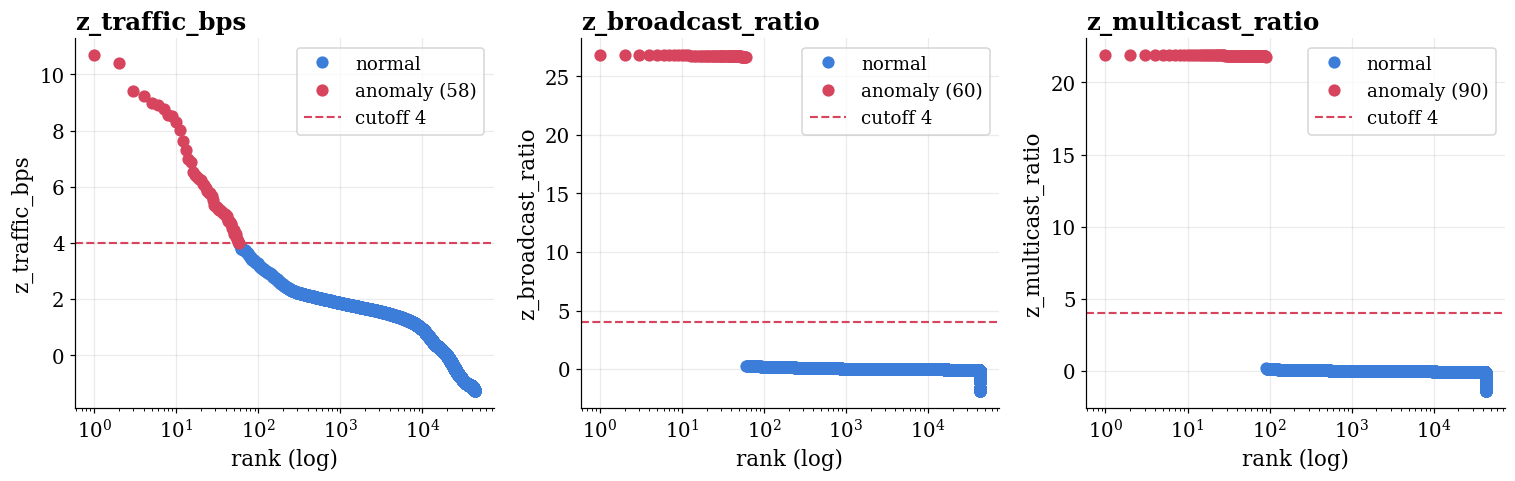

In [11]:
def modified_zscore(x, k=1.4826):
    """(x - median) / (k * MAD), NaN everywhere if the MAD is zero.

    k rescales the MAD to read on the same axis as a standard deviation on normal data. A zero
    MAD means over half the samples are identical, and no rescaling saves a scale of zero, so
    the function refuses rather than dividing.
    """
    x = np.asarray(x, dtype=float)
    d = x - np.median(x)
    mad = np.median(np.abs(d))
    return d / (k * mad) if mad > 0 else np.full_like(x, np.nan)


def add_scores(data, columns=None, ports=None, kind="z"):
    """Write one whole-history score column per signal, computed within each port."""
    columns = COLUMNS if columns is None else columns
    ports = PORTS if ports is None else ports
    for col in columns:
        out = f"{kind}_{col}"
        data[out] = np.nan
        for pid in (data["port_id"].unique() if ports == "all" else ports):
            m = data["port_id"] == pid
            v = data.loc[m, col].to_numpy(dtype=float)
            data.loc[m, out] = ss.zscore(v, ddof=0) if kind == "z" else modified_zscore(v)


add_scores(data=df, columns=COLUMNS, ports=PORTS, kind="z")

w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(1, len(COLUMNS), figsize=(w, h), squeeze=False)
for ax, col in zip(axes[0], COLUMNS):
    plot_ranked(score=df.loc[df["port_id"].isin(PORTS), f"z_{col}"],
                threshold=THRESHOLD, name=f"z_{col}", ax=ax)
plt.show()

The ratio columns put a handful of points far above a flat body, so a cutoff at 4 lands in empty
space and moving it changes nothing. `traffic_bps` descends smoothly through the cutoff, so every
point near the line is a coin toss.

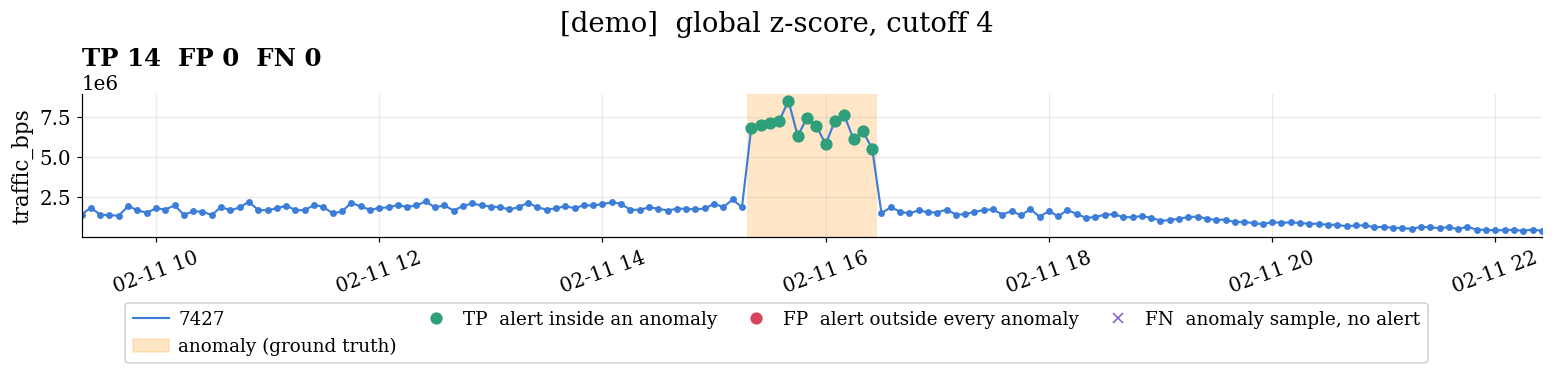

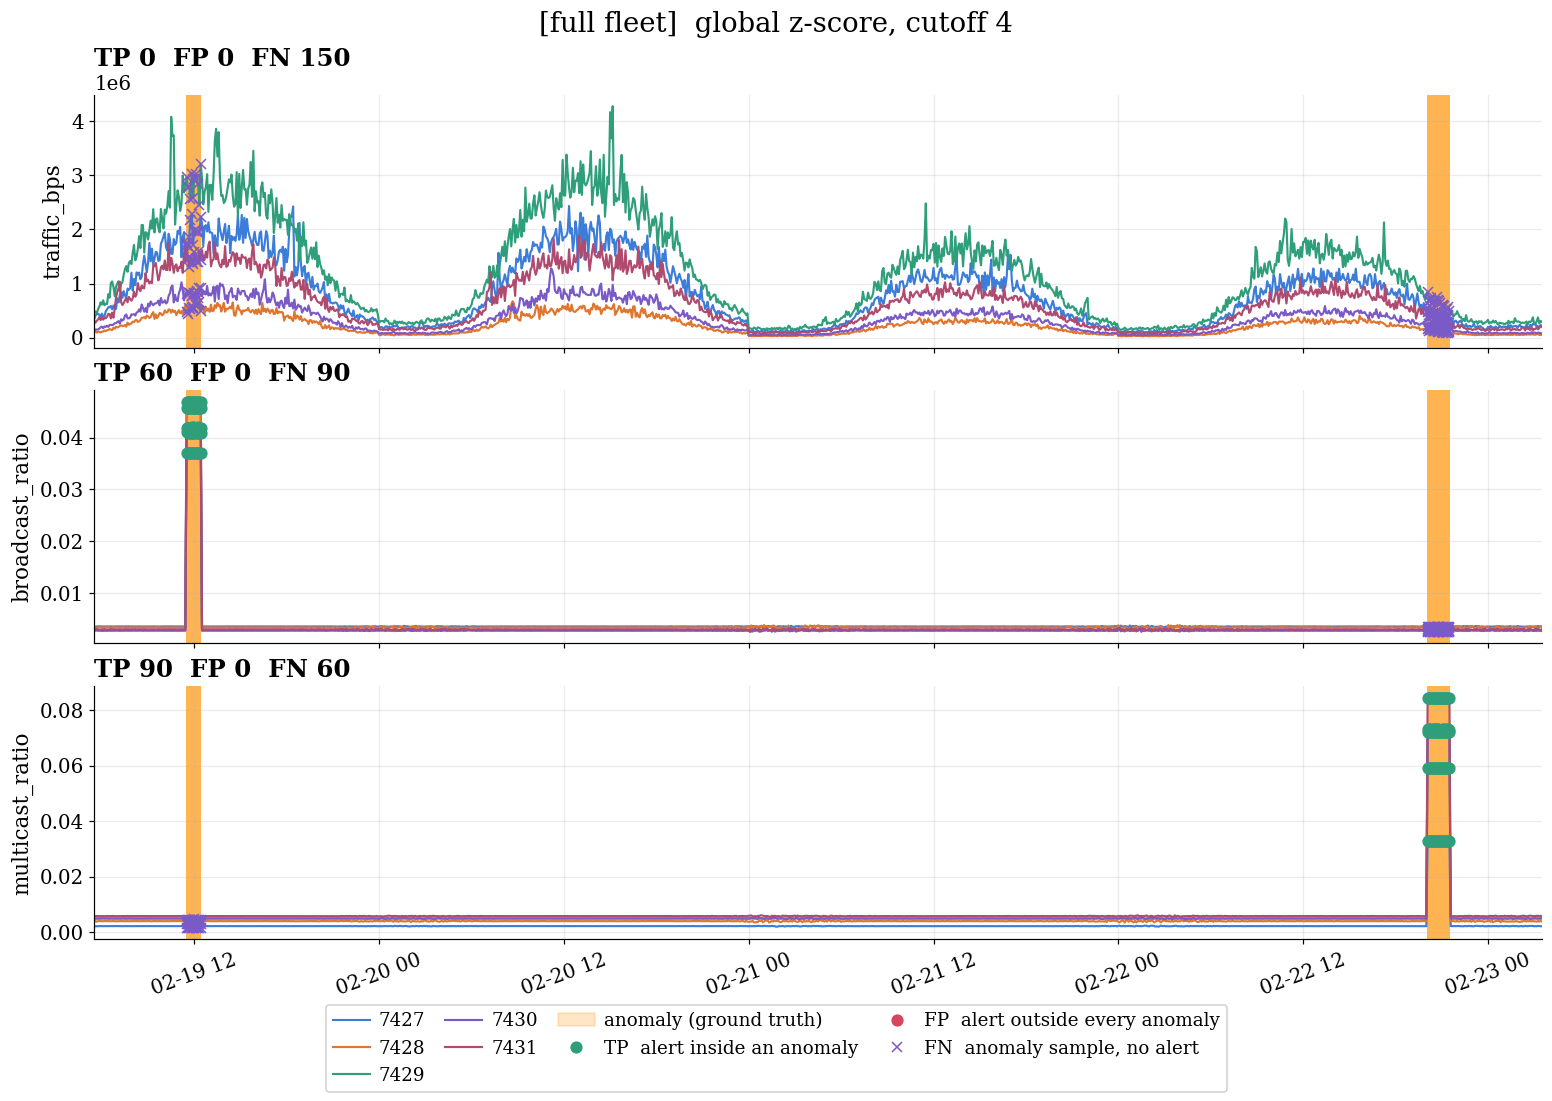

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,global z traffic_bps,58,0.845,4/18,0.0,0.3
1,global z broadcast_ratio,60,1.000,5/18,0.0,0.0
2,global z multicast_ratio,90,1.000,5/18,0.0,0.0


In [12]:
alerts_z = {c: df[f"z_{c}"] > THRESHOLD for c in COLUMNS}
plot_signals(half=HALF, data=df, columns=[BASELINE_DEMO["column"]],
             ports=[BASELINE_DEMO["port"]], events=[BASELINE_DEMO["event"]],
             alerts=alerts_z, outcomes=True, by_port=False,
             zoom_anomaly=True, zoom_signal=False, pad="6h",
             title=f"[demo]  global z-score, cutoff {THRESHOLD:g}")
plot_signals(half=HALF, data=df, columns=COLUMNS, ports=PORTS, events=ZOOM_EVENTS,
             alerts=alerts_z, outcomes=True, by_port=False,
             zoom_anomaly=True, zoom_signal=False, pad="6h",
             title=f"[full fleet]  global z-score, cutoff {THRESHOLD:g}")
report(alerts={f"global z {c}": a for c, a in alerts_z.items()},
       data=df, ports=PORTS, events="all")

#### Your call — `THRESHOLD`

**The decision:** four sigma sounds like a probability. It isn't one, on this data.

- **The normal table says a four-sigma breach is one in 30,000; the measured rate is far above
  that.** Traffic is heavy-tailed, the scale floor inflates quiet-stretch scores, breaches
  cluster rather than arrive independently.
- **A tail-probability cutoff rests on an assumption that fails.**
- **State `alerts_per_day` instead.** It absorbs tail shape, autocorrelation and multiple testing
  at once — and it's a number the pager-holder can accept or refuse.
  - Pick the volume first, then read the threshold off the sweep that produces it.

**Do it now.** Set `THRESHOLD = 2.0`, then `8.0`, and watch `alerts_per_day`, not precision. How
many pages a day would your team accept, and does any cutoff on this column deliver that?

At a cutoff of 4 this looks like a success on `traffic_bps`: precise, and well under one stray
alert per day. The question is what it took to get there.

In [13]:
report(alerts={f"global z traffic_bps > {t}": df["z_traffic_bps"] > t
               for t in (2, 2.5, 3, 4, 5)},
       data=df, ports=PORTS, events="all")

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,global z traffic_bps > 2,616,0.138,9/18,0.0,17.70
1,global z traffic_bps > 2.5,202,0.351,5/18,0.0,4.37
2,global z traffic_bps > 3,122,0.516,5/18,0.0,1.97
3,global z traffic_bps > 4,58,0.845,4/18,0.0,0.30
4,global z traffic_bps > 5,39,0.974,3/18,0.0,0.03


The failure is a narrow operating range rather than an outright miss.

- **Cutoff 4 or above to stay precise.** At 3 precision halves. At 2 it falls to 0.14 with almost 7
  stray alerts a day, buying one extra anomaly window.
- **The denominator is why.** One standard deviation over thirty days is inflated by the daily and
  weekly cycle, so a deviation smaller than a daily peak can never reach a usable cutoff.
- **The score is not wrong** — it cannot resolve anything below the scale of the cycle. Step 8 tests
  the assumptions, Step 9 replaces the baseline.

## Step 8 — What the z-score assumed

- **Normality** — what lets a cutoff of 3 mean "0.13% of samples".
- **Unimodality** — what lets one mean and one standard deviation describe the data at all.
- **Both checkable, both false here.**

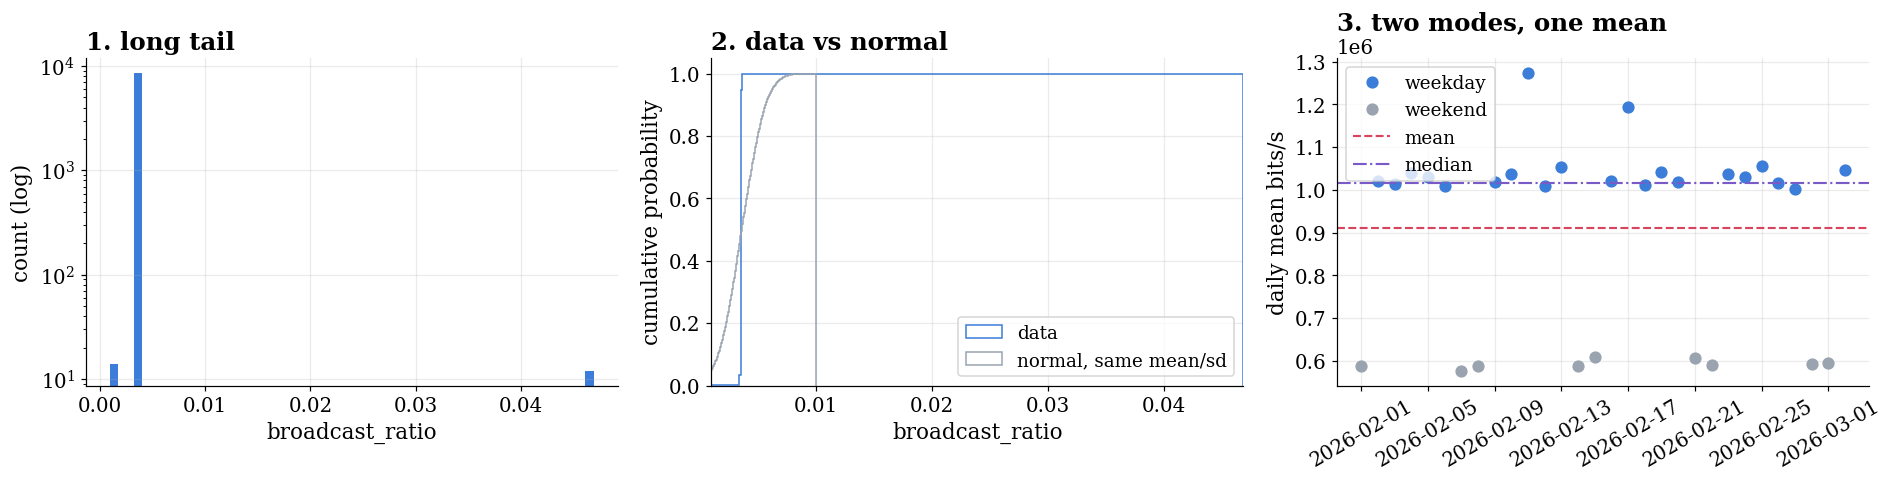

Shapiro-Wilk on broadcast_ratio (n=1000): W=0.0279, p=3.43e-57
daily traffic: sd 2.148e+05 is 6.1x the robust scale; mean 9.105e+05 vs median 1.017e+06


In [14]:
col, port = COLUMNS[1], PORTS[0]
v = df.loc[df["port_id"] == port, col]

daily = (df[df["port_id"] == port]
         .assign(date=lambda d: d["timestamp"].dt.floor("D"))
         .groupby("date", as_index=False)[COLUMNS[0]].mean())
daily["weekend"] = daily["date"].dt.dayofweek >= 5

w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(1, 3, figsize=(w * 1.25, h))
axes[0].hist(v, bins=60, color=C["signal"])
axes[0].set(yscale="log", xlabel=col, ylabel="count (log)", title="1. long tail")

axes[1].hist(v, bins=400, density=True, histtype="step", cumulative=True,
             color=C["signal"], label="data")
axes[1].hist(np.random.default_rng(0).normal(v.mean(), v.std(ddof=0), 20_000),
             bins=400, density=True, histtype="step", cumulative=True,
             color=C["muted"], label="normal, same mean/sd")
axes[1].set(xlim=(v.min(), v.quantile(0.9995)), xlabel=col,
            ylabel="cumulative probability", title="2. data vs normal")
axes[1].legend(loc="lower right")

for lab, sel, c in [("weekday", ~daily["weekend"], C["signal"]),
                    ("weekend", daily["weekend"], C["muted"])]:
    axes[2].plot(daily.loc[sel, "date"], daily.loc[sel, COLUMNS[0]], "o", color=c, label=lab)
axes[2].axhline(daily[COLUMNS[0]].mean(), color=C["alert"], ls="--", label="mean")
axes[2].axhline(daily[COLUMNS[0]].median(), color=C["score"], ls="-.", label="median")
axes[2].set(ylabel="daily mean bits/s", title="3. two modes, one mean")
axes[2].tick_params(axis="x", labelrotation=30)
axes[2].legend()
plt.show()

stat, p = ss.shapiro(v.sample(1000, random_state=0))
sd = daily[COLUMNS[0]].std(ddof=0)
mad = 1.4826 * np.median(np.abs(daily["traffic_bps"] - daily[COLUMNS[0]].median()))
print(f"Shapiro-Wilk on {col} (n=1000): W={stat:.4f}, p={p:.2e}")
print(f"daily traffic: sd {sd:.3e} is {sd / mad:.1f}x the robust scale; "
      f"mean {daily['traffic_bps'].mean():.3e} vs median {daily['traffic_bps'].median():.3e}")

- **Panel 3 matters operationally:** 9 weekend days near 5.9e5 bits/s, 21 weekdays near 1.02e6.
  - One mean fits neither — the gap inflates the standard deviation to 6× the robust scale.
  - Every global z-score's denominator here is built from a pattern that isn't an anomaly at all.
- **Fix: not a better statistic — a closer baseline.**

## Step 9 — Baseline 3: a rolling window, and the window is a hyperparameter

$$z_t = \frac{x_t - \mathrm{mean}(x_{t-w \ldots t-1})}{\mathrm{sd}(x_{t-w \ldots t-1})}$$

`w` is now the most consequential number in the detector, and it fails at both ends:

- **too short** — a sustained event enters its own baseline window and drags it up. The detector
  compares the anomaly against itself.
- **too long** — slow to a legitimate level change, and on a cyclic signal it averages night
  together with day again.

**Robust**, since the word recurs throughout:

- Bounded by the clean part of the input, however extreme the contamination.
- **Breakdown point** — contamination share needed to drag the estimate: 0% mean, 50% median.
- **Bounded ≠ immune** — a median still moves under one-sided contamination, just can't leave the
  clean data's range.

`kind="mean"` = mean+sd, `kind="robust"` = median+MAD, nothing else differs. Two failures, one at
a time.

In [15]:
def rolling_baseline(data, col, window=None, kind="mean", ports=None, lag=1):
    """Per-port rolling centre and scale, and the score they produce.

    `lag` shifts the window back so the baseline is built strictly from earlier samples. lag=0
    lets the current sample into its own baseline, which is a small but real self-contamination;
    lag=1 is honest and is also what an online detector can compute.

    kind="mean" uses mean and standard deviation, kind="robust" uses median and MAD.
    Returns (centre, scale, score), each aligned to `data`.
    """
    window = WINDOW if window is None else window
    ports = data["port_id"].unique() if (ports or "all") == "all" else ports
    centre = pd.Series(np.nan, index=data.index)
    scale = pd.Series(np.nan, index=data.index)
    min_p = max(3, window // 3)

    for pid in ports:
        g = data.loc[data["port_id"] == pid].sort_values("timestamp")
        v = g[col].shift(lag)
        if kind == "mean":
            c = v.rolling(window, min_periods=min_p).mean()
            s = v.rolling(window, min_periods=min_p).std()
        else:
            c = v.rolling(window, min_periods=min_p).median()
            s = (v - c).abs().rolling(window, min_periods=min_p).median() * 1.4826
        centre.loc[g.index], scale.loc[g.index] = c, s

    # A quiet stretch drives the scale toward zero, and then every ordinary wobble divides into a
    # huge score. Floor it at a fraction of the column's own spread over the whole history.
    #
    # The floored scale is what gets returned, not the raw one. A caller drawing `centre ± k *
    # scale` is drawing the boundary the detector uses, and returning a scale the score did not
    # divide by would put the figure and its own detector at odds exactly where the floor binds.
    whole = data[col].to_numpy(dtype=float)
    floor = max(0.05 * 1.4826 * np.median(np.abs(whole - np.median(whole))), 1e-12)
    scale = scale.fillna(floor).clip(lower=floor)
    score = ((data[col] - centre) / scale).clip(-50, 50)
    return centre, scale, score

### 9a — Too short, and the event contaminates its own baseline

Event G is a broadcast storm lasting 12 samples, one hour. Draw the rolling mean baseline over
that hour for a 1-hour window and for a 12-hour window.

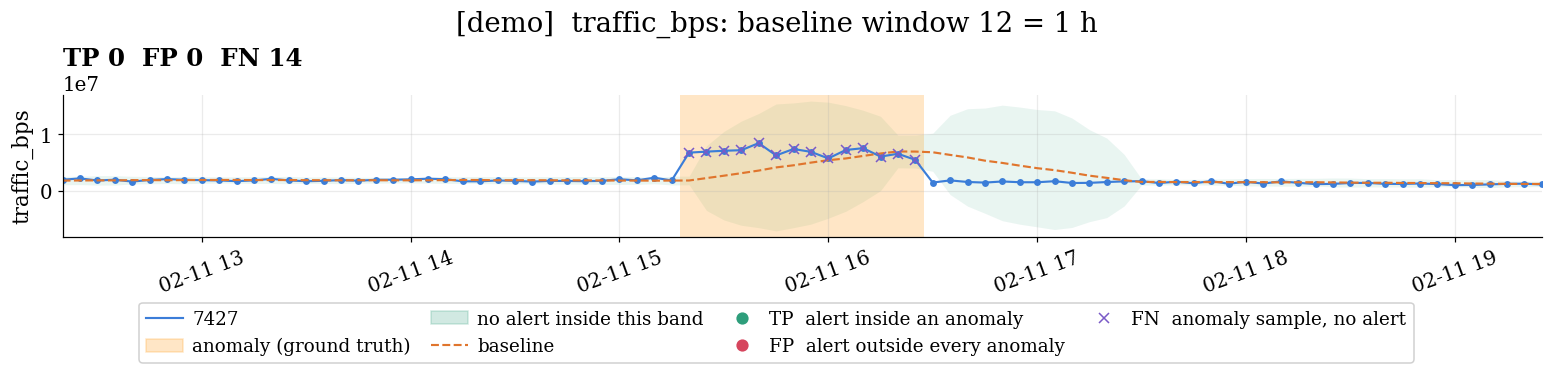

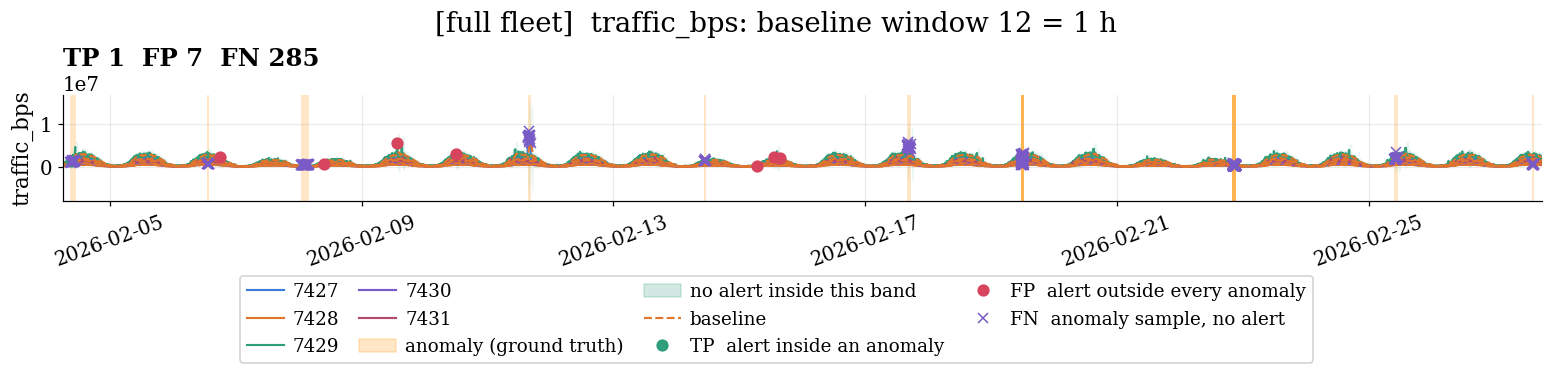

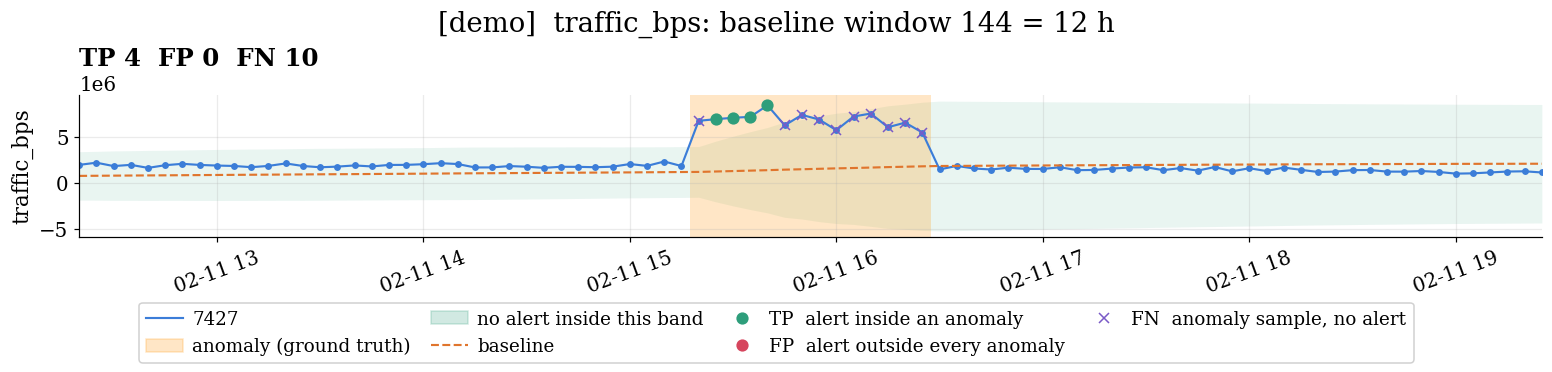

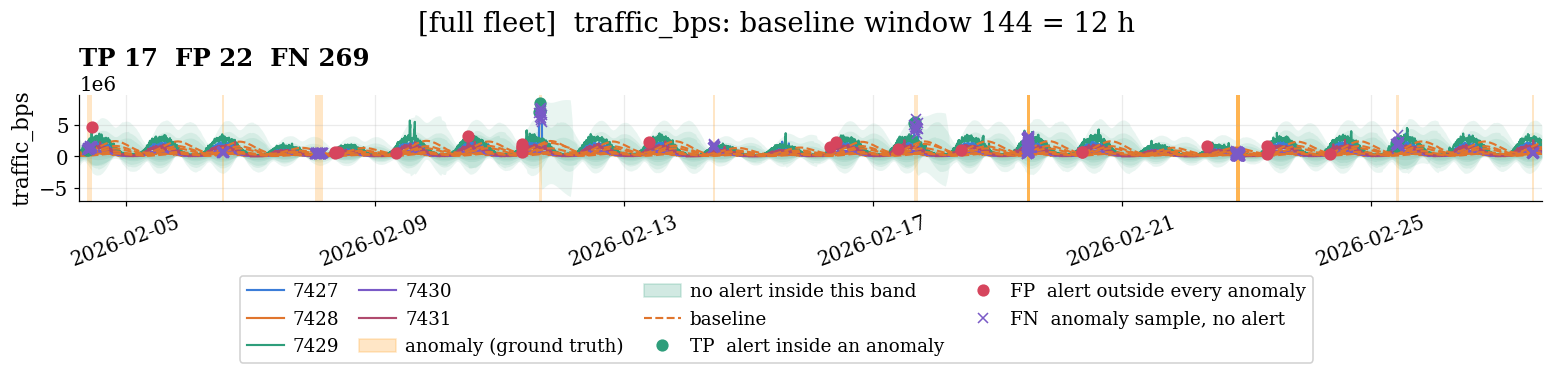

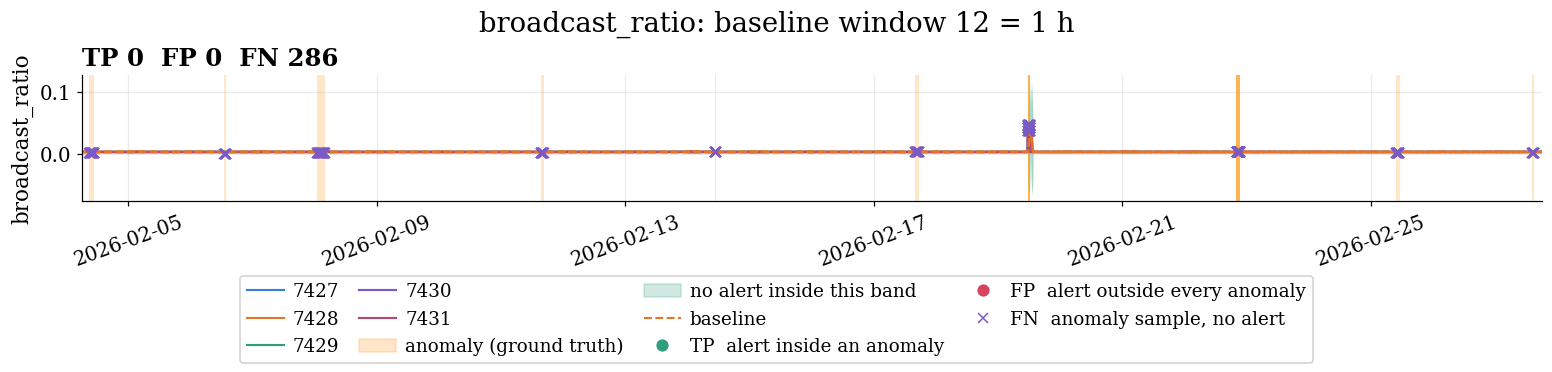

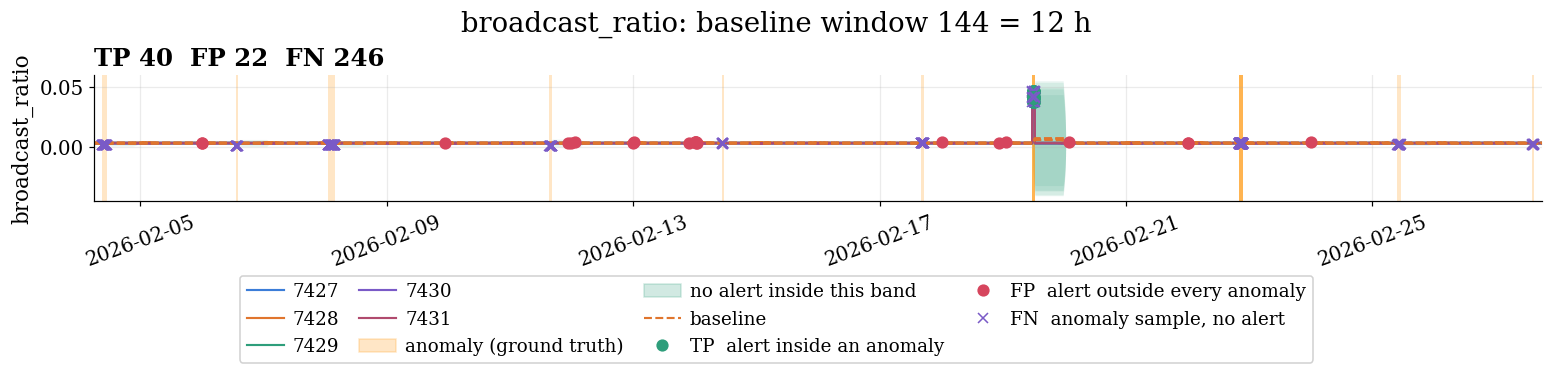

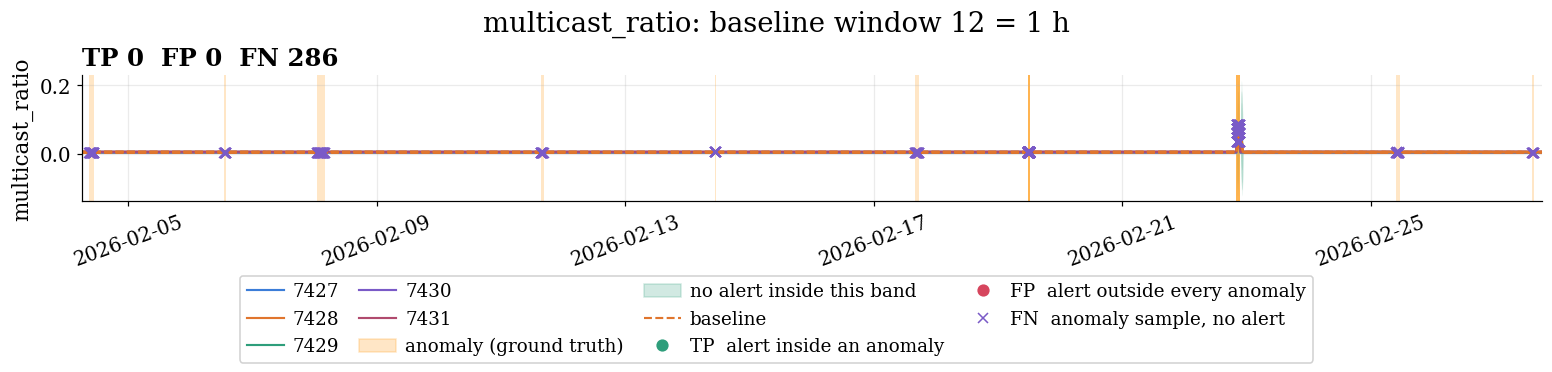

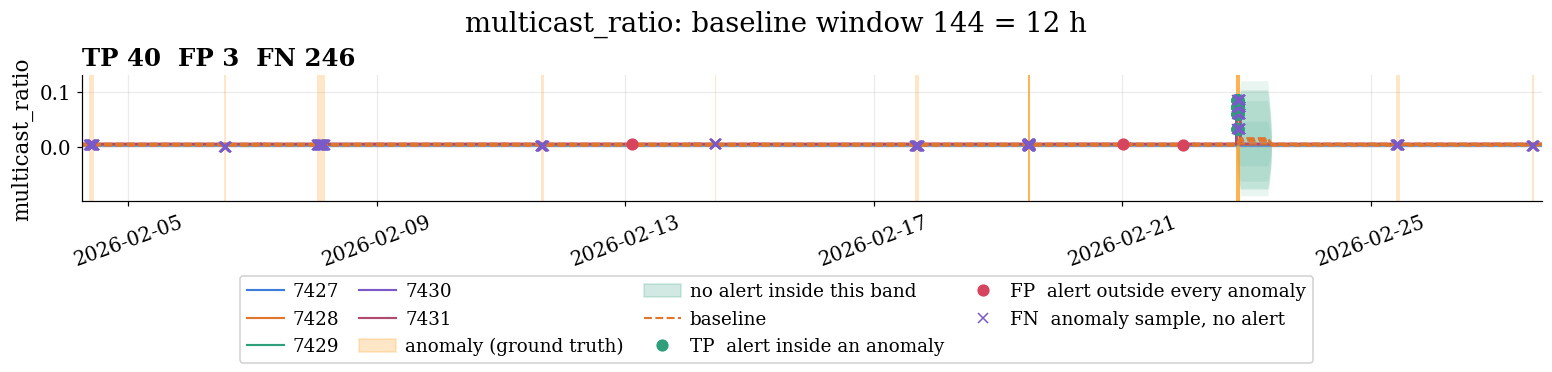

In [16]:
# `col` sweeps all of COLUMNS below; only the demo column also gets the close-up pass, so the
# other two columns draw exactly as before and the demo case doesn't triple the figure count.
def show(col, **kwargs):
    if col != BASELINE_DEMO["column"]:
        plot_signals(**kwargs)
        return
    title = kwargs.pop("title", "")
    # Demo pass first: the shared case, then the call below exactly as it would read alone.
    plot_signals(**{**kwargs, "ports": [BASELINE_DEMO["port"]],
                    "events": [BASELINE_DEMO["event"]]}, title=f"[demo]  {title}")
    plot_signals(**kwargs, title=f"[full fleet]  {title}")


for col in COLUMNS:
    for w in WINDOW_PAIR:
        centre, scale, score = rolling_baseline(
            data=df, col=col, window=w, kind="mean", ports=PORTS, lag=1)
        show(col, half=HALF, data=df, columns=[col], ports=PORTS,
                     events=ANOMALY_TYPES, pad="3h",
                     # x to the storm, y to the signal: at a 12-hour window the band goes full
                     # height for a whole window after the event, and unclipped it would flatten
                     # the line.
                     zoom_anomaly=True, zoom_signal=False,
                     baselines={col: centre},
                     # The band is the cutoff written in the units of the signal: score > THRESHOLD
                     # and a sample above the shading are the same test.
                     bands={col: (centre - THRESHOLD * scale, centre + THRESHOLD * scale)},
                     alerts={col: confirm(breach=score > THRESHOLD, data=df, n=N_CONSEC)},
                     outcomes=True, by_port=False,
                     title=f"{col}: baseline window {w} = {w * CADENCE / 3600:.0f} h")

**Read one thing first: the 1-hour figure carries no alert marker at all.** All 60 storm samples are
purple FN crosses, on all five ports.

- **The band is the cutoff in the units of the signal,** `centre ± 4 × scale`. A sample inside it
  cannot alert.
- **At 1 hour the band balloons around the storm** within a few samples.
  - By then most of the window *is* the storm.
  - It swallows a signal fourteen times the normal level.
  - The rising centre is the visible half; the rising scale is the larger one.
- **The hairline before the storm is the scale floor, not a zero.**
  - `rolling_baseline` floors the scale at 5% of the column's month-long spread — here 1.70e-05.
  - At a 1-hour window every quiet sample sits *at* that floor.
  - Without it, a near-constant stretch scores an ordinary wobble in the hundreds.

**At 12 hours the contamination is still there, just slower.** Port 7427, sample by sample: 50.0,
11.9, 8.4, 6.8, 5.9, 5.2, 4.8, 4.4, 4.1, then 3.9 and under the cutoff for the last three — while
the signal never moves.

- **Centre drifts 0.00354 → 0.00685. Scale goes 0.000036 → 0.011554, a factor of 321.**
- **It does not escape self-contamination; it survives long enough to fire.**
  - It loses the event 45 minutes in, while the event is still running.
- **The first sample is missed for an unrelated reason.** It breaches at a capped 50.0, and
  `N_CONSEC = 2` is being paid in advance.

**Both windows go blind for one full window afterwards,** where the band reaches full height.

- Hour after the storm at `w=12`: highest score **−0.288**.
- Twelve hours after it at `w=144`: never above **−0.062**. Against a cutoff of 4.
- **The long window moves the cost from the event to the recovery** and buys detection with it.

#### Your call — `WINDOW`

**The decision:** how much recent history still counts as normal here. That is a claim about your
network — how fast can this metric legitimately change with nothing wrong?

**You will meet the failures as behaviour, not as numbers:**

- **Too short** — quiet during exactly the long incidents you wanted it for. You find out from a
  ticket.
- **Too long** — fires every afternoon on a signal with a daily rhythm. Within a fortnight someone
  has muted the rule, which is the same outcome as never writing it and harder to notice.

**Two bounds you can compute from what you already have:**

- **Upper**, from your ticket history: the shortest incident you would still want caught. Stay well
  below a window near that length, because such a window is made of the incident.
- **Lower**, from the metric: where its autocorrelation decays (10b shows the calculation). Shorter
  than that and the spread is estimated from near-copies and understated.
- **If the bounds cross,** no single window works and you need two — that is 9d.

**Do it now.** Set `WINDOW = 12`, re-run 9a and the sweep, then set `WINDOW = 2016`. Before looking,
write down which end you expect to page you more often. Most people get this backwards.

### 9b — Smoothing gets immunity to abruption, but dilutes short anomalies

The same tradeoff appears in plain smoothing. A longer moving average is a cleaner line and a
smaller peak.

**First, what changed in the figure.** 9a drew a dashed orange line and called it a baseline.
This one draws a heavy line in each port's own colour and dims the raw underneath. Different
object, different encoding:

- **9a's line is a reference.** Built from earlier samples only (`lag=1`), and the score is the
  distance from it. It can be wrong, and 9a is the picture of it being wrong.
- **9b's line is the signal.** Same series, averaged over a window centred on each point, so it
  uses samples from *after* the point it describes. There is nothing to be wrong about, and
  nothing you can deploy: at time `t` those later samples do not exist yet.

So `plot_signals` takes them as two arguments, `baselines=` and `smoothed=`. Handing a smoothing
to `baselines=` draws a detector nobody can build, and the chart will not object.

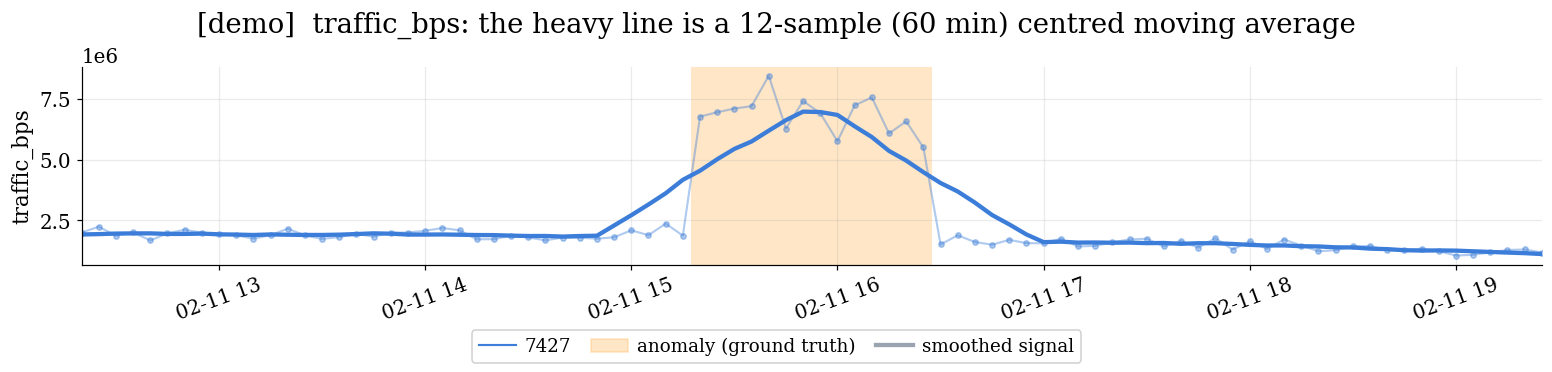

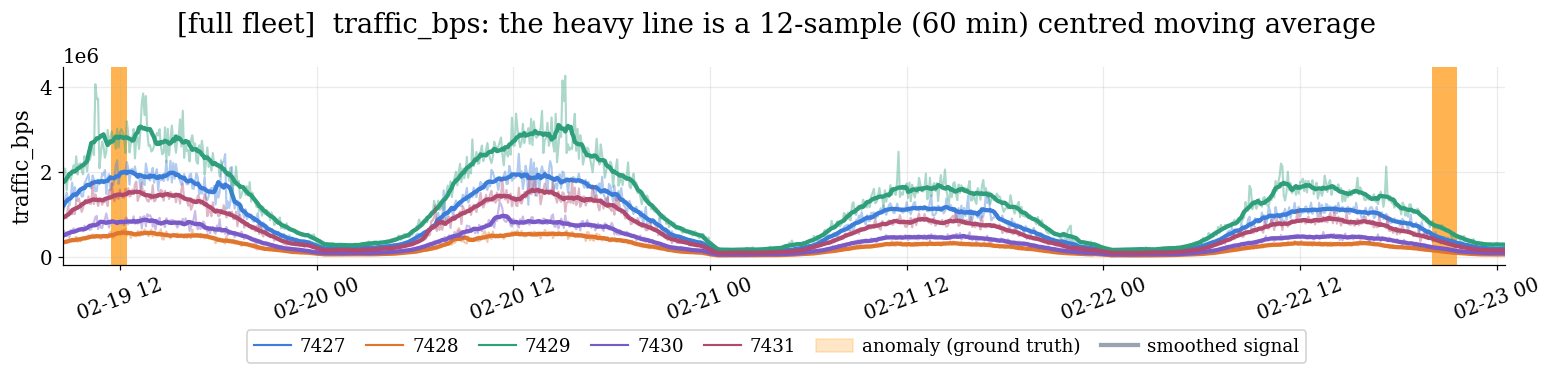

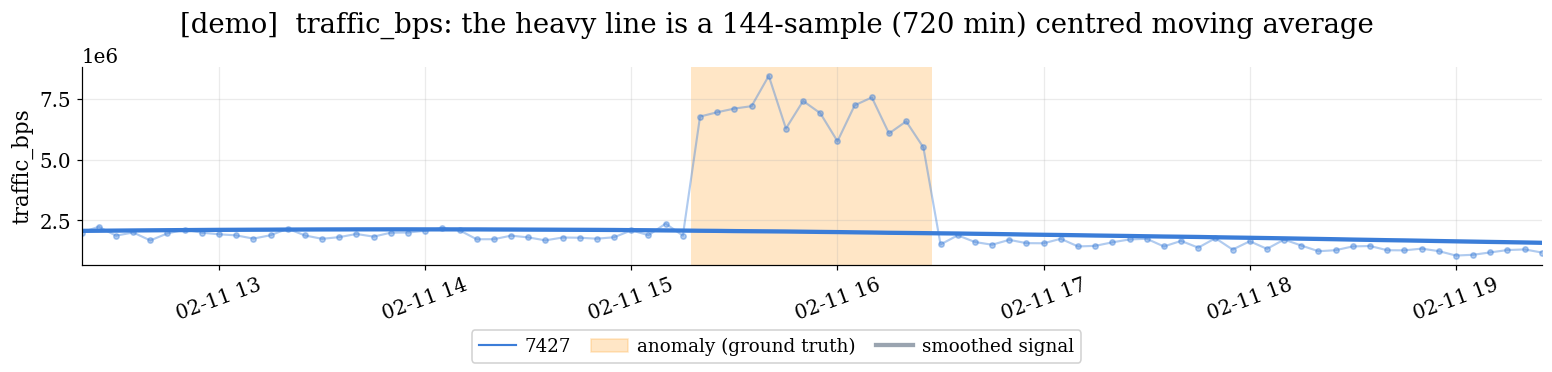

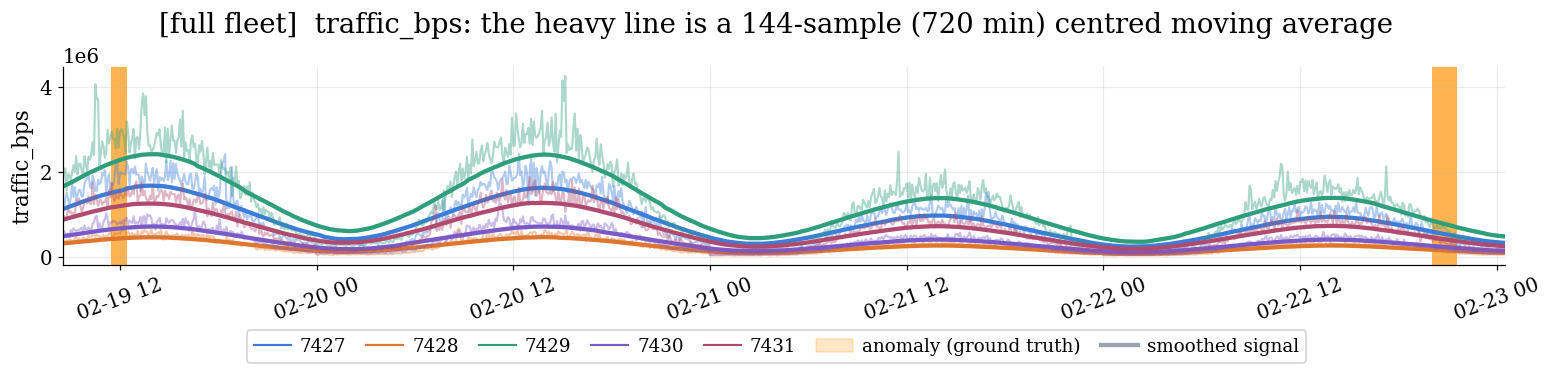

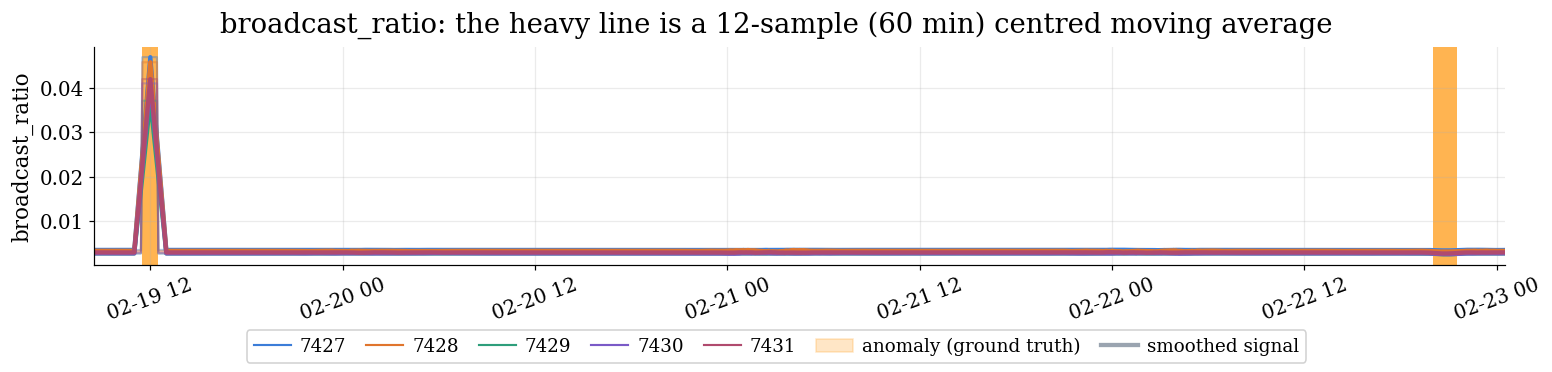

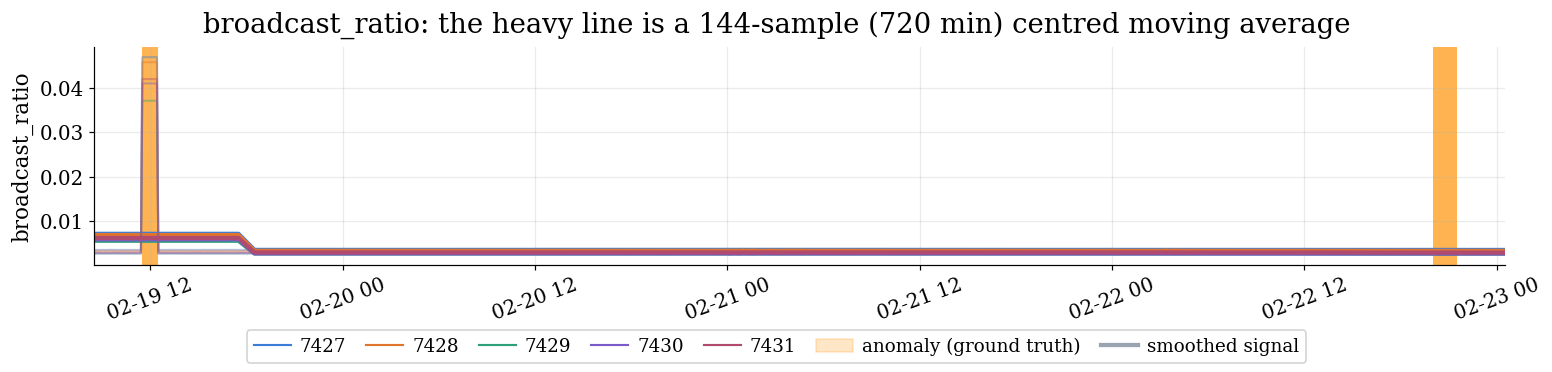

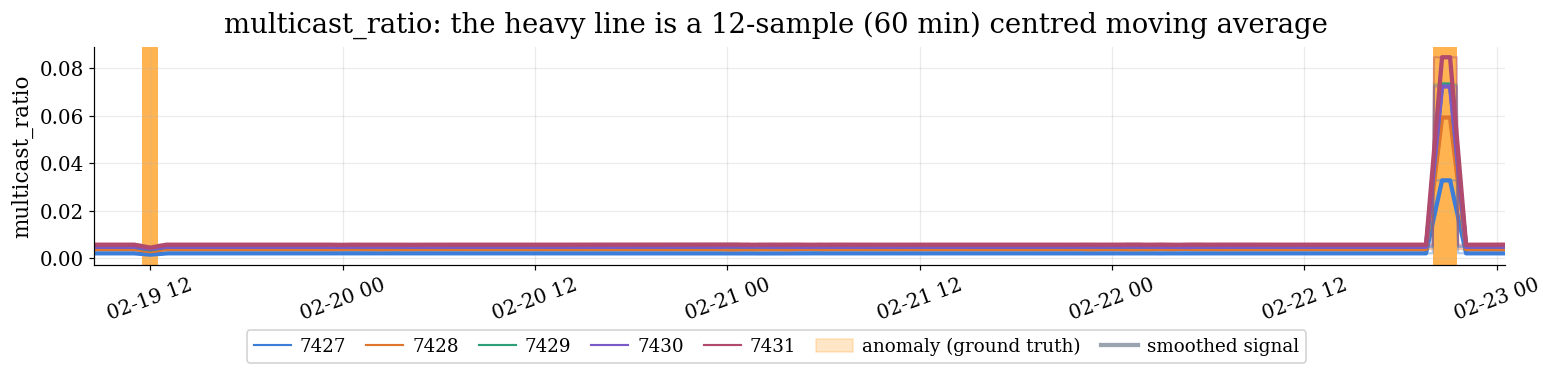

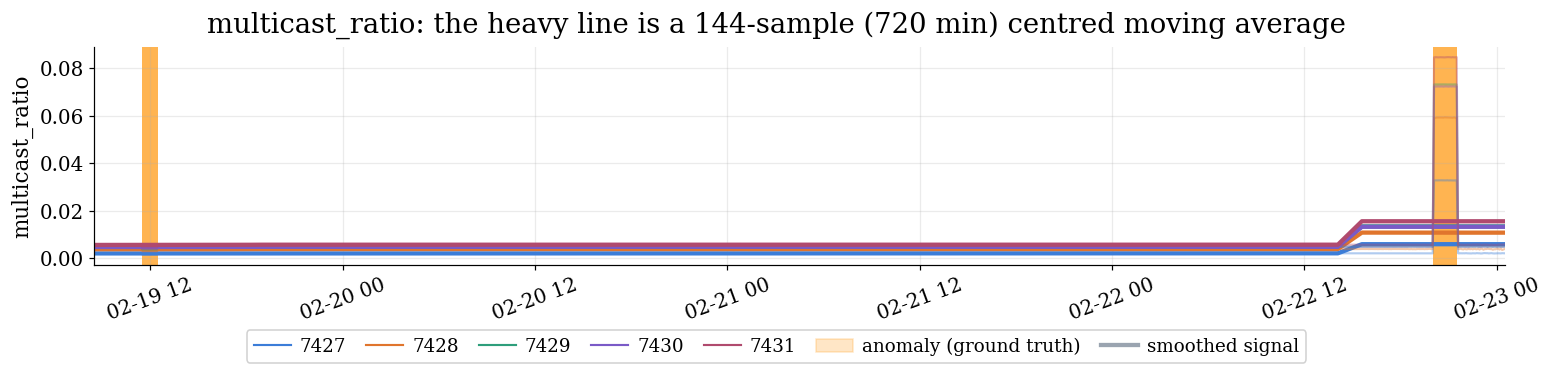

In [17]:
def moving_average(col, m, data=None, ports=None):
    """Centred moving average of `col`, per port, aligned to the frame.

    Centred means each point averages the `m//2` samples on either side of it, so this series
    cannot be computed online: at time t it needs samples that have not arrived. It is a view of
    the signal, never a baseline — hence `smoothed=` rather than `baselines=` at the call site.
    """
    data = df if data is None else data
    ports = PORTS if ports is None else ports
    out = pd.Series(np.nan, index=data.index)
    for pid in ports:
        v = data.loc[data["port_id"] == pid, col]
        out.loc[v.index] = v.rolling(m, center=True, min_periods=1).mean()
    return out


for col in COLUMNS:
    for m in SMOOTH_SHOWN:
        # `show` (defined in 9a) sends the demo column through the demo-then-full pair and
        # every other column through plot_signals alone, unchanged.
        show(col, half=HALF, data=df, columns=[col], ports=PORTS, events=ZOOM_EVENTS,
                     # smoothed=, not baselines=. A centred average is the signal filtered, not a
                     # reference it can be scored against — and it reads the future besides.
                     smoothed={col: moving_average(col, m, data=df, ports=PORTS)},
                     baselines=None, bands=None, alerts=None, outcomes=False, by_port=False,
                     zoom_anomaly=True, zoom_signal=False, pad="3h",
                     title=f"{col}: the heavy line is a {m}-sample "
                           f"({m * CADENCE / 60:.0f} min) centred moving average")

# # How much of the event's height each average keeps, per column and per length.
# kept = {}
# for col in COLUMNS:
#     win = anomaly_windows(df, ZOOM_EVENTS, PORTS)
#     inside = df["timestamp"].between(win["start"].min(), win["end"].max())
#     peak = df.loc[inside, col].max()
#     kept[col] = {f"{m} ({m * CADENCE / 60:.0f} min)":
#                  moving_average(col, m, data=df, ports=PORTS)[inside].max() / peak
#                  for m in SMOOTH_SWEEP}
# heatmap(pd.DataFrame(kept), fmt="{:.0%}", cbar_label="peak kept",
#         title="fraction of the event's peak that survives the average\n(higher is better)")

In [18]:
# rows = []
# for col in COLUMNS:
#     for w in WINDOW_SWEEP:
#         for kind in ("mean", "robust"):
#             score = rolling_baseline(data=df, col=col, window=w, kind=kind,
#                                      ports=PORTS, lag=1)[2]
#             r = report(alerts={"x": confirm(breach=score > THRESHOLD, data=df, n=N_CONSEC)},
#                        data=df, ports=PORTS, events="all").iloc[0]
#             caught, total = r["anomaly_recall"].split("/")
#             rows.append({"column": col, "kind": kind, "window": w,
#                          "hours": round(w * CADENCE / 3600, 1),
#                          "anomaly_recall": int(caught), "of": int(total),
#                          "alerts_per_day": r["alerts_per_day"], "delay_min": r["delay_min"]})
# sweep = pd.DataFrame(rows)

# for metric, fmt, log, direction in [("anomaly_recall", "{:.0f}", False, "higher is better"),
#                                     ("alerts_per_day", "{:.2f}", True, "lower is better")]:
#     grid = sweep.pivot_table(index="hours", columns=["column", "kind"], values=metric)
#     grid.columns = [f"{c} · {k}" for c, k in grid.columns]
#     grid.index = [f"{h:g} h" for h in grid.index]
#     heatmap(grid, fmt=fmt, log=log, cbar_label=metric,
#             title=f"window sweep — {metric.replace('_', ' ')} ({direction})")

In [19]:
# w, h = plt.rcParams["figure.figsize"]
# fig, axes = plt.subplots(2, len(COLUMNS), figsize=(w * 1.15, h * 1.9), sharex=True)
# for j, col in enumerate(COLUMNS):
#     d = sweep[sweep["column"] == col]
#     for kind, c in [("mean", C["signal"]), ("robust", C["peer"])]:
#         k = d[d["kind"] == kind]
#         axes[0, j].plot(k["hours"], k["anomaly_recall"], "-o", color=c, label=kind)
#         axes[1, j].plot(k["hours"], k["alerts_per_day"].clip(lower=0.01), "-o", color=c,
#                         label=kind)
#     axes[0, j].axhline(d["of"].max(), color=C["truth"], ls="--", label="all windows")
#     axes[0, j].set(title=col, ylabel="anomaly windows caught")
#     axes[1, j].set(xscale="log", yscale="log", xlabel="baseline window (hours, log)",
#                    ylabel="alerts per day (log)")
#     axes[0, j].legend()
# plt.show()

### 9d — One window is rarely enough

Different window lengths see different phenomena, so build a few on purpose instead of sweeping
for a single winner.

| scale | statistic | what it catches |
|---|---|---|
| 1 min | max, count, difference | instantaneous spikes and outages |
| 5 min | mean, sd, p95 | short service degradation |
| 1 hour | median, trend slope | slow drift and capacity pressure |
| 1 day | seasonal baseline | day/night deviation |
| 1 week | same-time comparison | weekday against weekend |

The cheapest useful combination is two: a short window against a long one. Their difference is a
level-shift signal that neither provides alone.

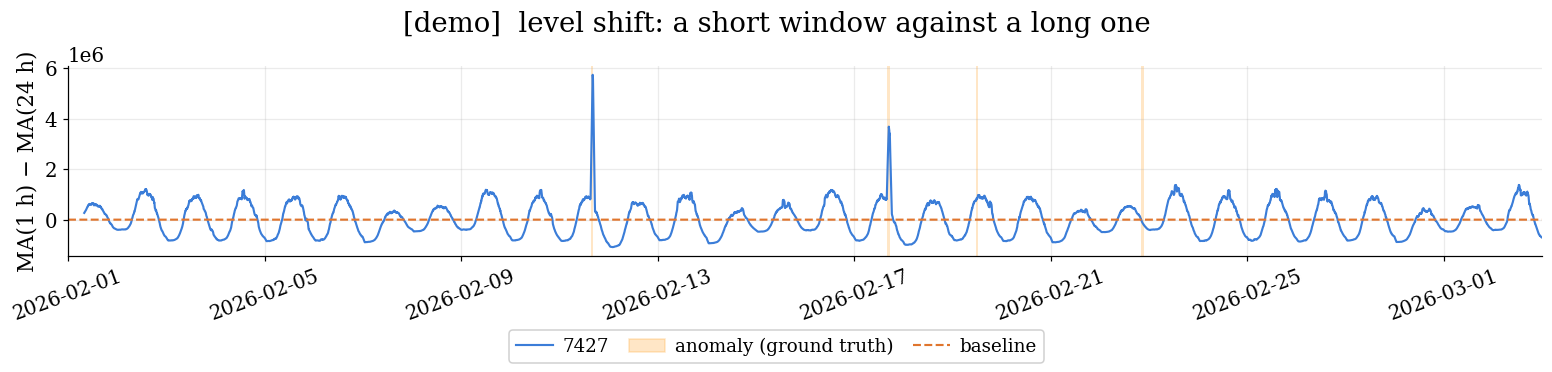

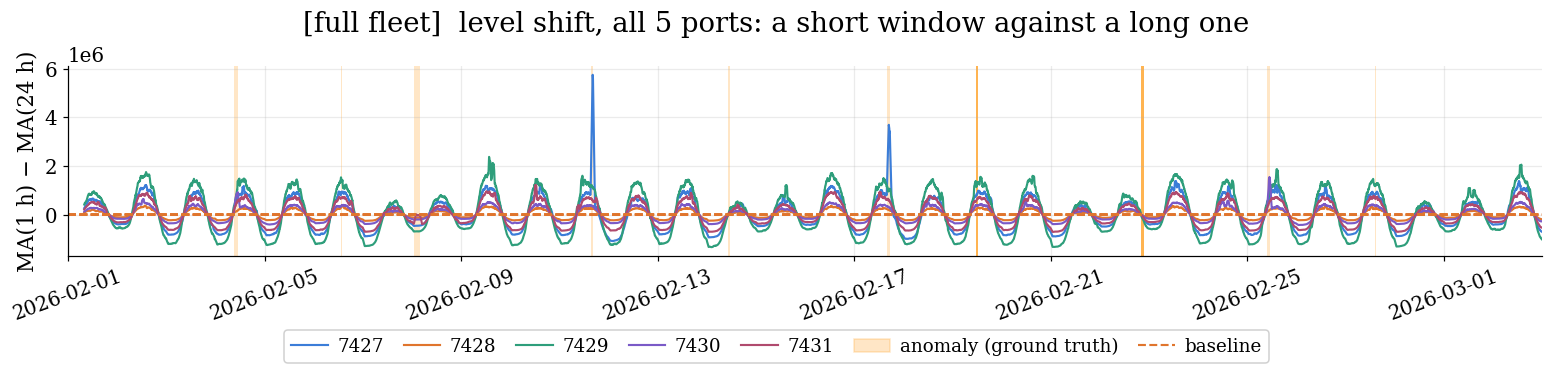

In [20]:
level = pd.Series(np.nan, index=df.index)
for pid in PORTS:
    v = df.loc[df["port_id"] == pid, COLUMNS[0]]
    level.loc[v.index] = (v.rolling(12, min_periods=3).mean()
                          - v.rolling(288, min_periods=96).mean())

# The difference of two averages is a signal in its own right, so it enters as a column and
# `plot_signals` draws it the way it draws every other one. Zero is the reference it is read
# against — above it the last hour is running hotter than the last day — which is `baselines=`.
LEVEL = "MA(1 h) − MA(24 h)"
# Whole month, on purpose (events="all"): the point is the daily oscillation itself, so only
# the port narrows for the demo pass, not the time range.
plot_signals(half=HALF, data=df.assign(**{LEVEL: level}), columns=[LEVEL],
             ports=[BASELINE_DEMO["port"]], events="all",
             baselines={LEVEL: pd.Series(0.0, index=df.index)},
             alerts=None, bands=None, outcomes=False, by_port=False,
             zoom_anomaly=False, zoom_signal=False,
             title="[demo]  level shift: a short window against a long one")
plot_signals(half=HALF, data=df.assign(**{LEVEL: level}), columns=[LEVEL], ports=PORTS, events="all",
             baselines={LEVEL: pd.Series(0.0, index=df.index)},
             alerts=None, bands=None, outcomes=False, by_port=False,
             zoom_anomaly=False, zoom_signal=False,
             title="[full fleet]  level shift, all 5 ports: a short window against a long one")

- **The trace oscillates with the daily cycle — expected:** 09:00's last hour really does run
  above the last day.
- **Value:** a genuine level change pushes it off that oscillation and keeps it there — a change
  point. Lab 02 builds that comparison properly with two adjacent windows.
- **Multi-scale features cost dimension and correlation** — neighbouring windows are correlated
  by construction. Choose scales from the phenomena you need; don't enumerate.

## Step 10 — Baselines 4, 5 and 6, one at a time

Three more answers to "compared to what", taken separately because they fail in different places
and the failures are the lesson. Each sub-step builds one baseline, draws it, and names the
precondition it rests on.

| | compared against | needs | fails when |
|---|---|---|---|
| **10a** robust | its own recent history, by median and MAD | a window | over half the window is identical |
| **10b** seasonal | the same hour on other days | weeks of history | the rhythm shifts for a legitimate reason |
| **10c** peer | the other ports at the same instant | comparable ports | the peers are not comparable, or all move together |

The third one is left unfinished on purpose, and the reason is at 10c.

### 10a — Robust: the median survives what the mean does not

- **Same rolling window as Step 9** — median for mean, MAD for standard deviation.
- **Step 9a already showed the payoff:** a median needs over half its window contaminated to
  move.
- **It costs something too — `traffic_bps` shows it.** Draw both on the largest-swing port and
  compare the bands, not the recall.

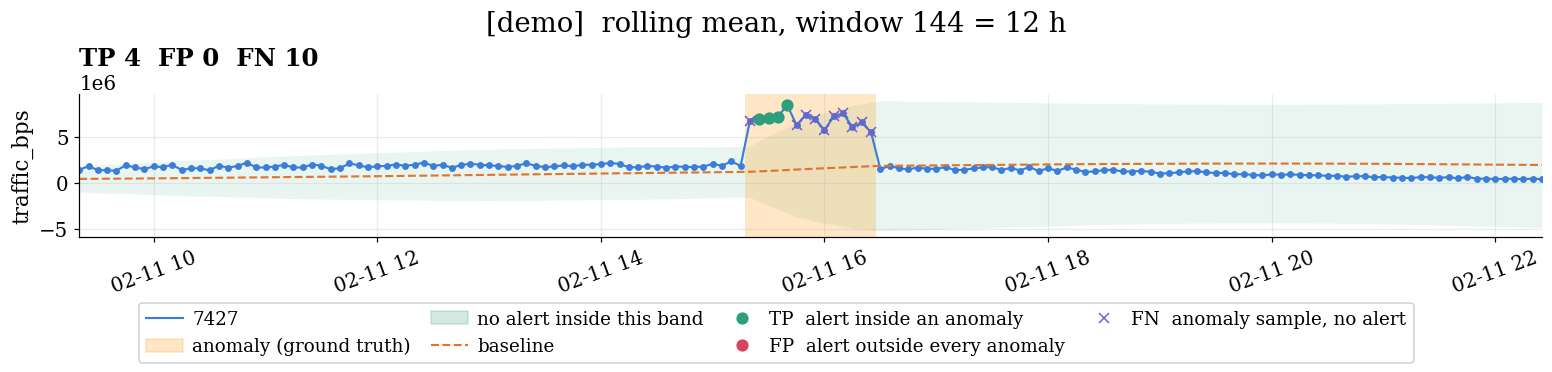

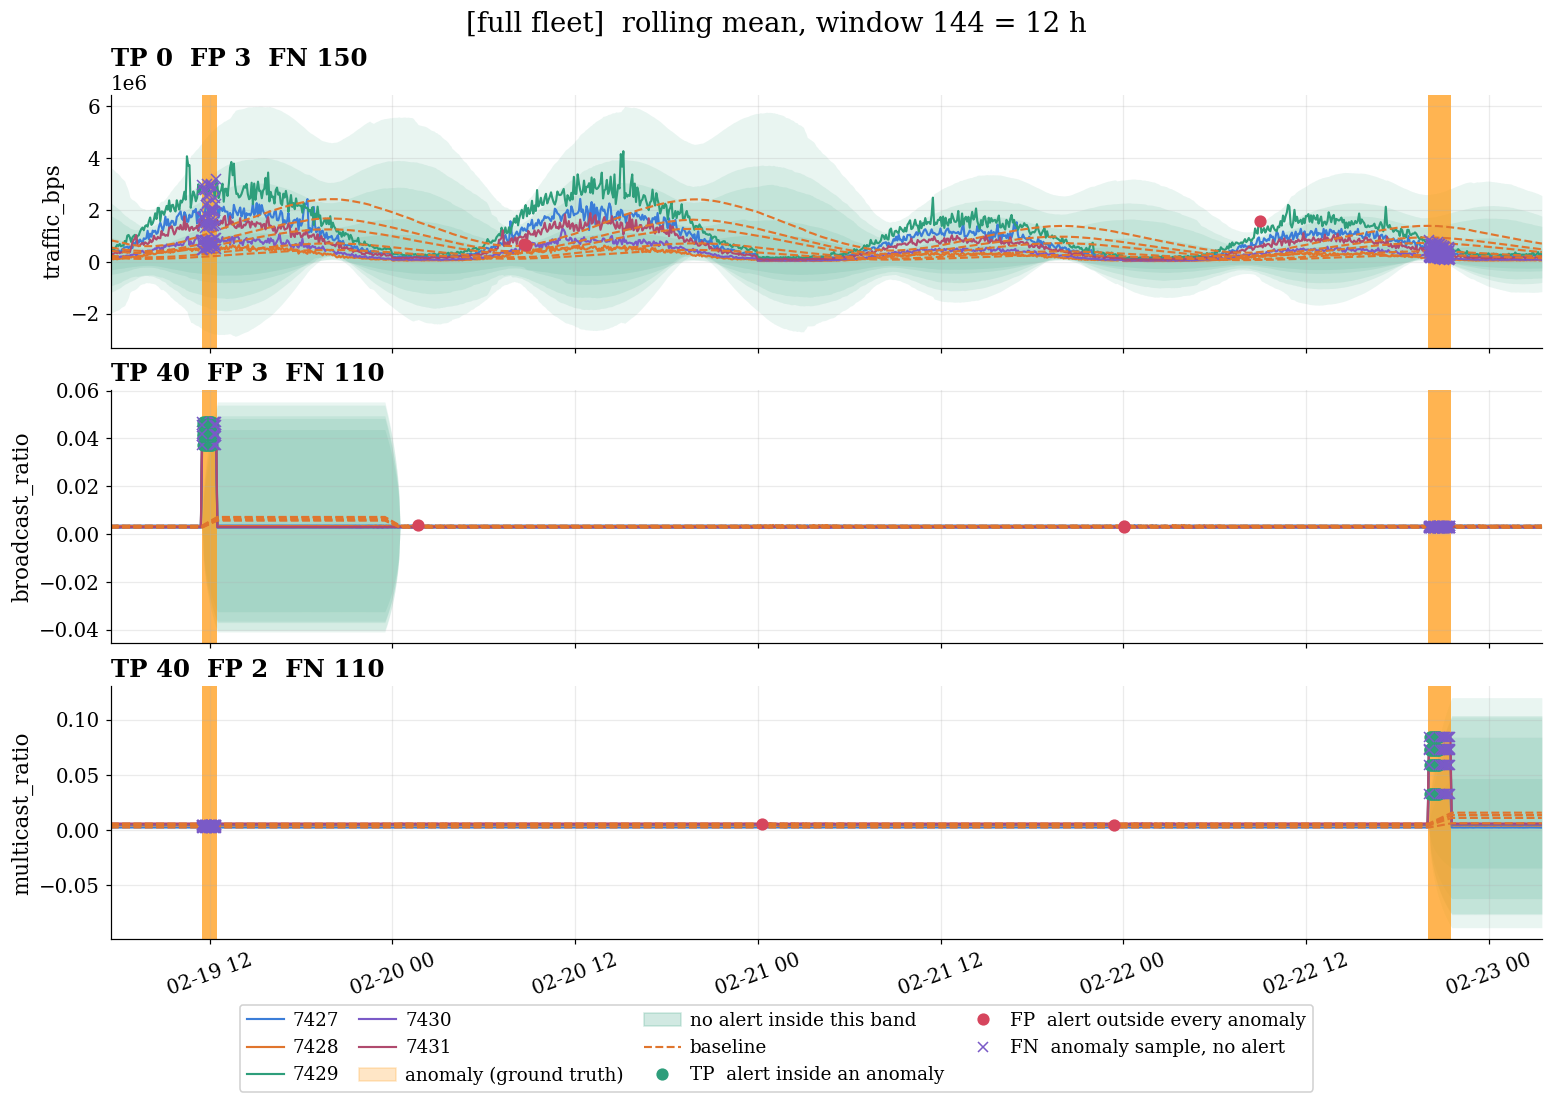

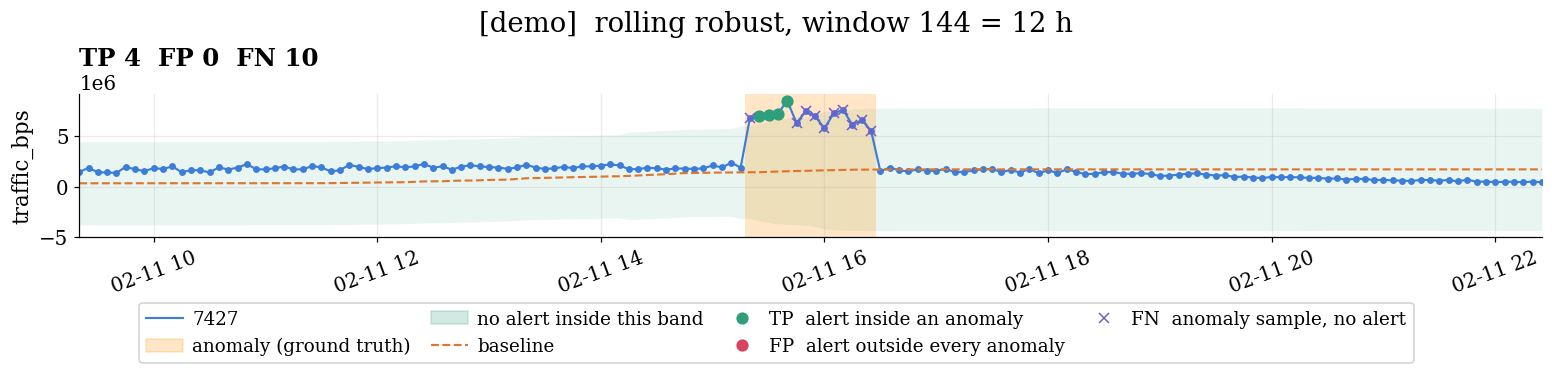

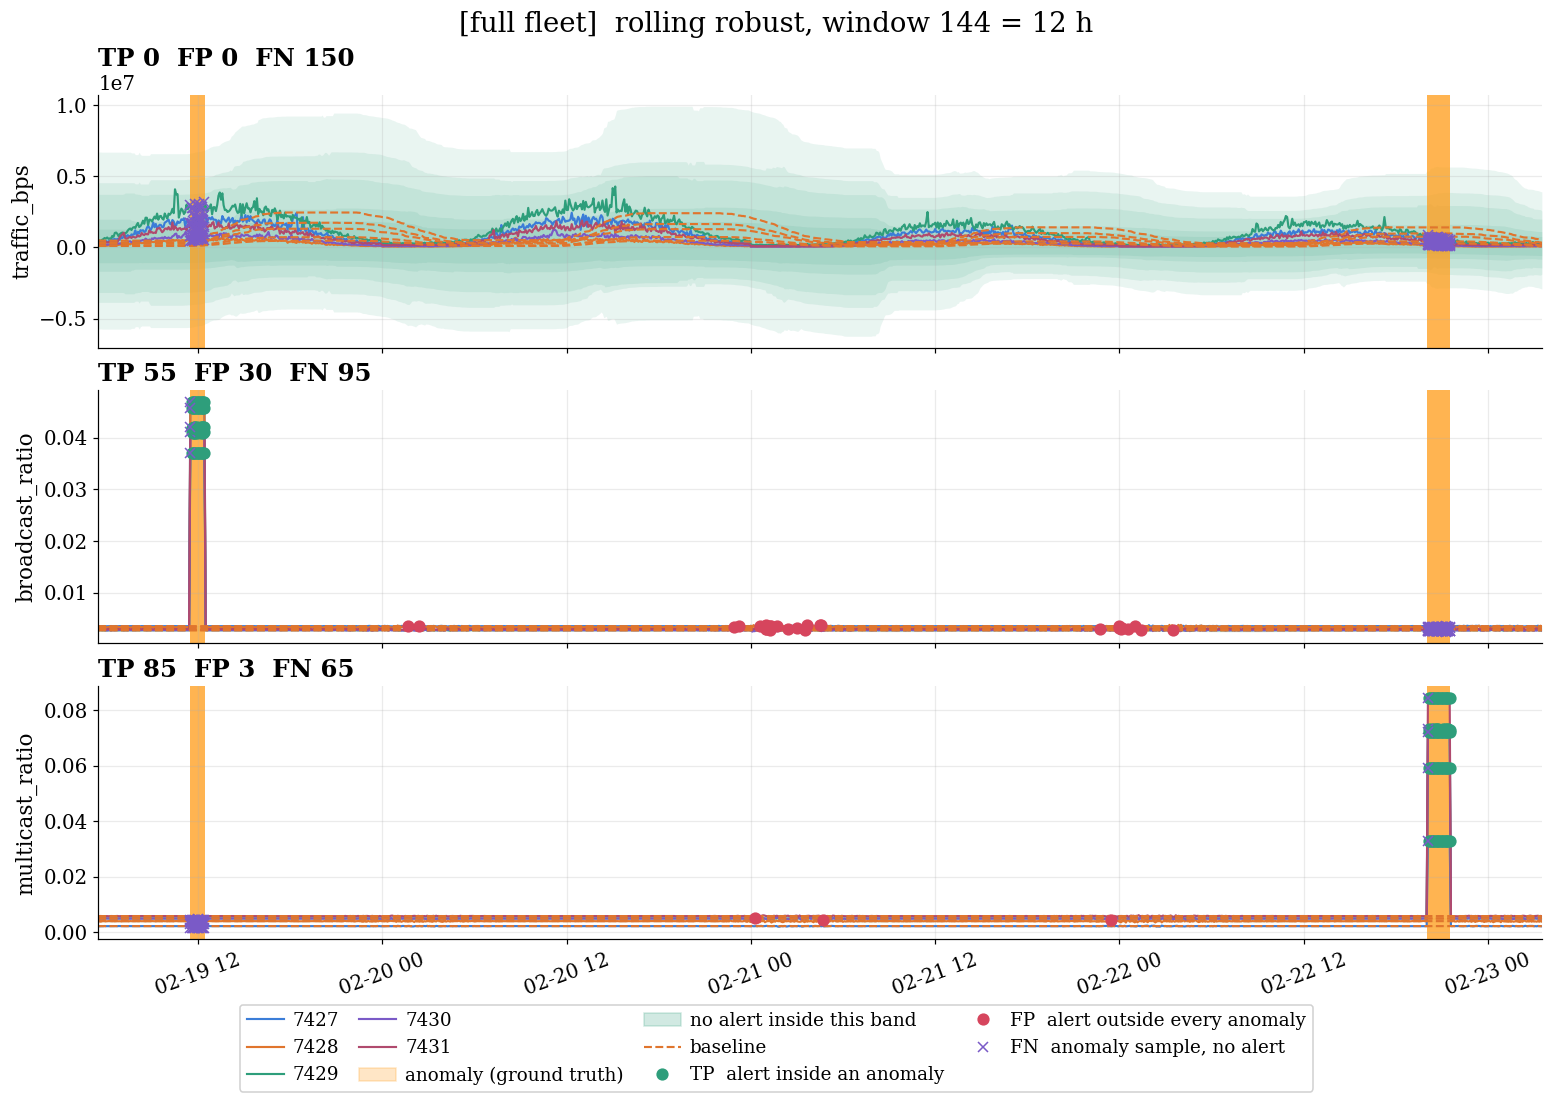

In [21]:
for kind in ("mean", "robust"):
    centre, scale, score = {}, {}, {}
    for col in COLUMNS:
        centre[col], scale[col], score[col] = rolling_baseline(
            data=df, col=col, window=WINDOW, kind=kind, ports=PORTS, lag=1)
    bands = {c: (centre[c] - THRESHOLD * scale[c], centre[c] + THRESHOLD * scale[c])
             for c in COLUMNS}
    alerts = {c: confirm(breach=score[c] > THRESHOLD, data=df, n=N_CONSEC) for c in COLUMNS}
    plot_signals(half=HALF, data=df, columns=[BASELINE_DEMO["column"]],
                 ports=[BASELINE_DEMO["port"]], events=[BASELINE_DEMO["event"]],
                 baselines=centre, bands=bands, alerts=alerts,
                 outcomes=True, by_port=False, zoom_anomaly=True, zoom_signal=False, pad="6h",
                 title=f"[demo]  rolling {kind}, window {WINDOW} = {WINDOW * CADENCE / 3600:.0f} h")
    plot_signals(half=HALF, data=df, columns=COLUMNS, ports=PORTS, events=ZOOM_EVENTS,
                 baselines=centre, bands=bands, alerts=alerts,
                 outcomes=True, by_port=False, zoom_anomaly=True, zoom_signal=False, pad="6h",
                 title=f"[full fleet]  rolling {kind}, window {WINDOW} = "
                       f"{WINDOW * CADENCE / 3600:.0f} h")

**Neither band is the shape you would guess, and both are wide.** A 12-hour spread estimate of a
signal that swings tenfold measures the daily swing, not the noise.

- **The robust band is 2.5× the wider.**
  - Median half-width 6.3e6 — **1.14× the entire range this signal covers all month**.
  - A band wider than the data excludes nothing: zero true positives.
  - All 29 of its alerts sit in the warm-up.
- **The culprit is the constant 1.4826.**
  - It converts MAD to σ *for a normal distribution*.
  - A 12-hour window holds a stretch of night and a stretch of day, so values pile at two levels.
  - On that shape the MAD sits near the half-range and the conversion overstates.
  - **The estimator is fine; the assumption converting it to sigma units is not.**
- **Both bands pinch twice a day.**
  - The window is 144 samples against a 288-sample cycle — exactly half a period.
  - Flat top or flat floor: little variation. On the flank: the whole climb.
  - Mean scale runs **0.35e6 at 07:00 to 1.01e6 at 14:00**, a factor of three in sensitivity.

**Robustness is not a free upgrade, and at this window it is not an upgrade at all.**

- What it buys is resistance to contamination *inside* the window.
- 9c measured where that pays: at 30 minutes the mean catches 0 windows, robust catches 5.
- By 12 hours neither is contaminated and only the cost is left.

### Where the MAD breaks entirely

Both robust methods divide by a MAD. Check it exists before trusting it.

In [22]:
rows = []
for col in FEATURES:
    for pid in PORTS:
        v = df.loc[df["port_id"] == pid, col]
        z = pd.Series(ss.zscore(v, ddof=0), index=v.index)
        truth = df.loc[v.index, "event_label"] != "normal"
        rows.append({"column": col, "port": pid[-4:], "zero_frac": (v == 0).mean(),
                     "MAD": float(np.median(np.abs(v - v.median()))),
                     "robust_z_defined": not bool(np.isnan(modified_zscore(v)).all()),
                     "plain_z_alerts": int((z > THRESHOLD).sum()),
                     "of_which_true": int(((z > THRESHOLD) & truth).sum())})
mad_break = pd.DataFrame(rows)
print(f"{int((~mad_break['robust_z_defined']).sum())} of {len(mad_break)} (column, port) pairs "
      f"have an undefined robust score; all of them have MAD = 0")
mad_break.groupby("column").agg(zero_frac=("zero_frac", "mean"),
                                ports_with_zero_MAD=("robust_z_defined", lambda v: int((~v).sum())),
                                plain_z_alerts=("plain_z_alerts", "sum"),
                                of_which_true=("of_which_true", "sum")).sort_values("zero_frac")

30 of 65 (column, port) pairs have an undefined robust score; all of them have MAD = 0


,zero_frac,ports_with_zero_MAD,plain_z_alerts,of_which_true
column,,,,
avg_pkt_bytes,0.000000,0,56,54
broadcast_ratio,0.000000,0,60,60
multicast_ratio,0.000000,0,90,90
nonucast_ratio,0.000000,0,60,60
packets_pps,0.000000,0,53,43
traffic_bps,0.000000,0,58,49
tx_ratio,0.000000,0,16,16
err_disc_rate,0.890394,5,163,163
discard_rate,0.912917,5,163,163


**30 of the 65 (column, port) pairs have no robust score at all** — every sparse column on every
port, because the median is zero and so is the MAD.

**But the plain z-score is not the rescue it looked like on one column.**

- **`discard_rate`, `discards_pps`, `err_disc_rate` — perfect.** 163, 135 and 163 alerts, every one
  inside a labelled anomaly.
- **`errors_pps` — 635 alerts, 21 of them true.** `error_rate` 270 and 20. `unknown_proto_pps` 354
  and 16.
- **Same rule, same kind of column, opposite outcome.** A z-score on a mostly-zero column divides by
  a standard deviation built almost entirely out of the few non-zero readings, so whether it works
  depends on how those readings are distributed and not on anything you can see from the zero
  fraction.

**A NaN column and a quiet column look identical on a dashboard.** Check the MAD, and then check the
alternative you fall back to, because the fallback fails silently on four of these six.

### 10b — Seasonal: the same hour, on other days

- **Same statistic, different comparison set:** every sample at this one's position in the cycle
  — 10:00 today against every other 10:00 on that port, not the last `w` samples.
- **Only works if the day has a shape — measure it first.**
  - Autocorrelation: does the series repeat, at what lag.
  - Median profile: what the repeating shape is.
  - One FFT gives every lag at once.

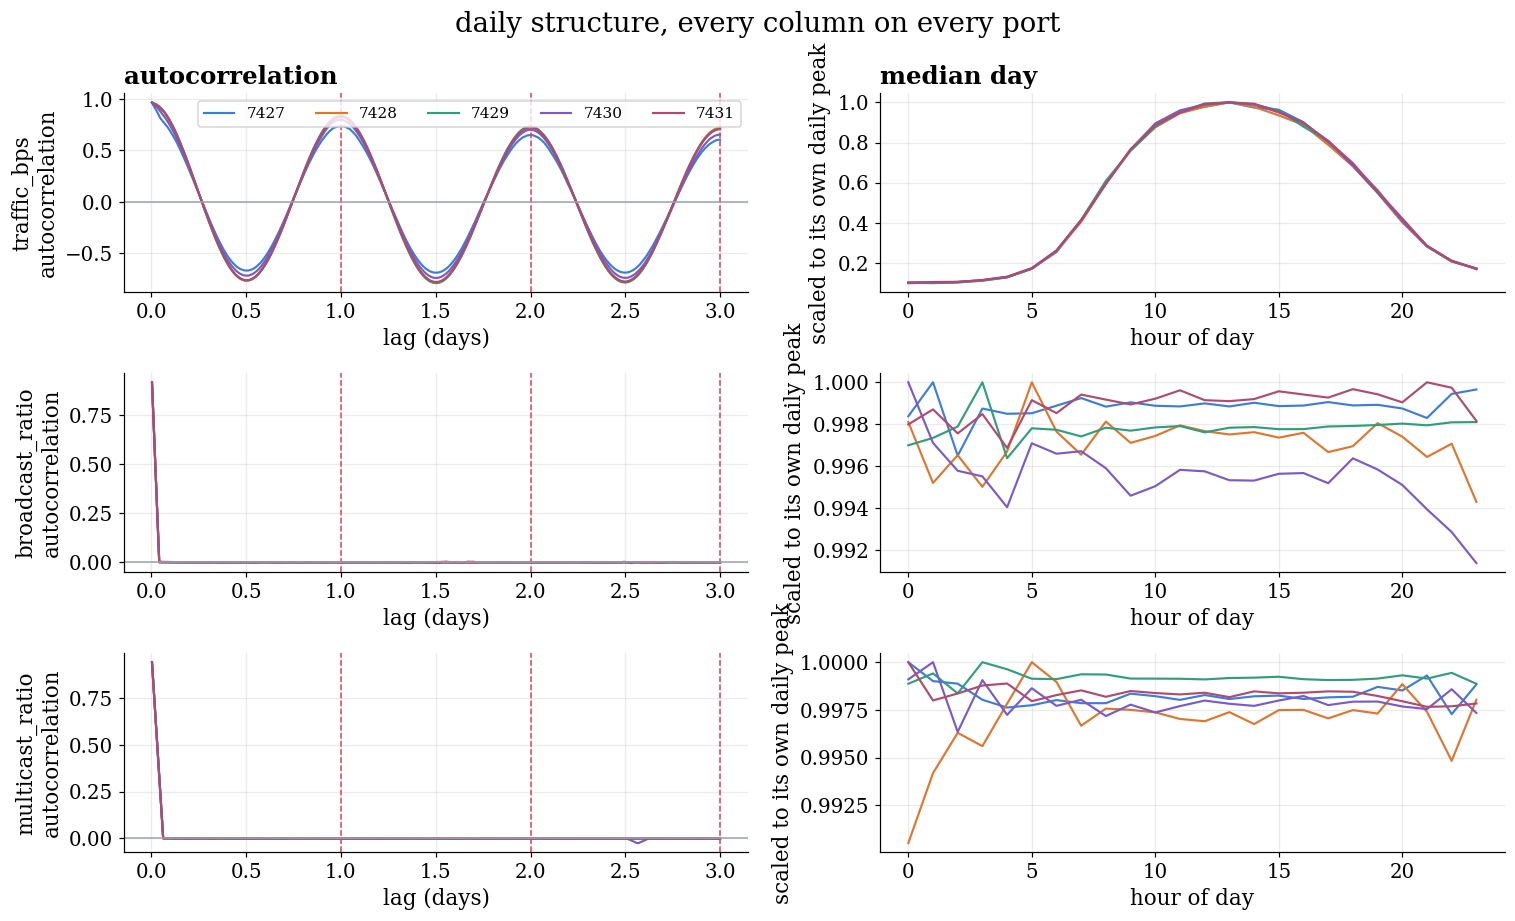

acf_at_1_day  best_repeat_lag_h  trough_over_peak
column          port                                                   
traffic_bps     7427         0.734               24.2             0.100
                7428         0.833               23.9             0.099
                7429         0.832               24.1             0.100
                7430         0.798               23.9             0.103
                7431         0.827               24.0             0.102
broadcast_ratio 7427        -0.001               63.8             0.997
                7428        -0.001               37.3             0.994
                7429        -0.001               12.3             0.996
                7430        -0.001               60.5             0.991
                7431        -0.001               59.8             0.997
multicast_ratio 7427        -0.002               19.2             0.997
                7428        -0.002               30.4             0.991
                7429        -0.002               16.7             0.998
                7430        -0.002               43.8             0.996
                7431        -0.002               19.7             0.998

In [23]:
def acf(x, nlags):
    """Autocorrelation at lags 1..nlags, all of them from one FFT."""
    v = np.asarray(x, dtype=float)
    v = v - v.mean()
    n = 1 << int(np.ceil(np.log2(2 * len(v))))
    f = np.fft.rfft(v, n)
    r = np.fft.irfft(f * np.conj(f), n)[:nlags + 1]
    return r[1:] / r[0]


w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(len(COLUMNS), 2, figsize=(w, h * 0.62 * len(COLUMNS)), squeeze=False)
peaks = []
far = PERIOD // 2          # ignore lags too short to be a cycle: lag 1 only says "smooth"
for r, col in enumerate(COLUMNS):
    for k, pid in enumerate(PORTS):
        g = df[df["port_id"] == pid].sort_values("timestamp")
        a = acf(g[col], nlags=3 * PERIOD)
        axes[r, 0].plot(np.arange(1, len(a) + 1) / PERIOD, a,
                        color=PORT_C[k % len(PORT_C)], label=pid[-4:])
        prof = g.groupby(g["timestamp"].dt.hour)[col].median()
        axes[r, 1].plot(prof.index, prof / prof.max(),
                        color=PORT_C[k % len(PORT_C)], label=pid[-4:])
        peaks.append({"column": col, "port": pid[-4:],
                      "acf_at_1_day": round(float(a[PERIOD - 1]), 3),
                      "best_repeat_lag_h": round(float((np.argmax(a[far:]) + far + 1)
                                                       * CADENCE / 3600), 1),
                      "trough_over_peak": round(float(prof.min() / prof.max()), 3)})
    for d in (1, 2, 3):
        axes[r, 0].axvline(d, color=C["alert"], ls="--", lw=1)
    axes[r, 0].axhline(0, color=C["muted"], lw=1)
    axes[r, 0].set(xlabel="lag (days)", ylabel=f"{col}\nautocorrelation")
    axes[r, 1].set(xlabel="hour of day", ylabel="scaled to its own daily peak")
axes[0, 0].set_title("autocorrelation")
axes[0, 1].set_title("median day")
axes[0, 0].legend(ncol=5, fontsize=plt.rcParams["legend.fontsize"] - 2)
fig.suptitle("daily structure, every column on every port")
plt.show()

display(pd.DataFrame(peaks).set_index(["column", "port"]))

**Seasonality is a property of the column, not of the fleet.** Run it on all three and the table
splits cleanly in two.

- **`traffic_bps` has a strong daily cycle on every port.**
  - Autocorrelation at a one-day lag: 0.73 to 0.83.
  - Strongest repeat beyond half a period: 23.9 to 24.2 hours.
  - `trough_over_peak` near 0.10 — the night runs at a tenth of the daytime peak.
- **The two ratio columns have none at all.**
  - Autocorrelation at one day: **−0.001**. The strongest repeat lands anywhere between 12 and 64
    hours, which is what noise looks like when you take its argmax.
  - `trough_over_peak` above **0.99** — the median hour is flat.
- **So a seasonal baseline is only worth building on `traffic_bps` here.** On the ratio columns it
  will fit a profile to noise, and Step 10d's scorecard is where you see what that costs.

**The bucket key is still the design decision,** and it is a bet about which cycle exists.

- `by=("hour",)` assumes every day is the same.
- `by=("hour", "dayofweek")` is usually truer and costs history: 168 buckets per port instead of 24,
  so a month gives each cell four samples.

#### The regime, and why the bucket key is the whole design

- **A regime is a bucket:** conditions under which "normal" means one thing. Weekday 09:00 is one
  regime; Sunday 03:00 is another.
- **The diurnal shape is an operating condition, not an anomaly** — a baseline blind to regime
  reports the condition instead of the fault.
- **`REGIME_BY` (Step 4) is the key.** Each distinct value is a cell with its own centre and
  scale, fitted only on that cell's samples. The grid shows what the detector actually compares
  against.

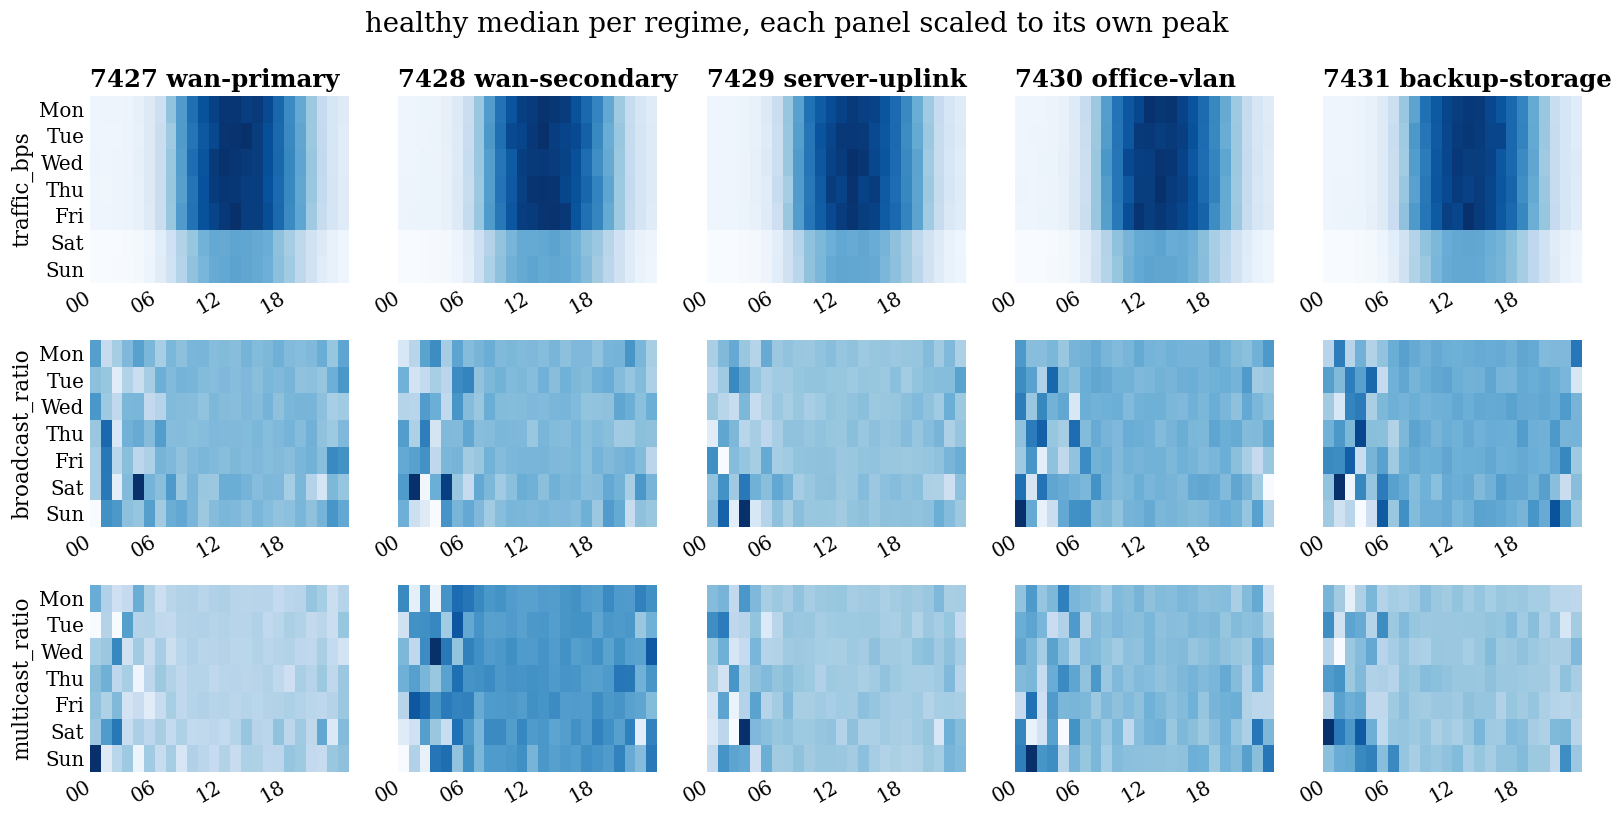

240 regime cells (5 ports x 2 day types x 24 hours)


,feature,zero_fraction_month,regimes_with_zero_scale,kind
0,traffic_bps,0.0000,0.0,statistical
1,packets_pps,0.0000,0.0,statistical
5,avg_pkt_bytes,0.0000,0.0,statistical
6,broadcast_ratio,0.0000,0.0,statistical
7,multicast_ratio,0.0000,0.0,statistical
8,nonucast_ratio,0.0000,0.0,statistical
9,tx_ratio,0.0000,0.0,statistical
2,errors_pps,0.9755,1.0,boundary
3,discards_pps,0.9129,1.0,boundary
4,unknown_proto_pps,0.9896,1.0,boundary


In [24]:
# The full regime grid, weekday x hour, on healthy samples only. Each port on its own scale,
# because the question is the shape of its day rather than how much traffic it carries.
DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]   # not DAYS: Step 2 owns that
quiet = df[df["event_label"] == "normal"]
w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(len(COLUMNS), len(PORTS),
                         figsize=(w * 1.05, h * 0.55 * len(COLUMNS)), squeeze=False)
for r, col in enumerate(COLUMNS):
    for k, pid in enumerate(PORTS):
        g = quiet[quiet["port_id"] == pid]
        grid = (g.groupby([g["timestamp"].dt.dayofweek, g["timestamp"].dt.hour])[col]
                 .median().unstack())
        grid.index, grid.columns = DAY_NAMES, [f"{c:02d}" for c in grid.columns]
        heatmap(grid / grid.to_numpy().max(), ax=axes[r, k], annotate=False,
                title=f"{pid[-4:]} {g['port_role'].iloc[0]}" if r == 0 else None)
        axes[r, k].set_xticks(range(0, 24, 6), [f"{c:02d}" for c in range(0, 24, 6)])
        if k:
            axes[r, k].set_yticks([])
        else:
            axes[r, k].set_ylabel(col)
fig.suptitle("healthy median per regime, each panel scaled to its own peak")
plt.show()

# A scale that cannot be divided by is a per-regime property, not a global one. Step 2 split the
# features on their zero fraction over the whole month; this asks the sharper question.
mad = lambda v: float(np.median(np.abs(v - np.median(v))) * 1.4826)
reg = np.where(quiet["timestamp"].dt.dayofweek >= 5, "wknd ", "wk ") + \
      quiet["timestamp"].dt.hour.astype(str)
rows = [{"feature": f,
         "zero_fraction_month": round(float((df[f] == 0).mean()), 4),
         "regimes_with_zero_scale": round(
             float((quiet.groupby([quiet["port_id"], reg])[f].apply(mad) <= 0).mean()), 4),
         "kind": "statistical" if f in SCORABLE else "boundary"}
        for f in FEATURES]
regime_scale = pd.DataFrame(rows).sort_values("regimes_with_zero_scale")
print(f"{quiet.groupby([quiet['port_id'], reg]).ngroups} regime cells "
      f"({len(PORTS)} ports x 2 day types x 24 hours)")
regime_scale

**The grid is the daily shape drawn as a map,** and it says two things the line plot cannot.

- **Every port's bright band sits in the working day.**
- **The weekend rows are dimmer on all five,** at 0.58–0.60 of the weekday median — not only on the
  office-facing ports. So `dayofweek` is a real second dimension here, not a hypothesis.

**The table asks the sharper precondition question.** Step 2 split the features on their zero
fraction over the whole month; inside a regime the test is stricter.

- **A feature can be non-zero overall and still have no spread inside its cell,** and dividing by
  that scale is the same failure as dividing by zero.
- **On this data the two rules agree exactly.** Zero-MAD in **0%** of the 240 regime cells for the
  seven scorable features, **100%** for the six sparse ones.
- **That agreement is a property of this fleet, not a theorem.** A port that idles overnight can have
  a healthy month-long spread and a flat 03:00 regime; only the per-regime test sees it.
- **So the split has a name and a consequence.** `statistical` features get a regime z-score;
  `boundary` features get the fixed limit from Step 6 — the same division, reached from the other
  direction.

The floor in `seasonal_baseline` is what stops a nearly-flat regime producing a huge score, and it is
relative rather than absolute for the same reason the regime is: what counts as a small spread
depends on the level the cell sits at.

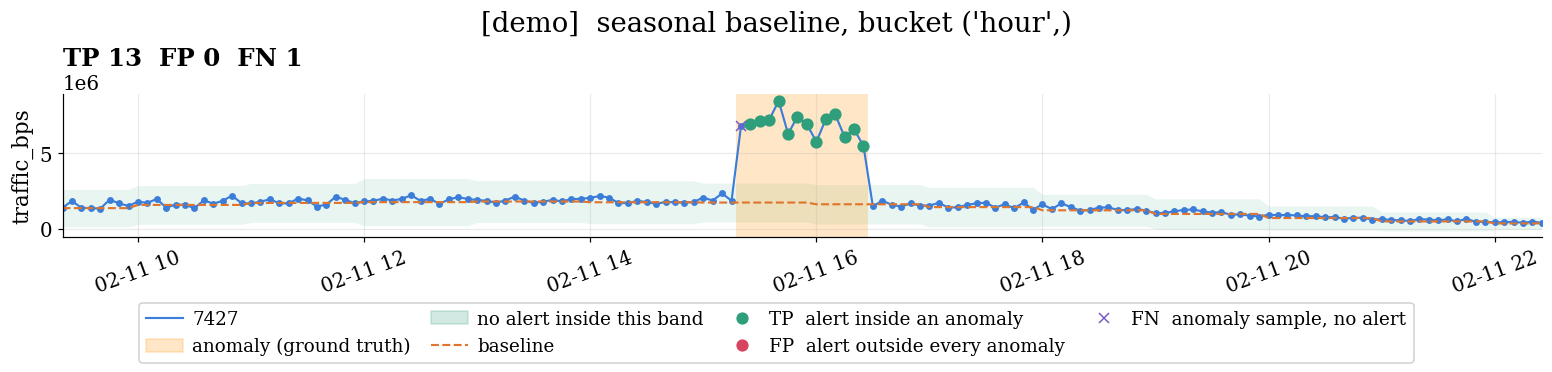

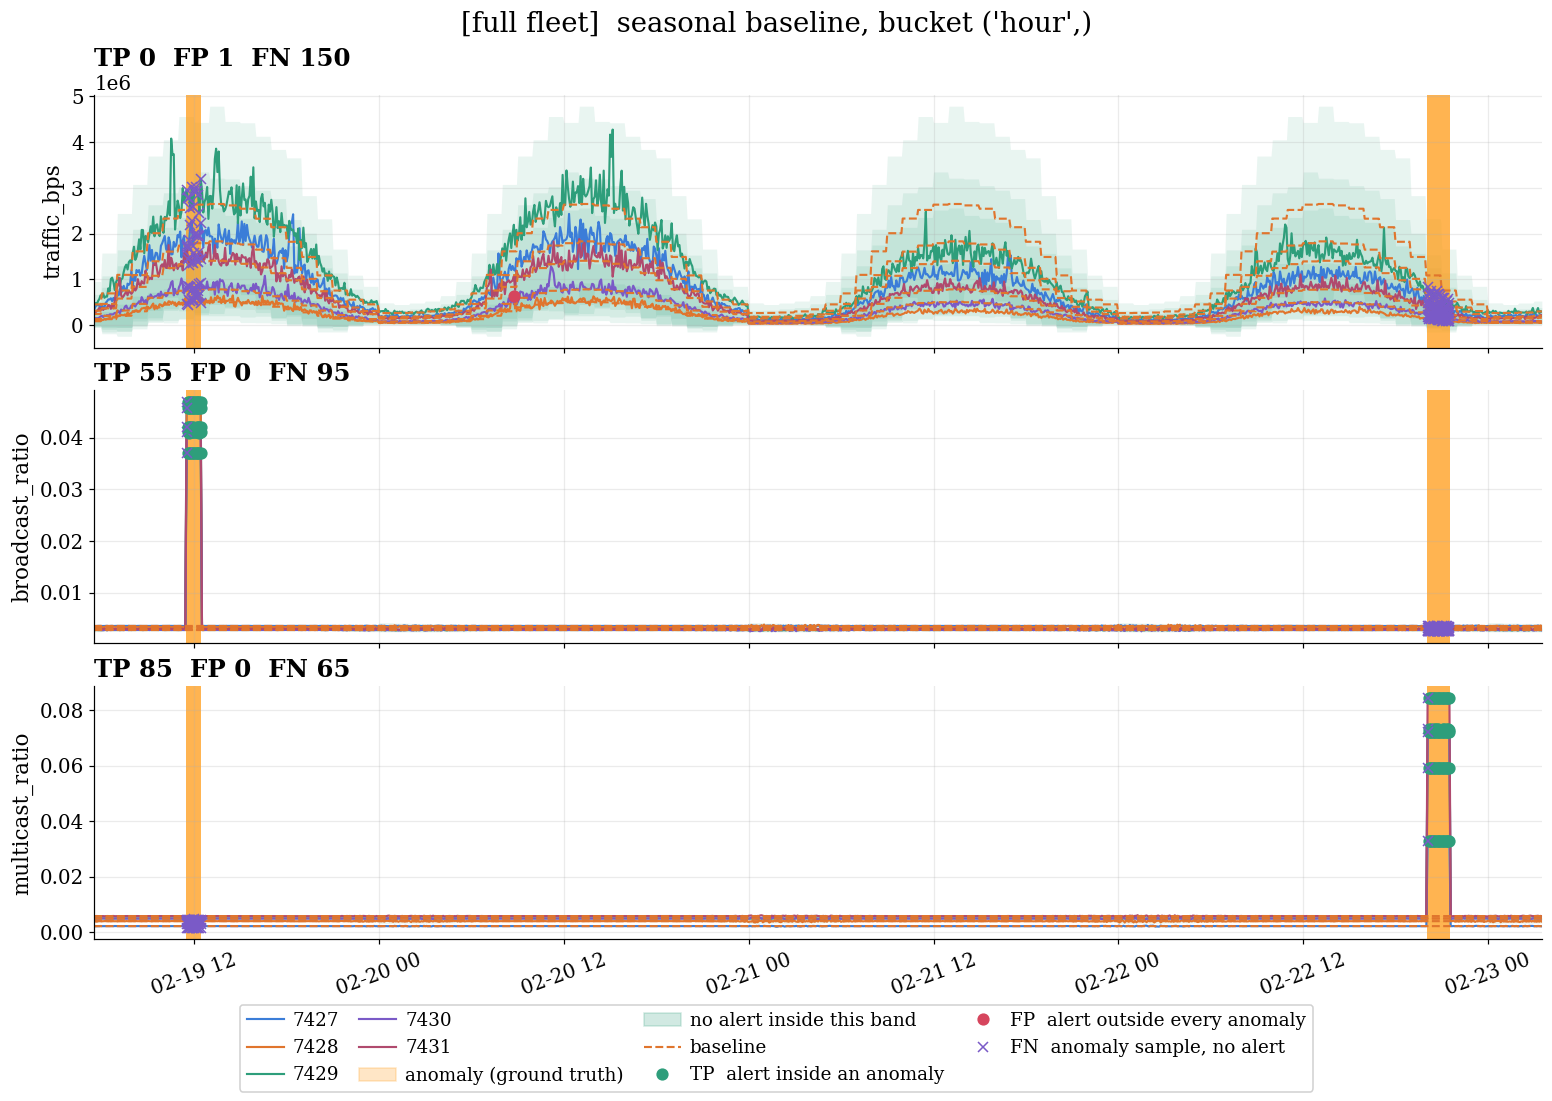

centre drift across broadcast_storm, first sample to last, as a multiple:


baseline              rolling mean  rolling robust  seasonal
column          port                                        
broadcast_ratio 7427          1.00            1.00      1.00
                7428          1.00            1.00      1.00
                7429          0.99            1.00      1.00
                7430          0.99            1.00      1.00
                7431          0.99            1.00      1.00
multicast_ratio 7427          2.71            1.00      1.00
                7428          2.66            1.00      1.00
                7429          2.64            1.00      1.00
                7430          2.64            1.00      1.00
                7431          2.62            1.00      1.00
traffic_bps     7427          1.31            2.59      0.30
                7428          1.33            2.82      0.30
                7429          1.32            2.85      0.30
                7430          1.32            2.77      0.29
                7431          1.28            2.46      0.30

In [25]:
def seasonal_baseline(data, col, ports=None, by=("hour",)):
    """Centre and scale taken from the same seasonal position on other days.

    by=("hour",) compares 10:00 against every other 10:00 on that port. Adding "dayofweek"
    compares Monday 10:00 against other Mondays at 10:00, which needs several weeks of history
    before each cell holds enough samples to be worth anything.
    """
    ports = data["port_id"].unique() if (ports or "all") == "all" else ports
    keys = {"hour": data["timestamp"].dt.hour, "dayofweek": data["timestamp"].dt.dayofweek}
    grp = [data["port_id"]] + [keys[b] for b in by]
    centre = data.groupby(grp, observed=True)[col].transform("median")
    scale = ((data[col] - centre).abs().groupby(grp, observed=True).transform("median") * 1.4826)
    floor = max(0.05 * float(scale.median()), 1e-12)
    scale = scale.fillna(floor).clip(lower=floor)          # return what the score divided by
    score = ((data[col] - centre) / scale).clip(-50, 50)
    return centre, scale, score


s_centre, s_scale, s_score = {}, {}, {}
for col in COLUMNS:
    s_centre[col], s_scale[col], s_score[col] = seasonal_baseline(
        data=df, col=col, ports=PORTS, by=REGIME_BY)
s_bands = {c: (s_centre[c] - THRESHOLD * s_scale[c], s_centre[c] + THRESHOLD * s_scale[c])
           for c in COLUMNS}
s_alerts = {c: confirm(breach=s_score[c] > THRESHOLD, data=df, n=N_CONSEC) for c in COLUMNS}
plot_signals(half=HALF, data=df, columns=[BASELINE_DEMO["column"]],
             ports=[BASELINE_DEMO["port"]], events=[BASELINE_DEMO["event"]],
             baselines=s_centre, bands=s_bands, alerts=s_alerts,
             outcomes=True, by_port=False, zoom_anomaly=True, zoom_signal=False, pad="6h",
             title=f"[demo]  seasonal baseline, bucket {REGIME_BY}")
plot_signals(half=HALF, data=df, columns=COLUMNS, ports=PORTS, events=ZOOM_EVENTS,
             baselines=s_centre, bands=s_bands, alerts=s_alerts,
             outcomes=True, by_port=False, zoom_anomaly=True, zoom_signal=False, pad="6h",
             title=f"[full fleet]  seasonal baseline, bucket {REGIME_BY}")

# The claim worth checking rather than believing: a seasonal reference cannot be dragged by the
# event it is judging, because its comparison samples are on other days. Measure how far each
# centre moves between the first and last sample of one storm.
win = anomaly_windows(df, ZOOM_EVENTS, PORTS)
first, last = win["start"].min(), win["end"].max()
rows = []
for col in COLUMNS:
    centres = {
        "rolling mean": rolling_baseline(data=df, col=col, window=WINDOW, kind="mean",
                                         ports=PORTS, lag=1)[0],
        "rolling robust": rolling_baseline(data=df, col=col, window=WINDOW, kind="robust",
                                           ports=PORTS, lag=1)[0],
        "seasonal": seasonal_baseline(data=df, col=col, ports=PORTS, by=REGIME_BY)[0]}
    for pid in PORTS:
        mask = (df["port_id"] == pid) & df["timestamp"].between(first, last)
        for name, c in centres.items():
            a, b = c[mask].iloc[0], c[mask].iloc[-1]
            rows.append({"column": col, "port": pid[-4:], "baseline": name,
                         "drift_x": round(float(b / a), 2)})
drift = pd.DataFrame(rows).pivot_table(index=["column", "port"], columns="baseline",
                                       values="drift_x")
print(f"centre drift across {ZOOM_EVENTS[0]}, first sample to last, as a multiple:")
drift

#### Your call — the seasonal bucket

**The decision:** which cycle your traffic actually has. Get it wrong and the baseline learns the
wrong shape and reports every legitimate deviation from it — silently, forever.

**The cost is history, and the arithmetic is unforgiving:**

- `by=("hour",)` → 24 buckets per port → thirty samples each from a month.
- `by=("hour", "dayofweek")` → 168 buckets → four samples each. Not enough for a median and a MAD
  you would trust.
- **Every refinement multiplies the buckets and divides the evidence.**

- **Bring your own calendar.** Most networks cycle beyond the day too: month-end batch, quarterly
  close, semester boundary, a maintenance Tuesday. Each is a legitimate deviation a daily bucket
  reports as an anomaly until someone adds it to the key or suppresses it.

**Do it now.** Write the bucket key one service you support would need. Compute how much history
before every cell holds thirty samples. Then say whether you have that much — and whether the
network was the same network that far back.

The drift table is the measurement, and it separates two things that are easy to confuse.

- **On `broadcast_ratio` the rolling mean centre nearly doubles** across the storm — 1.94 to 2.05
  depending on the port — while **both medians sit at 1.00**.
- **On `traffic_bps` every centre drifts,** because the event runs into a rising daily curve: mean
  1.18, robust 1.25 to 1.46, seasonal 1.03 to 1.05. The seasonal one moves least, and it is moving
  with the day rather than with the event.
- **On `multicast_ratio` the mean drifts *down*, to 0.98.** A storm on another column pulls the
  window's mean the other way. Contamination is not always inflation.

**At 8% contamination the robust and seasonal baselines are equally immune,** so this table does not
separate them.

**What separates them is an event longer than the window.**

- A rolling median holds until contamination passes half its window, then goes. Immune up to a
  duration, defenceless past it.
- A seasonal reference has no such threshold: one bad day contributes one of thirty.
- **A three-day outage defeats a rolling window of any length** and leaves a seasonal baseline 27
  clean days.

**What it costs is history and stability.** Weeks before each bucket is worth anything, and it
assumes the rhythm it learned is still the rhythm. A holiday, a maintenance window, a move to four
office days — each shifts the pattern without being an anomaly, and each is reported as one until
the profile is refit. **That is a runbook entry, not a memory.**

### 10c — Peer: the one this notebook cannot finish

- **Leaves the time axis entirely** — compare a port against the other ports at the same instant,
  itself excluded.
- **Uses no history at all** — the only baseline here that works on a port installed this
  morning, and the only one that survives a three-day outage with no clean reference period.
- **Leave-one-out matters for the same reason `lag=1` mattered in Step 9:** a large excursion
  would otherwise pull the very median it's compared against.

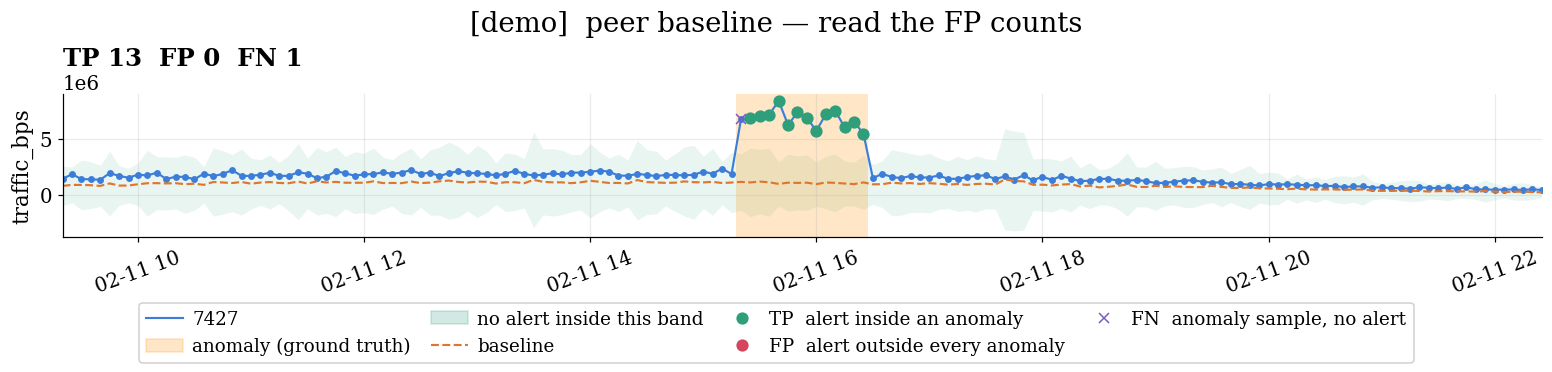

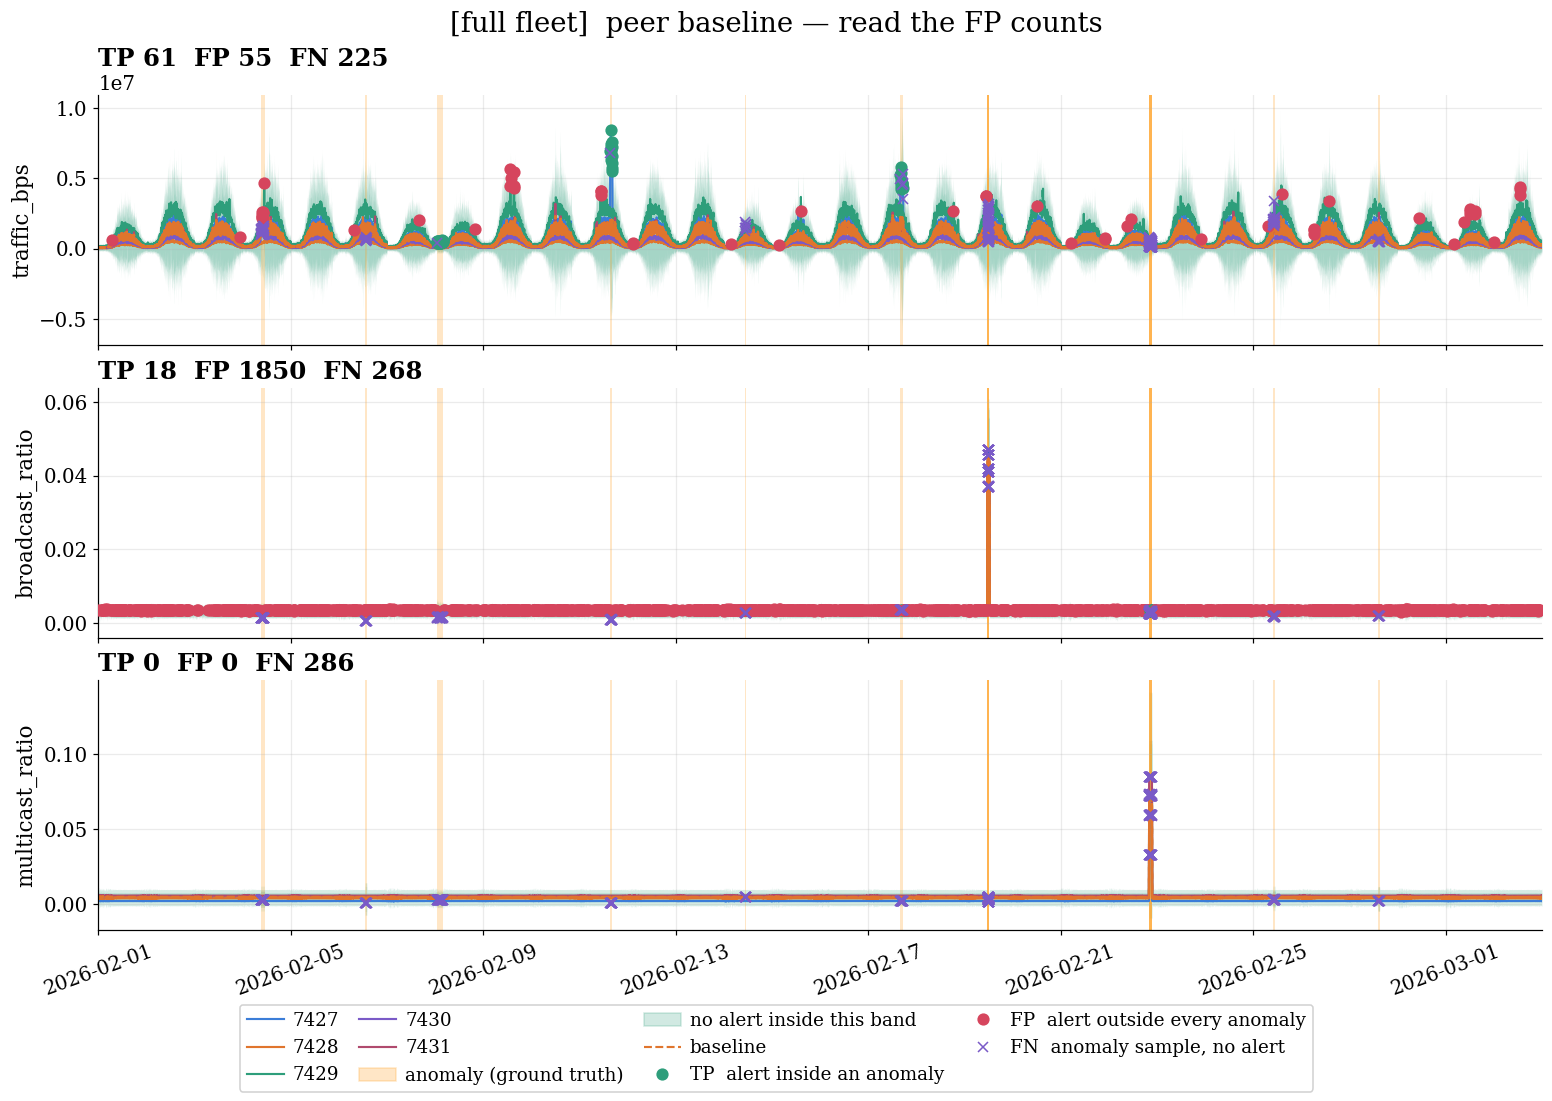

,,traffic_bps,broadcast_ratio,multicast_ratio
port_id,port_role,,,
port-id7427,wan-primary,7.792862e+05,0.003539,0.002112
port-id7428,wan-secondary,2.213888e+05,0.003344,0.003913
port-id7429,server-uplink,1.160818e+06,0.002747,0.004901
port-id7430,office-vlan,3.369744e+05,0.002766,0.004841
port-id7431,backup-storage,6.153706e+05,0.002972,0.005733


traffic_bps: quiet medians span x5.24 across the 5 roles
broadcast_ratio: quiet medians span x1.29 across the 5 roles
multicast_ratio: quiet medians span x2.71 across the 5 roles


In [26]:
def peer_baseline(data=df, col=None, ports=None, min_peers=3):
    """Centre and scale from the other ports at the same timestamp, leaving this port out.

    Leave-one-out matters: including the port under test lets a large excursion pull the very median
    it is being compared against, which is the same self-contamination Step 9a showed in time.

    No history is used at all, so this is the one baseline that works on a port with no past. It
    goes blind when the whole group moves together, which is exactly what a broadcast storm does.
    `min_peers` refuses an estimate built on too few peers rather than returning a confident number.
    """
    col = COLUMNS[0] if col is None else col
    ports = PORTS if ports is None else ports
    ports = sorted(data["port_id"].unique()) if ports == "all" else list(ports)
    wide = data[data["port_id"].isin(ports)].pivot_table(
        index="timestamp", columns="port_id", values=col, aggfunc="first")

    centre = pd.Series(np.nan, index=data.index, dtype=float)
    scale = pd.Series(np.nan, index=data.index, dtype=float)
    for pid in ports:
        peers = wide.drop(columns=[pid])                 # this is the leave-one-out
        ok = peers.notna().sum(axis=1) >= min_peers      # refuse a thin peer group
        c = peers.median(axis=1).where(ok)
        sc = peers.sub(c, axis=0).abs().median(axis=1).where(ok) * 1.4826
        rows = data.index[data["port_id"] == pid]
        t = data.loc[rows, "timestamp"]
        centre.loc[rows] = c.reindex(t).to_numpy()
        scale.loc[rows] = sc.reindex(t).to_numpy()

    floor = max(0.05 * float(np.nanmedian(scale)), 1e-12)
    scale = scale.fillna(floor).clip(lower=floor)          # return what the score divided by
    score = ((data[col] - centre) / scale).clip(-50, 50)
    return centre, scale, score


p_centre, p_scale, p_score = {}, {}, {}
for col in COLUMNS:
    p_centre[col], p_scale[col], p_score[col] = peer_baseline(
        data=df, col=col, ports=PORTS, min_peers=3)
p_bands = {c: (p_centre[c] - THRESHOLD * p_scale[c], p_centre[c] + THRESHOLD * p_scale[c])
           for c in COLUMNS}
p_alerts = {c: confirm(breach=p_score[c] > THRESHOLD, data=df, n=N_CONSEC) for c in COLUMNS}
plot_signals(half=HALF, data=df, columns=[BASELINE_DEMO["column"]],
             ports=[BASELINE_DEMO["port"]], events=[BASELINE_DEMO["event"]],
             baselines=p_centre, bands=p_bands, alerts=p_alerts,
             outcomes=True, by_port=False, zoom_anomaly=True, zoom_signal=False, pad="6h",
             title="[demo]  peer baseline — read the FP counts")
plot_signals(half=HALF, data=df, columns=COLUMNS, ports=PORTS, events=ANOMALY_TYPES,
             baselines=p_centre, bands=p_bands, alerts=p_alerts,
             outcomes=True, by_port=False, zoom_anomaly=False, zoom_signal=False, pad="6h",
             title="[full fleet]  peer baseline — read the FP counts")

# Why it fails here, in one table: what the ports look like when nothing is wrong.
quiet = df[df["event_label"] == "normal"]
spread = quiet.groupby(["port_id", "port_role"])[COLUMNS].median()
display(spread)
for c in COLUMNS:
    v = spread[c]
    print(f"{c}: quiet medians span x{v.max() / v.min():.2f} across the {len(PORTS)} roles")

The figure and the table say the same thing from two directions.

- **Almost continuous alerts on some columns, none at all on others.**
- **Not an estimator defect — a precondition failing.** This baseline needs one thing: that the peers
  are comparable.
- **Five ports, five roles,** and their quiet medians differ by roughly the factor a real anomaly
  would produce:
  - `traffic_bps` spans **5.24×** across the roles, from 2.2e5 on `wan-secondary` to 1.2e6 on
    `server-uplink`.
  - `broadcast_ratio` spans 1.29×, `multicast_ratio` 2.71×.
- **So the peer spread is permanent structural difference between roles.** Where it is large the MAD
  is wide and nothing fires; where it is moderate every port looks permanently anomalous.
- **Note which column is worst.** `traffic_bps`, the one with the widest role spread, is where a
  peer baseline is most obviously comparing a WAN link against a storage port.

**The fix is not a better statistic. It is a better peer group.**

In [27]:
# ---------------------------------------------------------------------------------------
# UNFINISHED ON PURPOSE. A peer group is a set of ports whose normal behaviour is
# interchangeable, and nothing in this dataset can tell you which ports those are. The
# `port_role` column is a label somebody typed; it is a hypothesis about comparability, not a
# measurement of it. Two ports can share a role and never be peers, and two ports with
# different roles can be perfect peers.
#
# Fill this in for a fleet you actually run, then re-run the cell.
PEER_GROUPS = {
    # "campus-edge": ["port-id7427", "port-id7428", "port-id7430", "port-id7431"],
}
# ---------------------------------------------------------------------------------------


def grouped_peer_baseline(data=df, col=None, groups=None, min_peers=3):
    """`peer_baseline` run inside each declared group, and nowhere else.

    A port in no group gets no estimate. Falling back to the whole fleet would be the failure this
    function exists to prevent: it would hand back a confident number built from ports that are not
    peers, which is exactly what the figure above shows going wrong.
    """
    groups = PEER_GROUPS if groups is None else groups
    col = COLUMNS[0] if col is None else col
    centre = pd.Series(np.nan, index=data.index, dtype=float)
    scale = pd.Series(np.nan, index=data.index, dtype=float)
    for name, members in groups.items():
        if len(members) < min_peers + 1:
            print(f"  group {name!r}: {len(members)} ports, needs {min_peers + 1} for "
                  f"leave-one-out at min_peers={min_peers} — skipped")
            continue
        c, s, _ = peer_baseline(data=data, col=col, ports=members, min_peers=min_peers)
        rows = data.index[data["port_id"].isin(members)]
        centre.loc[rows], scale.loc[rows] = c.loc[rows], s.loc[rows]
    score = ((data[col] - centre) / scale).clip(-50, 50)
    return centre, scale, score


g_centre, g_scale, g_score = grouped_peer_baseline(data=df, col=COLUMNS[0],
                                                   groups=PEER_GROUPS, min_peers=3)
covered = sorted(df.loc[g_centre.notna(), "port_id"].unique())
print(f"{len(PEER_GROUPS)} peer group(s) declared")
print(f"{len(covered)} of {len(PORTS)} ports have a peer baseline: {covered or 'none'}")
print(f"this detector scores {int(g_score.notna().sum()):,} of {len(df):,} samples")

0 peer group(s) declared
0 of 5 ports have a peer baseline: none
this detector scores 0 of 43,200 samples


### Your call — cross signal

**This is the part I cannot write for you.**

- Every other decision in this lab was settled by a measurement on data we all have.
- This one needs someone who knows the network: which links carry the same traffic, which switches
  sit behind one aggregation, which ports come from one template, which two circuits are a redundant
  pair.
- **None of that is in the CSV, and no statistic recovers it.**

**So bring yours.** Fill `PEER_GROUPS`, re-run the cell, then test the claim:

1. **How many members in the smallest group?**
   - Leave-one-out at `min_peers=3` needs four. Most real groupings have two.
   - What do you do with a pair?
2. **What would silently stop two peers being peers?**
   - A config change, a customer migration, one link upgraded first.
   - A peer group is a claim with an expiry date and no alarm on it.
3. **Which of your incidents would this have missed?**
   - Peer comparison goes blind when the whole group moves together.
   - Events G and H hit all five ports in the same minute — and so do a broadcast storm, a shared
     upstream failure and a bad config push.

**Peer and seasonal cover each other's blind spot.** Seasonal cannot be contaminated by the event it
tests; peer cannot be contaminated by history, because it uses none.

### 10d — All six on one scorecard

Every baseline in this lab, every configured column, one table, scored the same way.

In [28]:
baselines = {}
for col in COLUMNS:
    baselines["rolling mean", col] = rolling_baseline(
        data=df, col=col, window=WINDOW, kind="mean", ports=PORTS, lag=1)
    baselines["rolling robust", col] = rolling_baseline(
        data=df, col=col, window=WINDOW, kind="robust", ports=PORTS, lag=1)
    baselines["seasonal", col] = seasonal_baseline(
        data=df, col=col, ports=PORTS, by=REGIME_BY)
    baselines["peer", col] = peer_baseline(
        data=df, col=col, ports=PORTS, min_peers=3)

detectors = {f"{kind} {col}": confirm(breach=v[2] > THRESHOLD, data=df, n=N_CONSEC)
             for (kind, col), v in baselines.items()}
detectors |= {f"global z {c}": confirm(breach=df[f"z_{c}"] > THRESHOLD, data=df, n=N_CONSEC)
              for c in COLUMNS}
detectors |= {f"fixed {c}": confirm(breach=fixed_score(data=df, col=c, limit=LIMITS[c]) > 1.0,
                                    data=df, n=N_CONSEC) for c in FIXED_COLS}
report(alerts=detectors, data=df, ports=PORTS, events="all").sort_values(
    ["anomaly_recall", "alerts_per_day"], ascending=[False, True])

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
10,seasonal multicast_ratio,85,1.000,5/18,5.0,0.00
13,global z broadcast_ratio,55,1.000,5/18,5.0,0.00
14,global z multicast_ratio,85,1.000,5/18,5.0,0.00
16,fixed broadcast_ratio,55,1.000,5/18,5.0,0.00
17,fixed multicast_ratio,85,1.000,5/18,5.0,0.00
6,seasonal broadcast_ratio,56,0.982,5/18,5.0,0.03
8,rolling mean multicast_ratio,43,0.930,5/18,5.0,0.10
2,seasonal traffic_bps,100,0.890,5/18,5.0,0.37
9,rolling robust multicast_ratio,97,0.876,5/18,5.0,0.40
4,rolling mean broadcast_ratio,67,0.597,5/18,5.0,0.90


- **`anomaly_recall` is out of the windows on these ports, and no column carries all of them.**
  - A storm lives in `broadcast_ratio`, a congestion event in `traffic_bps`.
  - **Compare within a column, never across.**
- **The ratio columns: almost everything works,** including the fixed line, because those anomalies
  leave a narrow band by a wide margin.
- **`traffic_bps` is where the six separate,** in the order 10a and 10b predicted from the bands:
  - seasonal — 0.890 precision, 5/18 windows
  - rolling mean — 0.354, 4/18
  - rolling robust — 0.082, 2/18, 2.97 stray alerts a day, worst in the table
- **A band wider than the signal is not conservative, it is broken.**

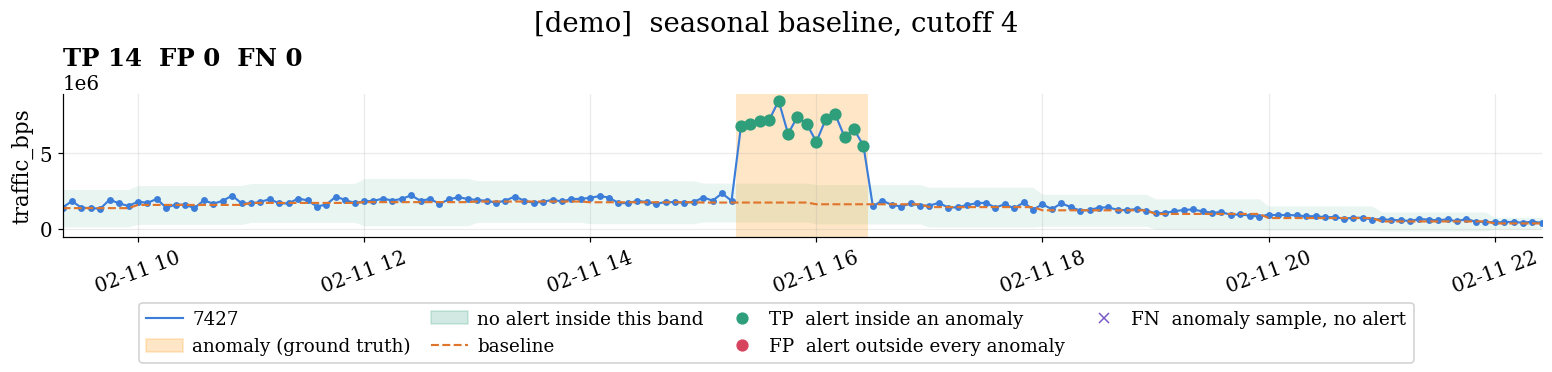

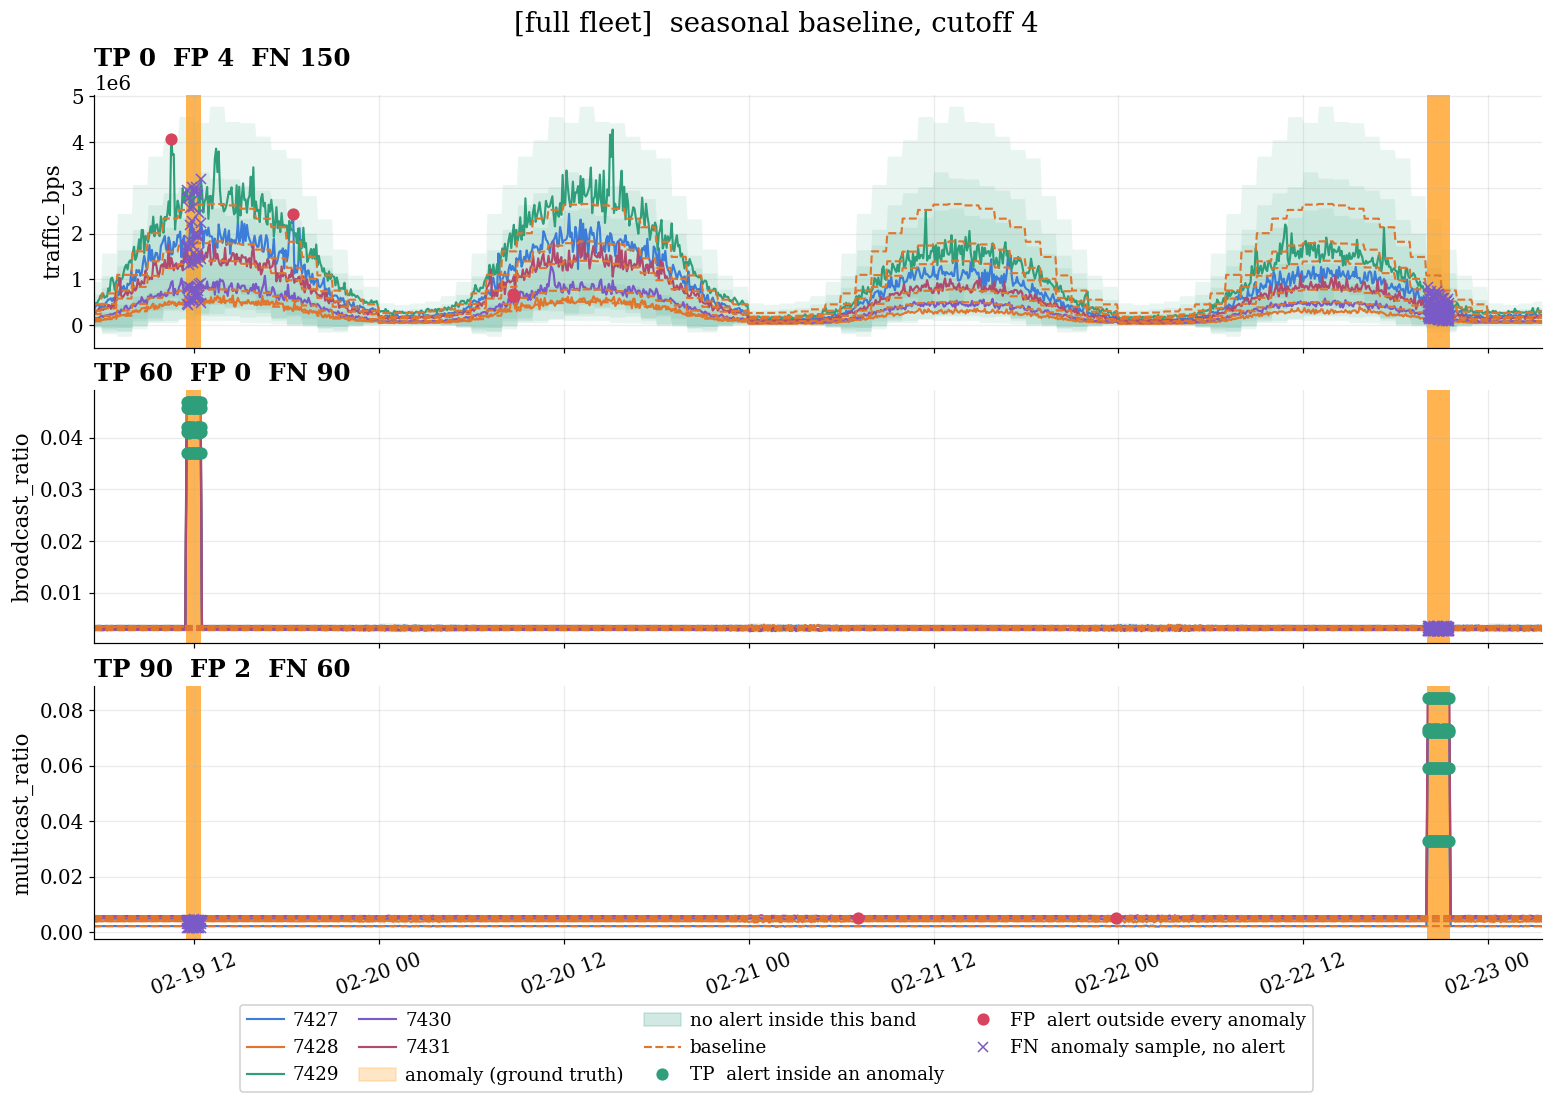

In [29]:
# Edit BASELINE_SHOWN to redraw any of the six across every configured column.
BASELINE_SHOWN = "seasonal"        # "rolling mean" | "rolling robust" | "seasonal" | "peer"

shown_alerts = {c: baselines[BASELINE_SHOWN, c][2] > THRESHOLD for c in COLUMNS}
shown_baselines = {c: baselines[BASELINE_SHOWN, c][0] for c in COLUMNS}
# One band per port, so the shading here is the union of five acceptance regions.
# Set by_port=False to separate them.
shown_bands = {c: (baselines[BASELINE_SHOWN, c][0] - THRESHOLD * baselines[BASELINE_SHOWN, c][1],
                   baselines[BASELINE_SHOWN, c][0] + THRESHOLD * baselines[BASELINE_SHOWN, c][1])
               for c in COLUMNS}
plot_signals(half=HALF, data=df, columns=[BASELINE_DEMO["column"]],
             ports=[BASELINE_DEMO["port"]], events=[BASELINE_DEMO["event"]],
             alerts=shown_alerts, baselines=shown_baselines, bands=shown_bands,
             outcomes=True, by_port=False, zoom_anomaly=True, zoom_signal=False, pad="6h",
             title=f"[demo]  {BASELINE_SHOWN} baseline, cutoff {THRESHOLD:g}")
plot_signals(half=HALF, data=df, columns=COLUMNS, ports=PORTS, events=ZOOM_EVENTS,
             alerts=shown_alerts, baselines=shown_baselines, bands=shown_bands,
             outcomes=True, by_port=False, zoom_anomaly=True, zoom_signal=False, pad="6h",
             title=f"[full fleet]  {BASELINE_SHOWN} baseline, cutoff {THRESHOLD:g}")

#### Your call — `N_CONSEC`

**The decision:** how much persistence you require before a breach becomes a label. The cheapest
precision you can buy, and the only one whose price is fixed in advance.

- **The price is exact.** Delay is `(N − 1) × cadence`.
  - At 5 minutes, every step of N costs five minutes of time-to-page.
  - On every incident, forever. No simulation needed.
- **There is a hard ceiling.**
  - Set N at or above the shortest incident you care about and it becomes undetectable.
  - The shortest labelled event here is 8 samples, so N = 8 makes it impossible.
  - No threshold rescues it.
- **One detector should skip this layer entirely.**
  - Confirmation gives a *memoryless* score persistence.
  - It is redundant on a statistic that already carries state — Lab 02's CUSUM runs at `n = 1`.

**Do it now.** Set `N_CONSEC = 1`, then `4`. Read the delay column, multiply by your cadence, and ask
whether the precision at N = 4 is worth fifteen extra minutes on a customer-visible outage.

## Step 11 — Score, label and alert are three different things

| layer | what it is | decided by |
|---|---|---|
| **anomaly score** | a continuous distance from baseline | the method |
| **anomaly label** | score above a cutoff, per sample | the threshold, versioned |
| **alert** | a label that survived persistence, severity, suppression and routing | operations |

Keeping the score continuous is what lets you re-tune later without re-running anything. Going
straight from score to notification throws that away.

Two rules turn labels into alerts here: **persistence**, `N_CONSEC` breaches in a row, and
**maintenance exclusion**, where the change calendar suppresses declared windows.

In [30]:
calendar = pd.read_csv(DATA / "change_calendar.csv", parse_dates=["start_time", "end_time"])
display(calendar[["change_id", "change_type", "scope", "start_time", "end_time", "owner"]])


def in_maintenance(data=None, cal=None):
    """True on samples covered by a declared change window, matched on port or device."""
    data = df if data is None else data
    cal = calendar if cal is None else cal
    m = pd.Series(False, index=data.index)
    for c in cal.itertuples():
        scope = (data["port_id"] == c.scope) | (data["device_id"] == c.scope)
        m |= scope & data["timestamp"].between(c.start_time, c.end_time)
    return m


MAINT = in_maintenance(data=df, cal=calendar)
print(f"{MAINT.sum():,} of {len(df):,} samples sit inside a declared change window")

,change_id,change_type,scope,start_time,end_time,owner
0,CH-01,scheduled_backup,port-id7431,2026-02-08 00:50:00,2026-02-08 04:10:00,infra-ops
1,CH-02,business_change,port-id7430,2026-02-04 08:50:00,2026-02-04 11:05:00,app-team
2,CH-03,maintenance,core-sw-01,2026-02-16 02:00:00,2026-02-16 04:00:00,network-ops
3,CH-04,maintenance,edge-fw-01,2026-02-21 03:00:00,2026-02-21 05:00:00,security-ops


169 of 43,200 samples sit inside a declared change window


In [31]:
# port-id7431 alone, because CH-01 covers a real anomaly there and the whole point of this step
# is watching the calendar remove correct alerts. Every configured column goes through all three
# layers, so the effect shows on more than one signal.
demo_port = ["port-id7431"]
layers = {}
for col in COLUMNS:
    score = seasonal_baseline(data=df, col=col, ports=demo_port, by=("hour",))[2]
    label = confirm(breach=score > THRESHOLD, data=df, n=N_CONSEC)
    layers[f"{col} | 1 breach"] = (score > THRESHOLD).fillna(False)
    layers[f"{col} | 2 label ({N_CONSEC} in a row)"] = label
    layers[f"{col} | 3 alert (maintenance excluded)"] = label & ~MAINT
report(alerts=layers, data=df, ports=demo_port, events="all")

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,traffic_bps | 1 breach,50,0.720,1/3,0.0,0.47
1,traffic_bps | 2 label (2 in a row),39,0.897,1/3,5.0,0.13
2,traffic_bps | 3 alert (maintenance excluded),4,0.000,0/3,NaN,0.13
3,broadcast_ratio | 1 breach,14,0.857,1/3,0.0,0.07
4,broadcast_ratio | 2 label (2 in a row),11,1.000,1/3,5.0,0.00
5,broadcast_ratio | 3 alert (maintenance excluded),11,1.000,1/3,5.0,0.00
6,multicast_ratio | 1 breach,21,0.857,1/3,0.0,0.10
7,multicast_ratio | 2 label (2 in a row),17,1.000,1/3,5.0,0.00
8,multicast_ratio | 3 alert (maintenance excluded),17,1.000,1/3,5.0,0.00


Both rules do visible work.

- **Persistence: 50 breaches → 39 labels, precision 0.72 → 0.90.**
  - Removes single-sample noise without touching the threshold.
  - Costs one sample of delay, which `delay_min` prices.
  - Where the first sample matters, `N_CONSEC = 1` with a higher cutoff may pair better.
- **Maintenance exclusion bites on exactly one column.**
  - `traffic_bps` goes 39 labels → 4 alerts.
  - 35 of them were the Sunday-night backup CH-01.
  - The seasonal baseline flagged it *correctly* — 3 a.m. traffic at that level really is unlike
    other nights.
- **Its anomaly recall drops to 0/3, and that is the right answer.** The only anomaly it found was
  one nobody should be woken for.
- **The ratio columns are untouched.** The storm and the flooding did not fall inside a declared
  window.

**Nothing in the telemetry separates a planned backup from an unplanned transfer.** That distinction
lives only in the calendar, which is why this layer cannot be learned from the metric.

## Step 12 — The threshold is an operations decision

- **Lower it: catches more, pages more. Raise it: the reverse.**
- **The real tradeoff — a missed incident's cost against a false alarm's — isn't in the data.**
- **Four questions decide it, all about the team, not the metric:** daily alert capacity, cost of
  a miss, who's available to act, how much roster is already spent on alerts.

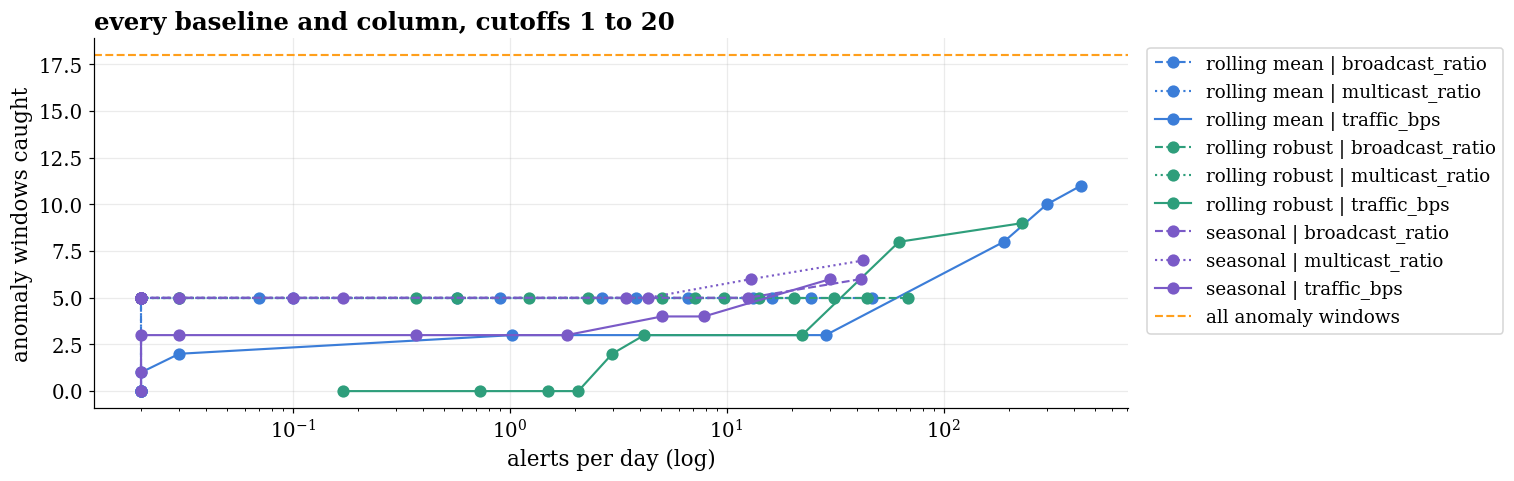

alerts_per_day                                                                                                                              caught                              \
baseline     rolling mean                              rolling robust                                    seasonal                                rolling mean                               
column    broadcast_ratio multicast_ratio traffic_bps broadcast_ratio multicast_ratio traffic_bps broadcast_ratio multicast_ratio traffic_bps broadcast_ratio multicast_ratio traffic_bps   
threshold                                                                                                                                                                                   
1.0                 46.97           16.20      428.22           68.71           20.40      229.99           41.47           42.70       29.97             5.0             5.0        11.0   
1.5                 24.60            6.60      298.40           44.37            9.70       62.27           12.53           12.93        7.87             5.0             5.0        10.0   
2.0                 13.17            2.67      189.36           31.17            5.03       22.24            3.43            4.33        5.03             5.0             5.0         8.0   
3.0                  3.83            0.57       28.60           14.13            1.23        4.17            0.17            0.10        1.83             5.0             5.0         3.0   
4.0                  0.90            0.10        1.03            7.17            0.37        2.97            0.03            0.00        0.37             5.0             5.0         3.0   
6.0                  0.07            0.00        0.03            2.30            0.03        2.07            0.00            0.00        0.03             5.0             5.0         2.0   
8.0                  0.00            0.00        0.00            0.57            0.00        1.50            0.00            0.00        0.00             5.0             5.0         1.0   
12.0                 0.00            0.00        0.00            0.03            0.00        0.73            0.00            0.00        0.00             0.0             0.0         0.0   
20.0                 0.00            0.00        0.00            0.00            0.00        0.17            0.00            0.00        0.00             0.0             0.0         0.0   

                                                                                                   
baseline   rolling robust                                    seasonal                              
column    broadcast_ratio multicast_ratio traffic_bps broadcast_ratio multicast_ratio traffic_bps  
threshold                                                                                          
1.0                   5.0             5.0         9.0             6.0             7.0         6.0  
1.5                   5.0             5.0         8.0             5.0             6.0         4.0  
2.0                   5.0             5.0         3.0             5.0             5.0         4.0  
3.0                   5.0             5.0         3.0             5.0             5.0         3.0  
4.0                   5.0             5.0         2.0             5.0             5.0         3.0  
6.0                   5.0             5.0         0.0             5.0             5.0         3.0  
8.0                   5.0             5.0         0.0             5.0             5.0         3.0  
12.0                  5.0             5.0         0.0             5.0             5.0         1.0  
20.0                  5.0             5.0         0.0             5.0             5.0         0.0

In [32]:
GRID = [1, 1.5, 2, 3, 4, 6, 8, 12, 20]

rows = []
for kind in ("rolling mean", "rolling robust", "seasonal"):
    for col in COLUMNS:
        score = baselines[kind, col][2]
        for t in GRID:
            r = report(alerts={"x": confirm(breach=score > t, data=df, n=N_CONSEC) & ~MAINT},
                       data=df, ports=PORTS, events="all").iloc[0]
            caught, total = r["anomaly_recall"].split("/")
            rows.append({"baseline": kind, "column": col, "threshold": t,
                         "alerts": r["alerts"], "caught": int(caught), "of": int(total),
                         "alerts_per_day": r["alerts_per_day"], "delay_min": r["delay_min"]})
grid = pd.DataFrame(rows)

kinds = ["rolling mean", "rolling robust", "seasonal"]
fig, ax = plt.subplots()
for (kind, col), d in grid.groupby(["baseline", "column"]):
    ax.plot(d["alerts_per_day"].clip(lower=0.02), d["caught"], marker="o",
            color=BASELINE_C[kinds.index(kind)], ls=COLUMN_LS[COLUMNS.index(col)],
            label=f"{kind} | {col}")
ax.axhline(grid["of"].max(), color=C["truth"], ls="--", label="all anomaly windows")
ax.set(xscale="log", xlabel="alerts per day (log)", ylabel="anomaly windows caught",
       title=f"every baseline and column, cutoffs {GRID[0]:g} to {GRID[-1]:g}")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.show()

grid.pivot_table(index="threshold", columns=["baseline", "column"],
                 values=["caught", "alerts_per_day"])

Each curve is one baseline on one column across nine cutoffs; up-and-left is better. Colour is the
baseline, dash pattern the column.

- **Some curves are flat, and loosening them buys nothing.**
  - `rolling mean | broadcast_ratio` holds exactly 5 of 18 windows at every cutoff from 8 to 1.
  - Its alert rate climbs 0.00 → **46.97 a day** over that range.
  - Forty-seven alerts bought zero windows.
  - **A flat curve says the cutoff is not the parameter to tune.**
- **Steep curves cross the flat ones.**
  - `traffic_bps` catches 1 window at cutoff 8, 3 at 3, 8 at 2, 11 at 1.
  - Priced at 0.00, 28.60, 189.36, 428.22 alerts a day.
  - The last three windows cost more than the previous eight.
  - **"Which baseline is best" has no answer until the alert budget is fixed.**
- **No curve reaches 18.**
  - No single column carries every anomaly type.
  - The ceiling is set by the signal, not the threshold.
  - **That is the argument for scoring several signals rather than tuning one.**

**Accuracy is absent on purpose.** With 226 anomaly samples in 43,200, a detector that alerts on
nothing scores over 99%.

### 12a — One point on the curve, drawn as alerts

The plane above trades windows caught against alerts per day. Here is one point on it, at a
tighter cutoff than the lab's default, drawn as the detector it actually is.

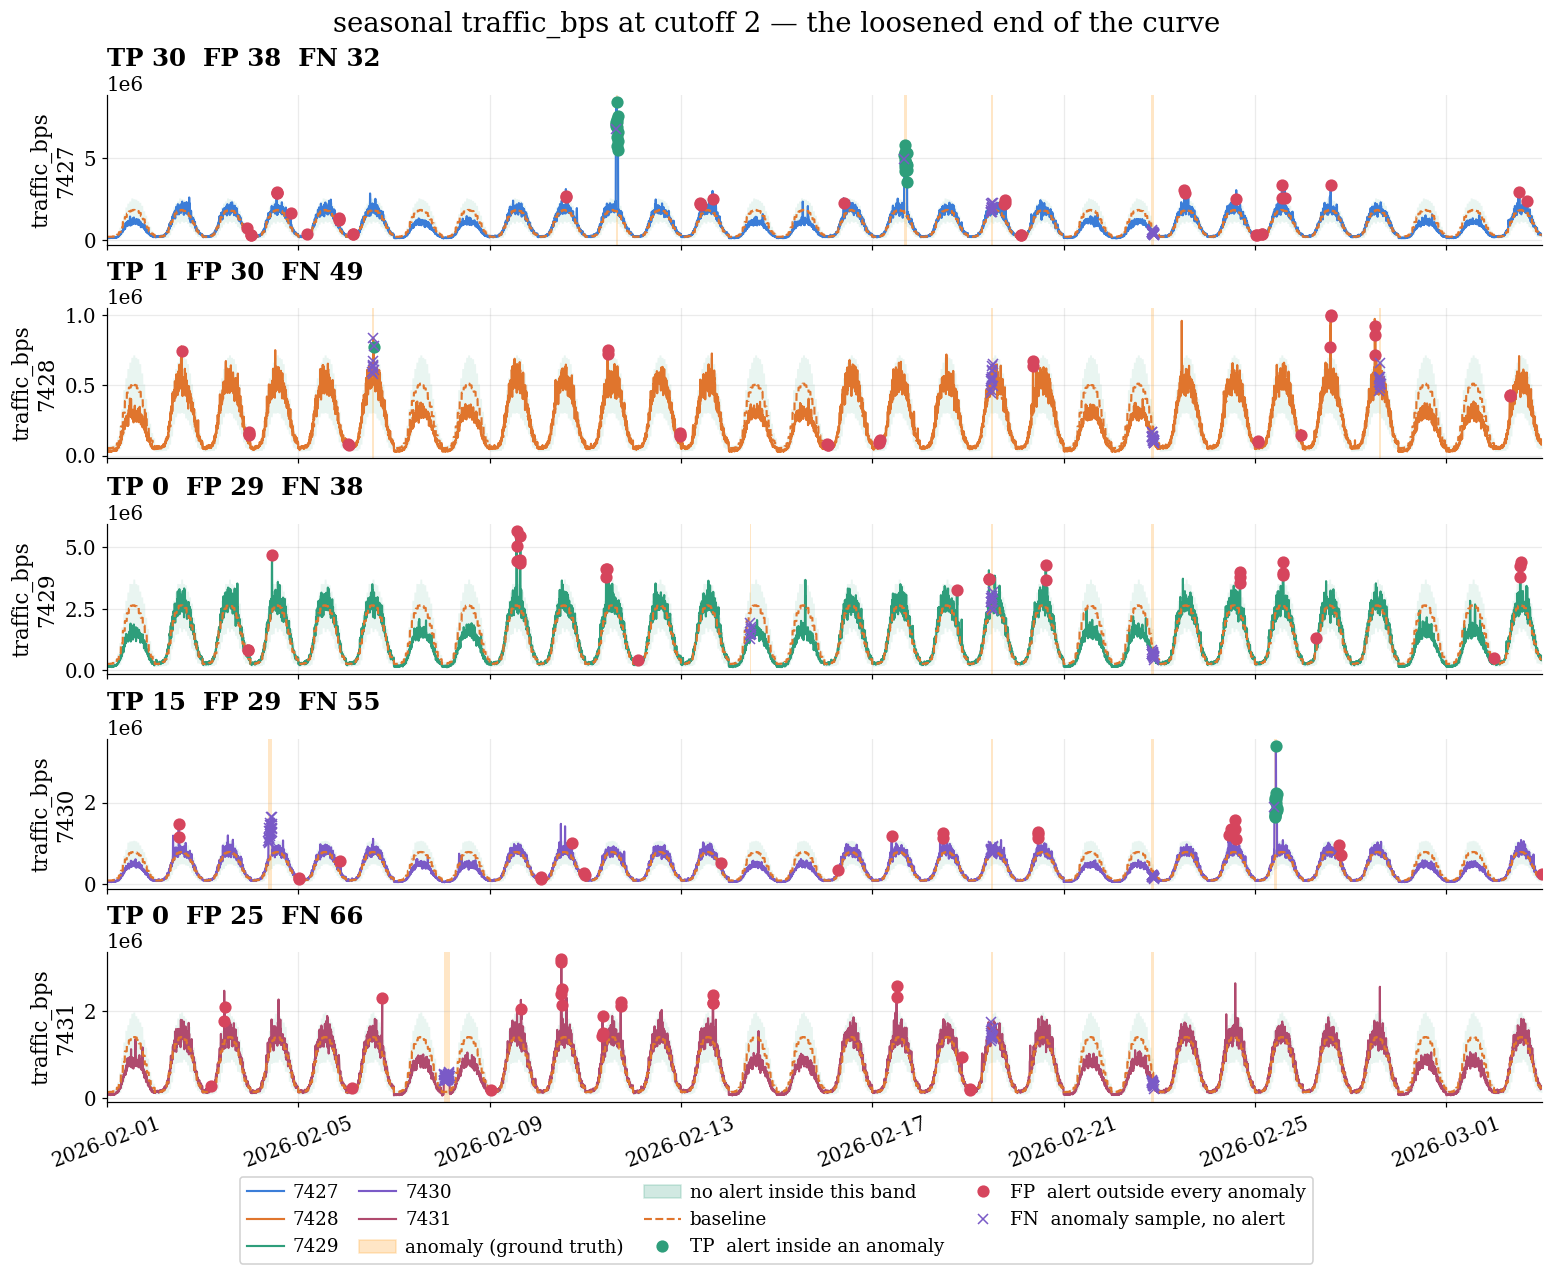

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,seasonal traffic_bps > 2,197,0.234,4/18,5.0,5.03


In [33]:
demo_col, demo_thr = "traffic_bps", 2.0
d_centre, d_scale, d_score = baselines["seasonal", demo_col]
d_alerts = confirm(breach=d_score > demo_thr, data=df, n=N_CONSEC) & ~MAINT
plot_signals(half=HALF, data=df, columns=[demo_col], ports=PORTS, events=ANOMALY_TYPES,
             baselines={demo_col: d_centre},
             bands={demo_col: (d_centre - demo_thr * d_scale, d_centre + demo_thr * d_scale)},
             alerts={demo_col: d_alerts}, outcomes=True, by_port=True,
             zoom_anomaly=False, zoom_signal=False, pad="6h",
             title=f"seasonal {demo_col} at cutoff {demo_thr:g} — the loosened end of the curve")
report(alerts={f"seasonal {demo_col} > {demo_thr:g}": d_alerts}, data=df, ports=PORTS, events="all")

## Step 13 — What follows

- **From here, the output is something Lab 02 consumes, not something this lab scores.** This lab
  picks what gets scored and in what representation; Lab 02 picks which detector scores it.
- **Three representations, one hyperparameter each** — the `WINDOW` lesson, two more times.

| Step | Representation | Its one hyperparameter |
|---|---|---|
| 14 | scaled values, fitted on the training half only | `TRAIN_FRAC` |
| 15 | the residual after the expected shape of a day is subtracted | `PERIOD` |
| 16 | sliding windows, one row per recent stretch | `N_INPUT` |

- **All three run on every port and column** — worth reading because the three columns need
  different answers, and a representation right for one is wrong on the others (Step 10b: only
  `traffic_bps` has a daily cycle to subtract).

## Step 14 — Split and scale without leaking

- **The split point is an index, not a random sample.** Before it trains, after it tests, and the
  scaler fits on the training part alone.
  - Fitting on the whole month lets the events being scored set their own judging scale —
    flattering every result that follows.
- **The two fitted numbers per (port, column) go into the spec,** so Lab 02 loads and never
  refits them — the guarantee holds across the notebook boundary, not just inside it.

In [34]:
def train_split(g, train_frac=None):
    """Index of the first test sample. Time order, never a shuffle."""
    train_frac = TRAIN_FRAC if train_frac is None else train_frac
    return int(train_frac * len(g))


def fit_scaler(values, split):
    """(mean, scale) from the training part alone, as plain floats the spec can carry."""
    sc = StandardScaler().fit(np.asarray(values, dtype=float)[:split].reshape(-1, 1))
    return float(sc.mean_[0]), float(sc.scale_[0])


SCALERS, rows = {}, []
df["is_train"] = False
for pid in PORTS:
    g = df[df["port_id"] == pid].sort_values("timestamp")
    k = train_split(g, train_frac=TRAIN_FRAC)
    df.loc[g.index[:k], "is_train"] = True
    for col in SCORABLE:
        SCALERS[f"{pid}|{col}"] = fit_scaler(g[col], split=k)
    leak_mean, leak_scale = fit_scaler(g[COLUMNS[0]], split=len(g))
    train_mean, train_scale = SCALERS[f"{pid}|{COLUMNS[0]}"]
    rows.append({"port": pid[-4:], "split_at": g["timestamp"].iloc[k],
                 "train": k, "test": len(g) - k,
                 "anomaly_train": int((g["event_label"] != "normal").to_numpy()[:k].sum()),
                 "anomaly_test": int((g["event_label"] != "normal").to_numpy()[k:].sum()),
                 "scale_train_only": round(train_scale, 1),
                 "scale_whole_month": round(leak_scale, 1),
                 "leak_pct": round(100 * (leak_scale / train_scale - 1), 2)})

split_table = pd.DataFrame(rows)
display(split_table)
print(f"{len(SCALERS)} scalers fitted: {len(PORTS)} ports x {len(SCORABLE)} scorable columns")

,port,split_at,train,test,anomaly_train,anomaly_test,scale_train_only,scale_whole_month,leak_pct
0,7427,2026-02-22,6048,2592,44,18,732026.1,707722.4,-3.32
1,7428,2026-02-22,6048,2592,22,28,179454.7,179304.0,-0.08
2,7429,2026-02-22,6048,2592,20,18,942346.1,936709.0,-0.60
3,7430,2026-02-22,6048,2592,36,34,282278.7,289152.4,2.44
4,7431,2026-02-22,6048,2592,48,18,500837.7,497417.3,-0.68


35 scalers fitted: 5 ports x 7 scorable columns


Same split, seen against the incidents rather than the counts.

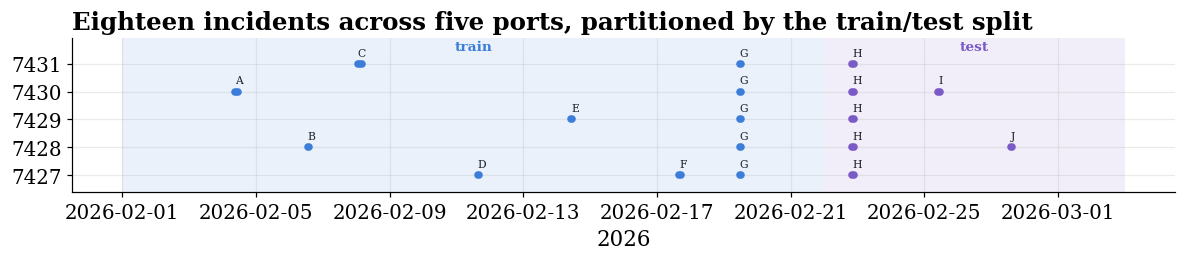

In [35]:
win = anomaly_windows(data=df, events="all", ports=PORTS)
win = win.merge(df[["port_id", "timestamp", "is_train"]],
                left_on=["port_id", "start"], right_on=["port_id", "timestamp"])
win["split"] = np.where(win["is_train"], "train", "test")

SPLIT_AT = split_table["split_at"].iloc[0]           # identical across ports on this data
SPLIT_C = {"train": PORT_C[0], "test": PORT_C[3]}

fig, ax = plt.subplots(figsize=(11, 2.6))
for name, lo, hi in [("train", df["timestamp"].min(), SPLIT_AT),
                     ("test", SPLIT_AT, df["timestamp"].max())]:
    ax.axvspan(lo, hi, color=SPLIT_C[name], alpha=0.10, lw=0)
    ax.text(lo + (hi - lo) / 2, len(PORTS) - 0.4, name, ha="center", va="center",
            color=SPLIT_C[name], weight="600", fontsize=9)
for t in win.itertuples():
    y = PORTS.index(t.port_id)
    ax.plot([t.start, t.end], [y, y], color=SPLIT_C[t.split], lw=5, solid_capstyle="round")
    ax.annotate(t.event_id, xy=(t.start, y + 0.28), fontsize=7, color="#1B1F24")
ax.set_yticks(range(len(PORTS)), [p[-4:] for p in PORTS])
ax.set_ylim(-0.6, len(PORTS) - 0.1)
ax.set_xlabel("2026")
ax.set_title("Eighteen incidents across five ports, partitioned by the train/test split", loc="left")
plt.show()

**11 incidents train, 7 test** — `G` and `H` each hit all five ports in the same minute, so one
calendar moment produces five rows in `win` and counts five times here.

#### Your call — `TRAIN_FRAC`

**The decision:** where "unseen" starts. This is the difference between a number describing your
data and a number describing what your detector will do next month.

- **Everything before the point trains, everything after is unseen,** and the scaler sees only the
  first part.
- **Incidents sit where the calendar put them.** A split giving a decent training period may leave
  two incidents to be scored on, and recall computed on two incidents has an interval wide enough to
  be useless.
- **Networks change.** Train far enough back and the training period is a different system from the
  one you are scoring.

**Do it now.** Set `TRAIN_FRAC = 0.5`, then `0.9`, and watch `anomaly_train` and `anomaly_test`
rather than any score. At which split does the test side stop holding enough incidents to mean
anything — and does that leave enough training history to be worth fitting? On most real fleets
those two requirements do not both fit in the data you kept.

Two things in that table are worth stopping on.

- **The anomaly samples do not split evenly, and no care makes them.** One port can have its entire
  event in training and another most of its samples in test. Naming that is better than engineering
  it away — engineering it away means choosing the split by looking at the labels, which is the leak
  this step prevents.
- **`leak_pct` prices the shortcut:** how far the fitted scale moves when the scaler sees the whole
  month instead of the training part. On this data, a few percent **in both directions**.
  - A leak that widens the scale deflates every later score and hides events.
  - One that narrows it inflates them and manufactures false alarms.
  - **Nothing in the resulting score tells you which happened.** A few percent is small enough to be
    invisible and large enough to invalidate the claim that the test period was unseen.

No label ever reaches `fit` downstream. Training on a period containing an event means the model saw
a little contamination, which is the realistic case.

## Step 15 — Remove the seasonality

Step 10 measured the daily shape; this step subtracts it. Decompose additively:

$$x_t = \mathrm{trend}_t + \mathrm{season}_t + \mathrm{resid}_t$$

- **Trend** — a centred rolling mean over one full cycle, averaging the cycle away.
- **Season** — the typical day-shape, taken as the **median** of detrended values per cycle
  position, so one anomalous day can't redraw the profile.
- **Residual** — what's left, and the column Lab 02 scores.

70 scalers now: 5 ports x 7 columns, raw and residual


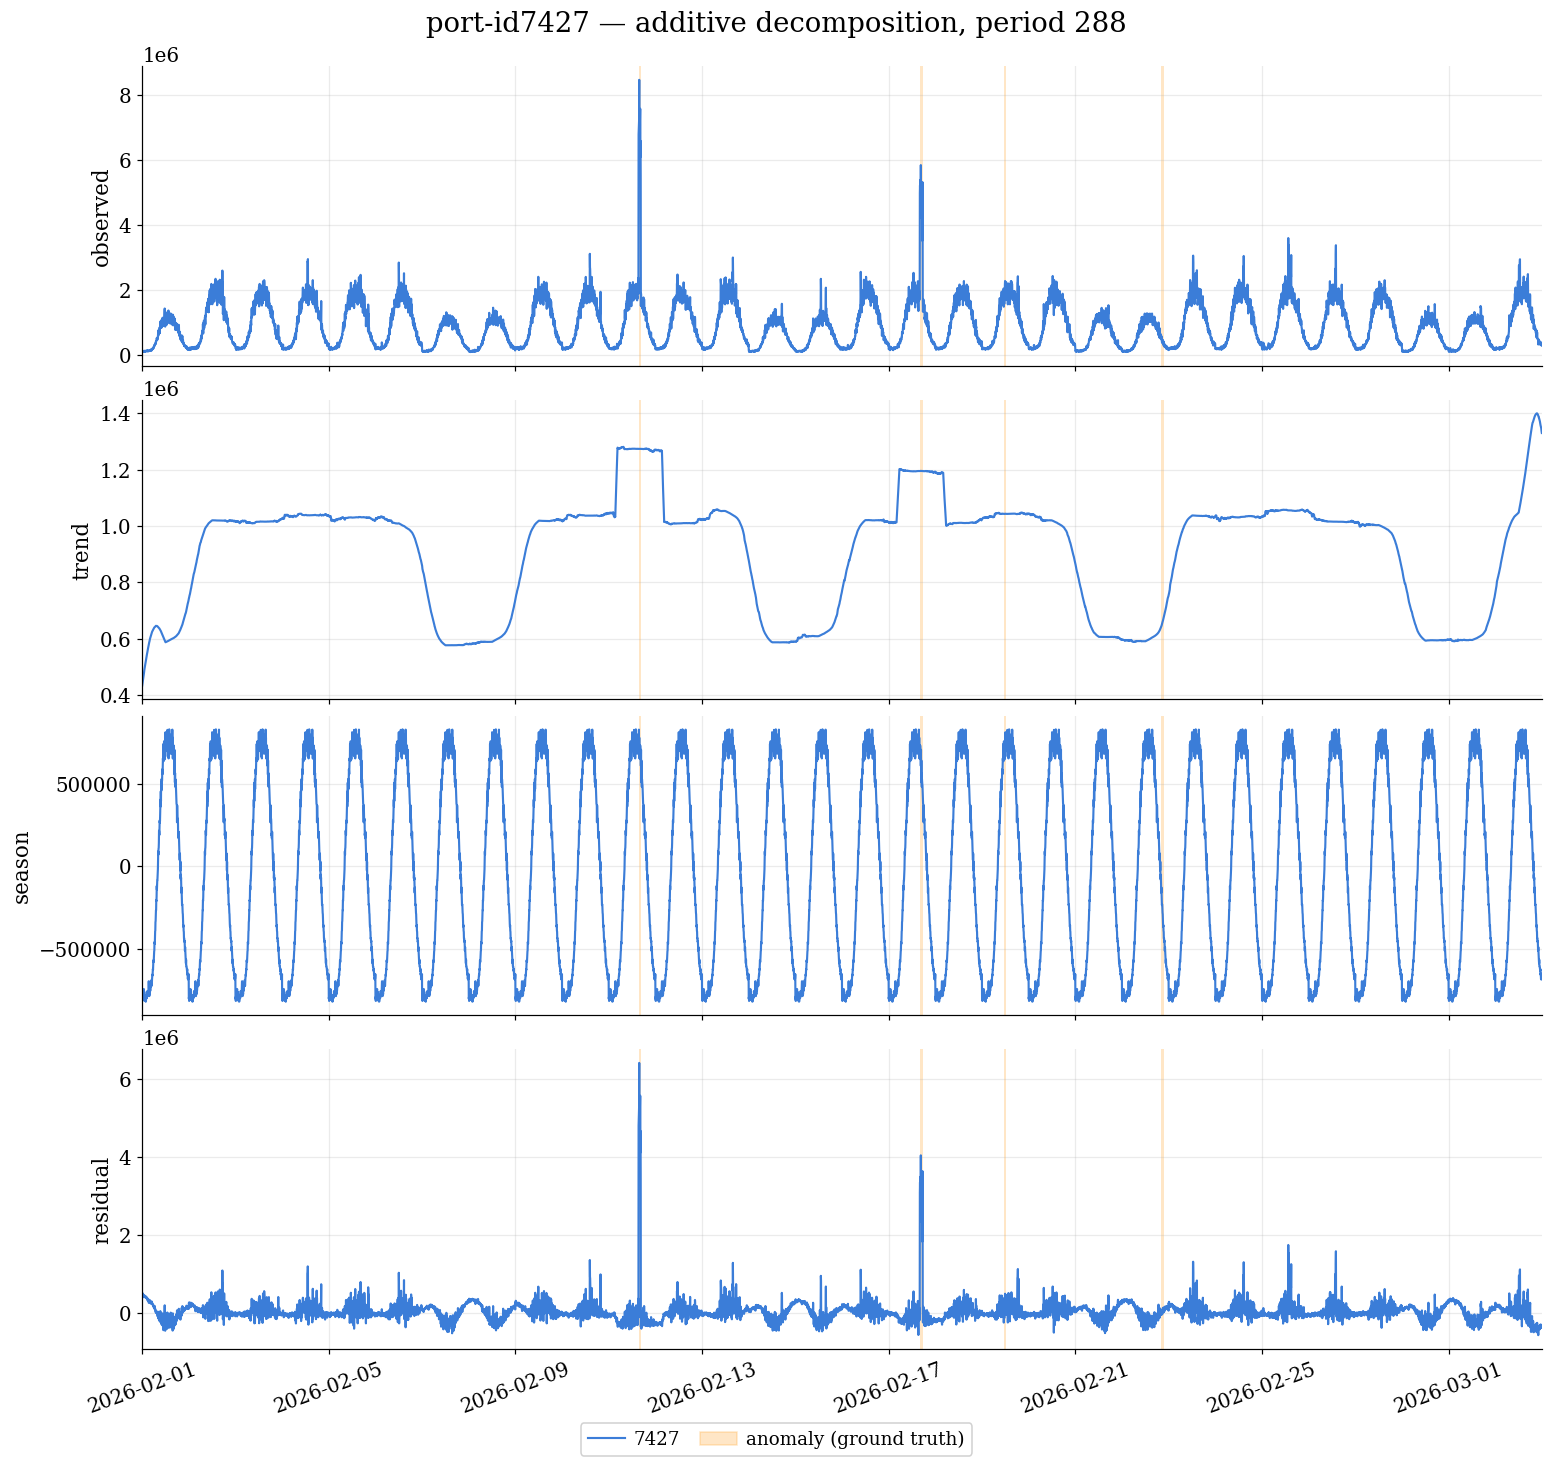

In [36]:
def decompose(x, period=None):
    """Additive trend / season / residual. A median seasonal profile resists contamination."""
    period = PERIOD if period is None else period
    s = pd.Series(np.asarray(x, dtype=float))
    trend = s.rolling(period, center=True, min_periods=period // 2).mean()
    detrended = s - trend
    season = detrended.groupby(np.arange(len(s)) % period).transform("median")
    return trend.to_numpy(), season.to_numpy(), (s - trend - season).to_numpy()


# The residual of every scorable column on every port, written into df so it ships to Lab 02.
for col in SCORABLE:
    resid_col = np.full(len(df), np.nan)
    for pid in PORTS:
        idx = df.index[df["port_id"] == pid]
        resid_col[df.index.get_indexer(idx)] = decompose(df.loc[idx, col], period=PERIOD)[2]
    df[f"resid_{col}"] = resid_col

# One rule, applied without exception: a column this lab ships carries the scaler Lab 02 must use.
# A residual is a column, so it gets one, fitted on the same training rows and nothing else.
for pid in PORTS:
    g = df[df["port_id"] == pid].sort_values("timestamp")
    k = train_split(g, train_frac=TRAIN_FRAC)
    for col in SCORABLE:
        SCALERS[f"{pid}|resid_{col}"] = fit_scaler(g[f"resid_{col}"].fillna(0.0), split=k)
print(f"{len(SCALERS)} scalers now: {len(PORTS)} ports x {len(SCORABLE)} columns, raw and residual")

port, col = PORTS[0], COLUMNS[0]
g = series_of(port, col=col, data=df, events=ANOMALY_TYPES)
trend, season, resid = decompose(g["value"], period=PERIOD)

# Four views of one signal are four columns, so one `plot_signals` call draws all four panels and
# shades every anomaly window on this port separately. Drawing one span from the first anomaly
# sample to the last would cover the eleven days between them.
PARTS = ["observed", "trend", "season", "residual"]
parts = df.assign(**{p: np.nan for p in PARTS})
rows = df.index[df["port_id"] == port]          # df is sorted by (port_id, timestamp)
for name, v in zip(PARTS, [g["value"].to_numpy(), trend, season, resid]):
    parts.loc[rows, name] = v

plot_signals(half=HALF, data=parts, columns=PARTS, ports=[port], events=ANOMALY_TYPES,
             alerts=None, baselines=None, bands=None, outcomes=False, by_port=False,
             zoom_anomaly=False, zoom_signal=False,
             title=f"{port} — additive decomposition, period {PERIOD}")

At full-month scale the shaded sliver is too narrow to read. Zoom in, and put a number on what the
decomposition did.

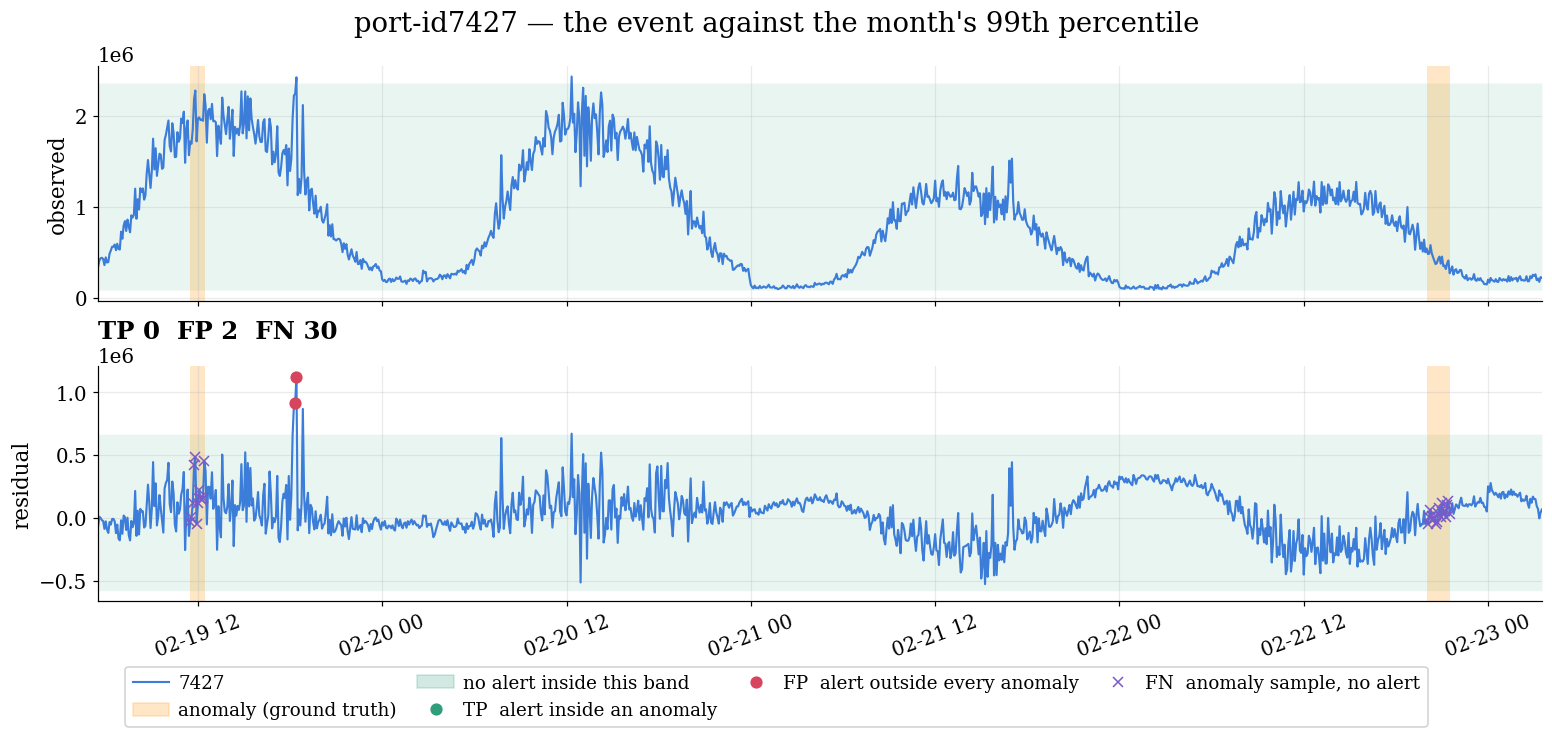

observed  event peak sits at the 100.0% percentile, 0 samples are higher, 32/62 above the 99th
residual  event peak sits at the 100.0% percentile, 0 samples are higher, 32/62 above the 99th


In [37]:
mask = g["target"].to_numpy()

# The 99th percentile is a fixed cutoff in the units of the signal, which is what `bands=` draws:
# everything under the shaded ceiling is where nothing fires. Same two columns as the cell above,
# the same frame, narrowed on x to the anomaly windows plus six hours.
band = {name: (float(np.nanmin(parts.loc[rows, name])),
               float(np.nanquantile(parts.loc[rows, name], 0.99)))
        for name in ("observed", "residual")}
# The band's own upper edge is the cutoff, so this is the same detector the numbers below
# describe rather than a separate one — the residual becomes an alert the moment it clears the
# ceiling this cell already drew.
resid_alerts = confirm(breach=parts["residual"] > band["residual"][1], data=parts, n=N_CONSEC)
plot_signals(half=HALF, data=parts, columns=["observed", "residual"], ports=[port], events=ZOOM_EVENTS,
             alerts={"residual": resid_alerts}, baselines=None, bands=band, outcomes=True,
             by_port=False, zoom_anomaly=True, zoom_signal=False, pad="6h",
             title=f"{port} — the event against the month's 99th percentile")

for name, v in [("observed", g["value"].to_numpy()), ("residual", resid)]:
    v = pd.Series(v)
    print(f"{name:9} event peak sits at the {v.rank(pct=True)[mask].max():.1%} percentile, "
          f"{int((v > v[mask].max()).sum()):,} samples are higher, "
          f"{int((v[mask] > v.quantile(0.99)).sum())}/{int(mask.sum())} above the 99th")

- **The two lines say it exactly.** In the observed series the event's peak sits near the
  month's median — thousands of ordinary samples above it, none of its samples clearing the 99th
  percentile. In the residual, all of them do.
- **The data didn't change.** Subtracting the day's expected shape converted a contextual anomaly
  into an absolute one — the whole reason this transform exists.
- **Cost:** a parameter to keep correct. Lab 02 measures what it buys on a port that never needed
  it.

## Step 16 — Sliding windows

- **The other way to give a model context:** feed it the last `N_INPUT` numbers as a vector
  instead of one number — a sample judged by the shape it sits in, not its own height.

```
value:  [10, 20, 30, 40, 50, 60, ...]
rows:   [10, 20, 30]
            [20, 30, 40]
                [30, 40, 50]
```

- **A view, not data.** One call on a column Lab 02 already has — the spec carries `N_INPUT`, not
  the matrix. Persisting 43,200 rows of 36 overlapping copies would ship the same numbers 36
  times.

In [38]:
g = series_of(PORTS[0], col=COLUMNS[0], data=df, events=ANOMALY_TYPES)
W = sliding_windows(g["value"], n_input=N_INPUT)
print(f"{len(g):,} samples -> {W.shape[0]:,} rows of {W.shape[1]} columns, "
      f"each covering {N_INPUT * CADENCE / 3600:.1f} h")
print(f"the matrix repeats every value {N_INPUT} times: "
      f"{W.nbytes / 1e6:.1f} MB against {g['value'].to_numpy().nbytes / 1e6:.2f} MB for the column")
pd.DataFrame(W[:3], index=[f"row {i}" for i in range(3)]).iloc[:, :6].round(0)

8,640 samples -> 8,605 rows of 36 columns, each covering 3.0 h
the matrix repeats every value 36 times: 2.5 MB against 0.07 MB for the column


,0,1,2,3,4,5
row 0,116229.0,101633.0,121597.0,123971.0,92874.0,99138.0
row 1,101633.0,121597.0,123971.0,92874.0,99138.0,114428.0
row 2,121597.0,123971.0,92874.0,99138.0,114428.0,109508.0


### 16a — Sweep `N_INPUT`, the same hyperparameter a second time

- **Step 9** swept a baseline window: failure at both ends.
- **This one has the first shape,** for reasons belonging to the representation rather than any
  model — too short carries no context, and as it approaches `PERIOD` every window is a whole day
  and they all look alike.
- **One detector reads the sweep** — the question is what the *framing* is worth, not which model
  is best. `LocalOutlierFactor` scores a point by how sparse its neighbourhood is relative to its
  neighbours', exactly what a window length changes. Lab 02 runs all three.

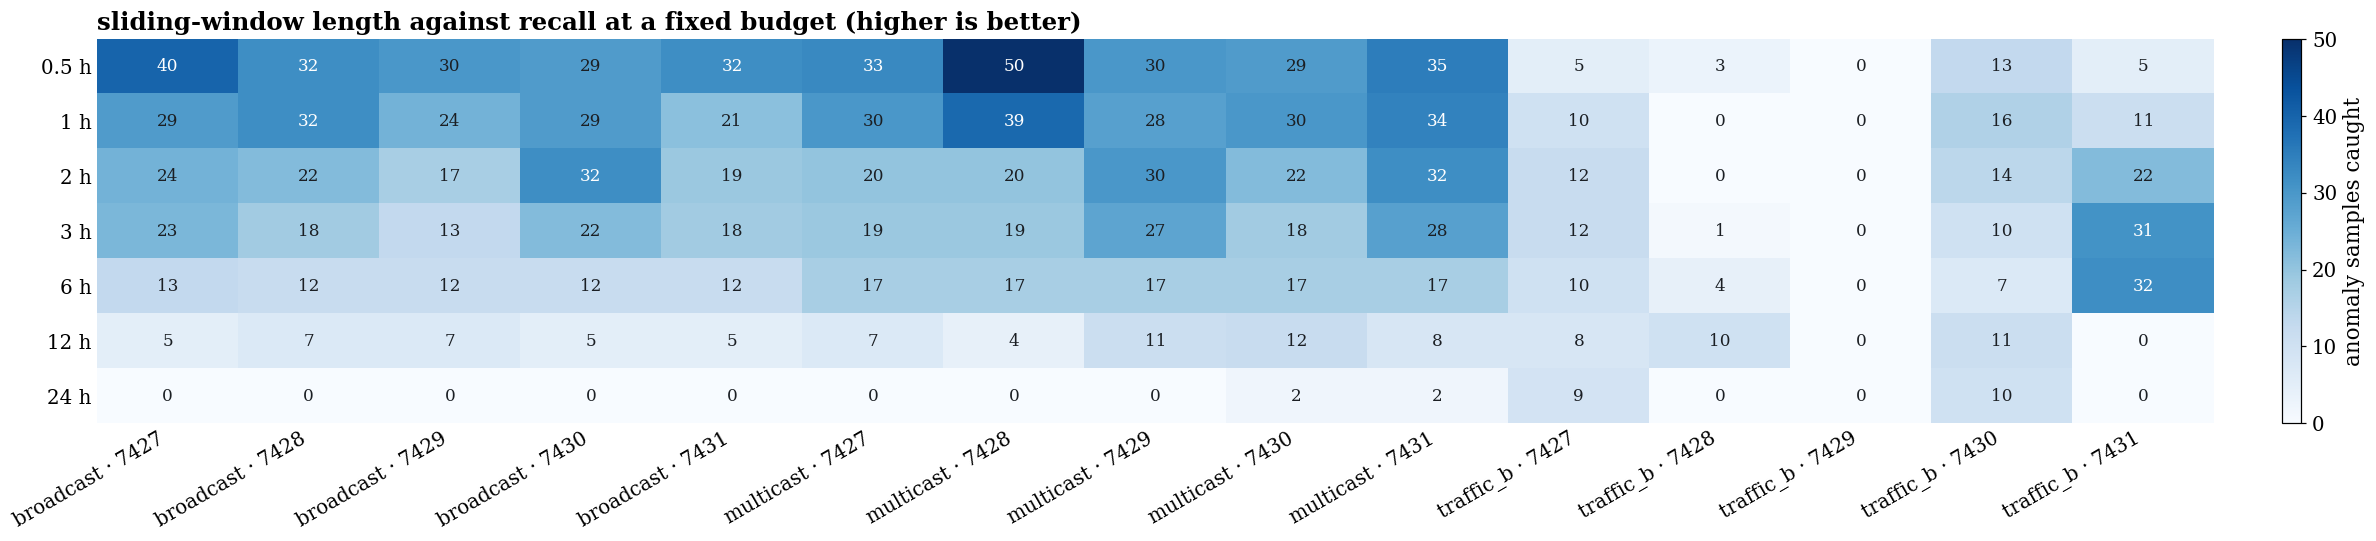

<Axes: title={'left': 'sliding-window length against recall at a fixed budget (higher is better)'}>

In [39]:
def window_recall(g, n_input, train_frac=None):
    """Anomaly samples caught by LOF at the shared budget, on n_input-sample windows."""
    train_frac = TRAIN_FRAC if train_frac is None else train_frac
    W = sliding_windows(g["value"], n_input=n_input)
    k = int(train_frac * len(W))
    mean, scale = W[:k].mean(axis=0), W[:k].std(axis=0)
    Xw = (W - mean) / np.where(scale == 0, 1.0, scale)
    s = -LocalOutlierFactor(n_neighbors=20, novelty=True).fit(Xw[:k]).score_samples(Xw)
    padded = np.concatenate([np.full(n_input - 1, np.nan), s])
    fired = padded > np.nanquantile(padded, 0.99)
    t = g["target"].to_numpy()
    return int((fired & t).sum()), int(t.sum())


rows = []
for pid, col in [(p, c) for c in COLUMNS for p in PORTS]:
    g = series_of(pid, col=col, data=df, events=ANOMALY_TYPES)
    for n in N_INPUT_SWEEP:
        caught, of = window_recall(g, n_input=n, train_frac=TRAIN_FRAC)
        rows.append({"port": pid[-4:], "column": col, "hours": round(n * CADENCE / 3600, 1),
                     "caught": caught, "of": of})
window_sweep = pd.DataFrame(rows)
grid = window_sweep.pivot_table(index="hours", columns=["column", "port"], values="caught")
grid.columns = [f"{c[:9]} · {p}" for c, p in grid.columns]
grid.index = [f"{h:g} h" for h in grid.index]
heatmap(grid, fmt="{:.0f}", annotate=True, cbar_label="anomaly samples caught",
        title="sliding-window length against recall at a fixed budget (higher is better)")

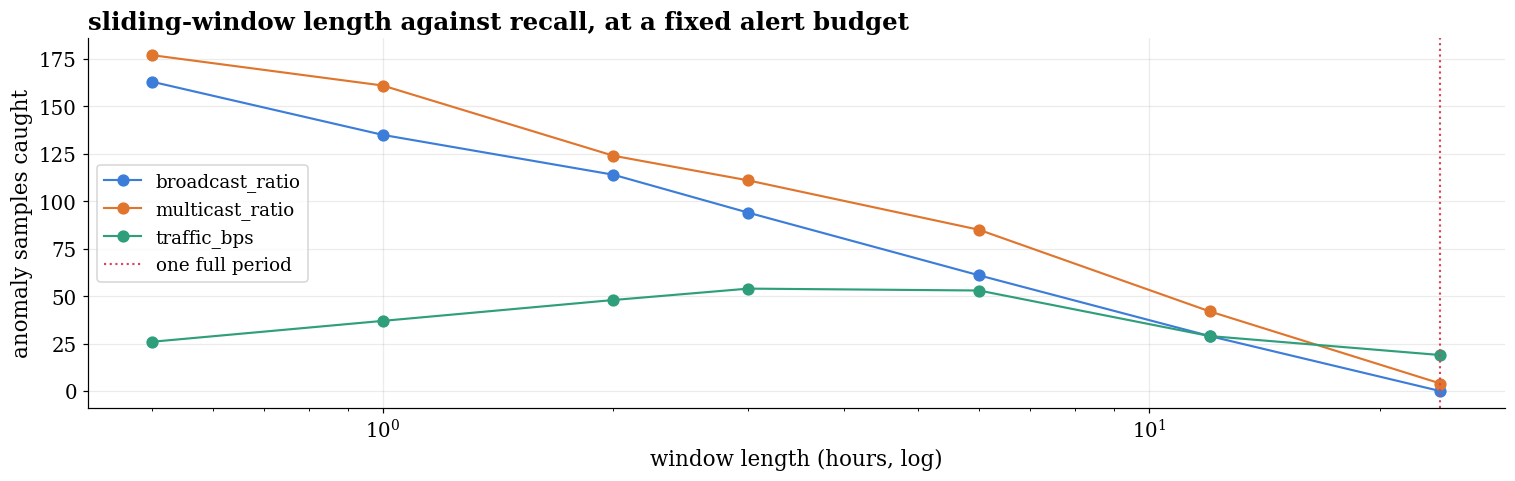

In [40]:
fig, ax = plt.subplots()
for k, (col, d) in enumerate(window_sweep.groupby("column")):
    m = d.groupby("hours")["caught"].sum()
    ax.plot(m.index, m.values, "-o", color=PORT_C[k % len(PORT_C)], label=col)
ax.axvline(PERIOD * CADENCE / 3600, color=C["alert"], ls=":", label="one full period")
ax.set(xscale="log", xlabel="window length (hours, log)", ylabel="anomaly samples caught",
       title="sliding-window length against recall, at a fixed alert budget")
ax.legend()
plt.show()

### 16b — `window_recall` counted the alerts; here they are on the signal

Same LOF-on-windows detector, same 99th-percentile cutoff, one column at `N_INPUT`, all 5 ports.

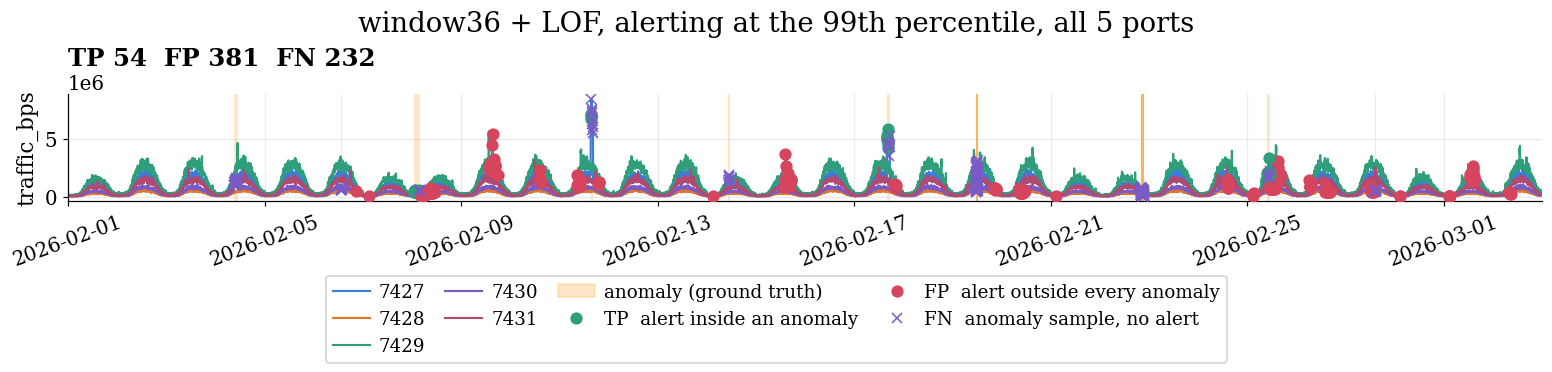

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,window36 LOF,435,0.124,5/18,0.0,12.7


In [41]:
demo_col = COLUMNS[0]
fired17 = pd.Series(False, index=df.index)
for pid in PORTS:
    g17 = series_of(pid, col=demo_col, data=df, events=ANOMALY_TYPES)
    W17 = sliding_windows(g17["value"], n_input=N_INPUT)
    k17 = int(TRAIN_FRAC * len(W17))
    mean17, scale17 = W17[:k17].mean(axis=0), W17[:k17].std(axis=0)
    Xw17 = (W17 - mean17) / np.where(scale17 == 0, 1.0, scale17)
    s17 = -LocalOutlierFactor(n_neighbors=20, novelty=True).fit(Xw17[:k17]).score_samples(Xw17)
    padded17 = np.concatenate([np.full(N_INPUT - 1, np.nan), s17])
    fired17.loc[df.index[df["port_id"] == pid]] = padded17 > np.nanquantile(padded17, 0.99)

plot_signals(half=HALF, data=df, columns=[demo_col], ports=PORTS, events=ANOMALY_TYPES,
             alerts={demo_col: fired17}, baselines=None, bands=None, outcomes=True, by_port=False,
             zoom_anomaly=False, zoom_signal=False,
             title=f"window{N_INPUT} + LOF, alerting at the 99th percentile, all 5 ports")
report(alerts={f"window{N_INPUT} LOF": fired17}, data=df, ports=PORTS, events="all")

#### Your call — `N_INPUT`

**The decision:** how much recent shape a model gets to see. Third appearance, and the sweep above
already delivered the uncomfortable part.

- **The columns want different settings and no value serves all of them.**
  - A contextual anomaly needs a window long enough to carry shape.
  - An absolute one is diluted by every dimension added.
- **That is the shape of the problem, not a defect in the sweep.** The one honest resolution is to
  stop looking for a fleet-wide default and set the window per class.
- **Which means you need a classification** — the same missing domain knowledge 10c needed.

**Do it now.** Sort the ports and metrics you monitor into two piles: incidents obvious from the
number alone, and incidents only unusual for the time of day. Count both. If the second pile is
empty you do not need windowing at all, and that is a useful finding rather than a disappointment.


Read the heatmap by column, because the three disagree.

- **No single `N_INPUT` is best across the columns,** and the spread between the best and worst
  choice on one column is larger than the spread between columns at a fixed choice.
- **Long windows collapse.** As the length approaches `PERIOD`, every row contains most of a day, so
  no row is unusual and recall falls away.
- **Short windows carry no context,** which is what the contextual anomalies need.

**So there is no fleet-wide default, and that is the finding rather than a gap in the sweep.** The
honest resolution is a window per class of port and column — which means you need a classification,
which is the same missing domain knowledge 10c's peer groups needed. **Two gaps, one cause.**

**The two remedies are not interchangeable either.** Decomposition subtracts the expected shape;
windowing lets a model compare shapes. Which wins depends on whether the column has a shape at all,
and Step 10b already answered that for these three.

## Step 17 — What Lab 02 loads

Two files, and the division between them is the contract.

- **`features.csv`** — one row per sample, every column a detector might score.
- **`feature_spec.json`** — every number a detector needs and no data: cadence and period, the
  window lengths this lab measured rather than guessed, the scorable/sparse split, the scale
  floor and score cap, and the fitted scaler for every (port, column) so Lab 02 cannot refit on data
  it should not have seen.
- **Deliberately absent: any score, label or alert.** Those are Lab 02's output. Shipping this lab's
  version would let a detector inherit a threshold nobody re-derived.

In [42]:
OUT = ROOT / "outputs" / "workshop"
OUT.mkdir(parents=True, exist_ok=True)

KEYS = ["timestamp", "device_id", "port_id", "port_role", "event_label", "event_id", "is_train"]
SHIP = KEYS + FEATURES + [f"resid_{c}" for c in SCORABLE]
df[SHIP].to_csv(OUT / "features.csv", index=False)

spec = {
    "produced_by": "labs/workshop/01_baselines_windows_alerts.ipynb",
    "consumed_by": "labs/workshop/02_detectors.ipynb",
    "frame": {"path": "outputs/workshop/features.csv", "rows": int(len(df)),
              "columns": SHIP, "keys": ["timestamp", "port_id"]},
    "data_contract": {
        "rows": int(len(df)), "ports": PORTS, "cadence_seconds": float(CADENCE),
        "period_samples": int(PERIOD), "span_days": round(float(DAYS), 1),
        "base_rate": round(float((df["event_label"] != "normal").mean()), 5),
        "anomaly_windows": int(n_win),
        "shortest_event_samples": int(df[df["event_label"] != "normal"]
                                      .groupby(["event_id", "port_id"]).size().min()),
    },
    "features": {"all": FEATURES, "scorable": SCORABLE, "sparse": SPARSE,
                 "zero_fraction": {c: round(float(zero_fraction[c]), 4) for c in FEATURES},
                 "residual_of": SCORABLE},
    "baseline": {"rolling_window_samples": int(WINDOW), "threshold": float(THRESHOLD),
                 "n_consecutive": int(N_CONSEC), "mad_to_sigma": 1.4826,
                 "score_cap": 50.0, "scale_floor_fraction": 0.05,
                 "sparse_zero_fraction_cutoff": 0.5},
    "representations": {"train_frac": TRAIN_FRAC,
                        "sliding_window_samples": int(N_INPUT),
                        "columns": COLUMNS, 
                        "anomaly_types": ANOMALY_TYPES,
                        "zoom_events": ZOOM_EVENTS, 
                        "regime_by": list(REGIME_BY),
                        "note": "the sliding-window matrix is a view; rebuild it from the column"},
    "scalers": {k: {"mean": m, "scale": sc} for k, (m, sc) in SCALERS.items()},
}
(OUT / "feature_spec.json").write_text(json.dumps(spec, indent=2, default=str))

print(f"features.csv     {len(df):,} rows x {len(SHIP)} columns  "
      f"{(OUT / 'features.csv').stat().st_size / 1e6:.1f} MB")
print(f"feature_spec.json {len(spec['scalers'])} scalers, "
      f"{(OUT / 'feature_spec.json').stat().st_size / 1e3:.1f} kB")
print("columns shipped:", ", ".join(SHIP))

features.csv     43,200 rows x 27 columns  16.4 MB
feature_spec.json 70 scalers, 11.5 kB
columns shipped: timestamp, device_id, port_id, port_role, event_label, event_id, is_train, traffic_bps, packets_pps, errors_pps, discards_pps, unknown_proto_pps, avg_pkt_bytes, broadcast_ratio, multicast_ratio, nonucast_ratio, tx_ratio, error_rate, discard_rate, err_disc_rate, resid_traffic_bps, resid_packets_pps, resid_avg_pkt_bytes, resid_broadcast_ratio, resid_multicast_ratio, resid_nonucast_ratio, resid_tx_ratio


## Exercises

Two tiers. The first six are measurements: change one thing, re-run, read the figure. The last four
have no answer in this notebook — they need what you know about your own network.

### Measure it

1. **Window.** `WINDOW = 12` (1 h), re-run Step 10.
   - Which baselines lose recall, and does 9a explain which survive?
   - Then `WINDOW = 2016` (7 days): explain the alert rate from the 9c sweep, not the new table.
2. **Cutoff.** `THRESHOLD` to `2.0`, then `8.0`. Whose alerts per day grows fastest, and did the
   ranked plot in Step 7 predict it?
3. **Persistence.** `N_CONSEC` to `1`, then `4`.
   - How many minutes of delay did each sample cost?
   - At what N does the 8-sample event become structurally impossible to catch?
4. **Sparsity.** Put `"errors_pps"` into `COLUMNS` and re-run Step 10. Predict which of the
   six baselines still returns a usable number *before* you run it.
5. **Peer group.** Raise `min_peers` to `4` — with five ports that leaves no margin. Then restrict
   `PORTS` to the two `edge-fw-01` ports: is a peer group of two worth anything?
6. **Seasonal depth.** `seasonal_baseline(by=("hour", "dayofweek"))` — four samples per cell on 30
   days. Did the extra resolution pay for the thinner cells?

### Design it

Write the answer before you code it, and be specific about the network you operate.

7. **Name your own baseline source.**
   - For one metric you watch: which source do you use today, and which would you defend in a review?
   - If they differ, what stops you switching? Usually history depth or a missing topology map.
8. **Price a miss against a page.**
   - What does a missed incident cost, and what does an unnecessary 03:00 page cost?
   - Find the point on the Step 12 plane those two imply.
   - Most teams find the ratio they have been assuming is off by an order of magnitude.
9. **Design the suppression list you need.**
   - Step 11 suppresses declared change windows. Real suppression has two more kinds: a
     known-broken exporter, and a permanently noisy interface nobody will fix.
   - Write the schema covering all three, and name who keeps each field current.
   - **What makes an entry expire?** That question decides whether it survives.
10. **Choose the metric that would have caught your last incident.**
    - Which of the thirteen features — or which one you would have to add — moves first during it?
    - Add it to Step 2, put it in `COLUMNS`, use the baseline from exercise 7, read what it buys.
    - The number will not transfer; the shape of the argument does.

In [43]:
# YOUR CODE HERE

## Summary

- **No baseline, no anomaly.** Six here, each answering "compared to what" differently. None
  dominates, and a fixed threshold still beats every adaptive method on a signal with a hard limit.
- **The window is a hyperparameter, not a default.**
  - Too short and a sustained event walks into its own baseline.
  - Too long and it spans the cycle it was meant to avoid.
  - Sweep it, and expect a different answer per signal.
- **One hyperparameter, met three times.** Rolling window, sliding-window length.
  - Each has an interior optimum that differs per column and per port.
- **Seasonality is a property of the column, not the fleet.** `traffic_bps` autocorrelates at 0.73 to
  0.83 a day out; the two ratio columns sit at −0.001. Everything built on a season — the seasonal
  baseline, the decomposition — works on the first and fails on the other two.
- **Check the representation before sweeping its parameter.** A sweep on the wrong column draws a
  clean curve and answers nothing.
- **Smoothing is not detection.** An average keeps the event's full height only while it fits inside
  the event's flat part, then collapses fast.
- **Score, label and alert are three layers.** Persistence and a maintenance calendar sit between the
  last two.
- **The threshold is priced in on-call hours,** not in sigma.
- **Split by index, fit the scaler on the training part.** The leak here is a few percent, in both
  directions — which is what makes it dangerous rather than harmless.
- **Two gaps this lab cannot close:** peer groups (10c) and the per-class window (16a). Both need
  someone who knows the network.

Lab 02 loads what Step 17 published and asks which detector to run on it.